# PS2 — Right-Party Contact & Skip-Trace: Exploratory Data Analysis

**What this notebook does.** It walks through every PS2 dataset, checks data quality, checks that the train / validation / test split is clean, and explores the patterns that matter for predicting whether a phone number still reaches the borrower and when a skip-trace is worth paying for.

**How to use it in Google Colab**
1. Upload the **original, unsplit** CSV files plus `splits.csv` using the folder icon in the left sidebar (they land in `/content`, which is where this notebook looks).
2. Click **Runtime → Run all**. Every section has a short note above it saying what it shows and what to look for.
3. If a file is missing, the setup cell stops and tells you which one. The run takes about a minute.

**Files used**

| File | One row is… | Role in PS2 |
|---|---|---|
| `accounts.csv` | one loan account | borrower profile, amount at stake |
| `splits.csv` | one account → train / validation / test | evaluation design |
| `phones.csv` | one phone number on one account | **the unit we score** |
| `verified_contact_points.csv` | one phone checked manually | **closest thing to ground truth** |
| `skip_traces.csv` | one skip-trace performed | cost and success of tracing today |
| `dial_attempts.csv` | one call to one phone | **the main evidence: network response, disposition, remark** |
| `payments.csv` | one payment received | what a contact is worth; paying without contact = avoiding |
| `agents.csv` | one tele, field or bot agent | integrity and disposition reliability |
| `addresses.csv` | one address on one account | phase-2 contact points |
| `field_visits.csv` | one field visit | address health evidence |
| `lenders.csv` | one lender | lender type and address format |

**Sections:** 0 Setup · 1 Load · 2 Data quality · 3 Split checks · 4 Accounts & lenders · 5 Phones · 6 Verified truth · 7 Skip traces · 8 Dial attempts · 9 Agents · 10 Payments · 11 Addresses & field visits · 12 Account-level correlations · 13 Random arm · 14 Key findings

**A rule followed throughout.** Anything describing *outcomes* (verified status, skip-trace success, contact and payment rates) is analysed on the **training split only** by default, so the validation and test sets stay unseen. Switch `OUTCOMES_ON_TRAIN_ONLY` in the setup cell if you want to look at everything.

## 0. Setup
Imports, chart style, file locations and small helper functions used everywhere below. Nothing here needs editing unless your files live in a different folder.

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ---------------- settings you might change ----------------
DATA_DIR = "."                  # Colab: uploaded files sit in /content, the default folder
OUTCOMES_ON_TRAIN_ONLY = True   # analyse verified / skip-trace outcomes on train only
# -----------------------------------------------------------

# Chart style: one fixed colour order so the same thing is always the same colour
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#898781", "#fcfcfb", "#e6e5e1"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f3f7fd", "#86b6ef", "#2a78d6", "#104281"])
DIV = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#eb6834"])
SPLIT_COLORS = {"train": CAT[0], "validation": CAT[1], "test": CAT[2]}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.titlecolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.labelsize": 9, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 8.5,
    "axes.prop_cycle": plt.cycler(color=CAT), "figure.dpi": 110,
})

BUCKET_ORDER = ["X", "1-30", "31-60", "61-90", "90+"]
BUREAU_ORDER = ["300-549", "550-649", "650-699", "700-749", "750-900"]
SPLIT_ORDER  = ["train", "validation", "test"]

In [ ]:
# ---- Which files are present? ----
FILES = ["accounts", "splits", "lenders", "phones", "verified_contact_points", "skip_traces",
         "dial_attempts", "payments", "agents", "addresses", "field_visits"]

def path(name):
    return os.path.join(DATA_DIR, f"{name}.csv")

status = pd.DataFrame({"file": [f"{n}.csv" for n in FILES], "found": [os.path.exists(path(n)) for n in FILES]})
display(status)

missing = [n for n in FILES if not os.path.exists(path(n))]
if missing:
    raise FileNotFoundError(f"Upload these before continuing: {missing}  (looking in {os.path.abspath(DATA_DIR)}). "
                            "If Colab renamed a file (e.g. accounts (1).csv), rename it back.")
print("All 11 files found.")

,file,found
0,accounts.csv,True
1,splits.csv,True
2,lenders.csv,True
3,phones.csv,True
4,verified_contact_points.csv,True
5,skip_traces.csv,True
6,dial_attempts.csv,True
7,payments.csv,True
8,agents.csv,True
9,addresses.csv,True


All 11 files found.


In [ ]:
# ---- Helper functions used throughout ----

def profile(df, name):
    """One-table summary of a DataFrame: type, missing values, distinct values, an example."""
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(),
        "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    display(Markdown(f"**{name}** — {df.shape[0]:,} rows × {df.shape[1]} columns, "
                     f"{df.duplicated().sum()} fully duplicated rows"))
    display(out)

def wilson(k, n, z=1.96):
    """Proportion with a 95% Wilson confidence interval (honest even for small groups)."""
    if n == 0:
        return np.nan, np.nan, np.nan
    p = k / n
    d = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / d
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return p, centre - half, centre + half

def rate_table(df, by, flag, order=None):
    """Rate of a 0/1 column per group, with counts and 95% CI."""
    g = df.groupby(by, observed=True)[flag].agg(["sum", "count"])
    rows = []
    for key, r in g.iterrows():
        p, lo, hi = wilson(r["sum"], r["count"])
        rows.append({by: key, "n": int(r["count"]), "positives": int(r["sum"]), "rate": p, "ci_low": lo, "ci_high": hi})
    t = pd.DataFrame(rows).set_index(by)
    if order is not None:
        t = t.reindex([o for o in order if o in t.index])
    return t

def plot_rate(t, ax, title, xlabel="rate", overall=None, color=CAT[0], xmax=1.0):
    """Horizontal bars of a rate per group with CI whiskers and n labels."""
    y = np.arange(len(t))
    ax.barh(y, t["rate"], color=color, height=0.6)
    err_lo = (t["rate"] - t["ci_low"]).clip(lower=0)   # clip tiny float rounding at 0% / 100%
    err_hi = (t["ci_high"] - t["rate"]).clip(lower=0)
    ax.errorbar(t["rate"], y, xerr=[err_lo, err_hi],
                fmt="none", ecolor=INK2, elinewidth=1, capsize=3)
    ax.set_yticks(y, [str(i) for i in t.index])
    ax.invert_yaxis()
    for yi, (r, n) in enumerate(zip(t["ci_high"], t["n"])):
        ax.text(min(r, xmax) + 0.02 * xmax, yi, f"{t['rate'].iloc[yi]:.0%}  (n={n})", va="center", fontsize=8, color=INK2)
    if overall is not None:
        ax.axvline(overall, color=MUTED, ls="--", lw=1)
    ax.set_xlim(0, xmax * 1.3)
    ax.set_xticks(np.linspace(0, xmax, 6))   # axis stops at xmax; extra room is only for labels
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0 if xmax >= 0.1 else 1))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)

def count_bar(series, ax, title, order=None, color=CAT[0]):
    """Horizontal count bars with % labels."""
    vc = series.value_counts(dropna=False)
    if order is not None:
        vc = vc.reindex([o for o in order if o in vc.index])
    y = np.arange(len(vc))
    ax.barh(y, vc.values, color=color, height=0.6)
    ax.set_yticks(y, [str(i) for i in vc.index])
    ax.invert_yaxis()
    total = series.shape[0]
    for yi, v in enumerate(vc.values):
        ax.text(v, yi, f"  {v:,} ({v/total:.0%})", va="center", fontsize=8, color=INK2)
    ax.set_xlim(0, vc.max() * 1.35)
    ax.set_title(title)
    ax.grid(axis="y", visible=False)

def cramers_v(x, y):
    """Association between two categorical columns: 0 = none, 1 = perfect (bias-corrected)."""
    ct = pd.crosstab(x, y)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2c = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc - 1)))

def heat(ct, ax, title, fmt=".0%", cmap=SEQ, center=None, vmin=None, vmax=None):
    sns.heatmap(ct, annot=True, fmt=fmt, cmap=cmap, center=center, vmin=vmin, vmax=vmax,
                linewidths=2, linecolor=SURFACE, cbar=False, ax=ax, annot_kws={"fontsize": 8})
    ax.set_title(title)
    ax.tick_params(axis="both", length=0)
    ax.grid(False)

## 1. Load the data and attach the split
Dates are parsed as real dates. Every table that has an `account_id` gets a `split` column copied from `splits.csv`, so later sections can compare train / validation / test or restrict to train.

In [ ]:
accounts = pd.read_csv(path("accounts"))
splits   = pd.read_csv(path("splits"))
phones   = pd.read_csv(path("phones"), parse_dates=["added_date"])
skip     = pd.read_csv(path("skip_traces"), parse_dates=["trace_date"])
verified = pd.read_csv(path("verified_contact_points"), parse_dates=["verified_date"])
dials    = pd.read_csv(path("dial_attempts"), parse_dates=["attempt_ts"])
payments = pd.read_csv(path("payments"), parse_dates=["payment_ts"])
addresses = pd.read_csv(path("addresses"), parse_dates=["added_date"])
visits   = pd.read_csv(path("field_visits"), parse_dates=["visit_date", "start_ts", "checkin_ts"])
agents   = pd.read_csv(path("agents"))     # reference table: no account_id, never split
lenders  = pd.read_csv(path("lenders"))    # reference table: no account_id, never split

split_map = splits.set_index("account_id")["split"]
for df in (accounts, phones, skip, verified, dials, payments, addresses, visits):
    df["split"] = df["account_id"].map(split_map)
    assert df["split"].notna().all(), "Some rows have an account_id that is not in splits.csv"

def outcome_view(df):
    """Rows used for outcome analysis (train only by default)."""
    return df[df["split"] == "train"].copy() if OUTCOMES_ON_TRAIN_ONLY else df.copy()

print("Outcome analyses use:", "TRAIN split only" if OUTCOMES_ON_TRAIN_ONLY else "ALL splits")
for name, df in [("accounts", accounts), ("phones", phones), ("skip_traces", skip), ("verified", verified),
                 ("dial_attempts", dials), ("payments", payments), ("addresses", addresses), ("field_visits", visits)]:
    print(f"{name:<14} {df.shape[0]:>7,} rows   " + "   ".join(f"{s}: {(df.split == s).sum():,}" for s in SPLIT_ORDER))

Outcome analyses use: TRAIN split only
accounts         2,400 rows   train: 1,680   validation: 360   test: 360
phones           5,719 rows   train: 4,001   validation: 881   test: 837
skip_traces        766 rows   train: 523   validation: 134   test: 109
verified           250 rows   train: 173   validation: 41   test: 36
dial_attempts   51,105 rows   train: 35,834   validation: 7,864   test: 7,407
payments         2,162 rows   train: 1,512   validation: 301   test: 349
addresses        3,117 rows   train: 2,175   validation: 483   test: 459
field_visits     5,578 rows   train: 3,896   validation: 894   test: 788


## 2. Data quality
### 2.1 Column-by-column profile
For each column: its type, how many values are missing, how many distinct values it has, and one example. Look for columns that are mostly missing, IDs that aren't unique, and text columns that should be numbers.

In [ ]:
for name, df in [("accounts.csv", accounts), ("splits.csv", splits), ("lenders.csv", lenders), ("agents.csv", agents),
                 ("phones.csv", phones), ("verified_contact_points.csv", verified), ("skip_traces.csv", skip),
                 ("dial_attempts.csv", dials), ("payments.csv", payments), ("addresses.csv", addresses),
                 ("field_visits.csv", visits)]:
    profile(df.drop(columns="split", errors="ignore"), name)

**accounts.csv** — 2,400 rows × 20 columns, 0 fully duplicated rows

,dtype,missing,missing_%,n_unique,example
account_id,object,0,0.000,2400,AC000001
lender_id,object,0,0.000,6,L03
portfolio,object,0,0.000,6,pl_salaried
income_type,object,0,0.000,3,salaried
town_id,object,0,0.000,3,T1
preferred_language,object,0,0.000,3,kanglish
bucket_start,object,0,0.000,5,61-90
dpd_start,int64,0,0.000,323,81
emi_amount,float64,0,0.000,473,"16,750.000"
overdue_start,float64,0,0.000,790,"50,250.000"


**splits.csv** — 2,400 rows × 1 columns, 0 fully duplicated rows

,dtype,missing,missing_%,n_unique,example
account_id,object,0,0.000,2400,AC000001


**lenders.csv** — 6 rows × 4 columns, 0 fully duplicated rows

...

,dtype,missing,missing_%,n_unique,example
payment_id,object,0,0.000,2162,PY0000001
account_id,object,0,0.000,1667,AC000457
payment_ts,datetime64[ns],0,0.000,2161,2026-04-01 19:57:52
amount,float64,0,0.000,586,"3,800.000"
channel,object,0,0.000,7,branch_cash


**addresses.csv** — 3,117 rows × 7 columns, 0 fully duplicated rows

,dtype,missing,missing_%,n_unique,example
address_id,object,0,0.000,3117,AD000001
account_id,object,0,0.000,2400,AC000001
address_type,object,0,0.000,3,residence
source,object,0,0.000,2,kyc_origination
added_date,datetime64[ns],0,0.000,24,2026-04-01 00:00:00
town_id,object,0,0.000,4,T1
address_text,object,0,0.000,3114,"6th Cross, 5th Main, ಚರ್ಚ್ ಹತ್ತಿರ, Kuvempu Lay..."


**field_visits.csv** — 5,578 rows × 15 columns, 0 fully duplicated rows

,dtype,missing,missing_%,n_unique,example
visit_id,object,0,0.000,5578,VS000001
account_id,object,0,0.000,1339,AC000652
address_id,object,0,0.000,1477,AD000840
agent_id,object,0,0.000,9,FA003
visit_date,datetime64[ns],0,0.000,77,2026-04-01 00:00:00
start_ts,datetime64[ns],0,0.000,5564,2026-04-01 10:21:26
checkin_ts,datetime64[ns],0,0.000,5569,2026-04-01 11:00:13
checkin_x,float64,0,0.000,5263,"1,409.800"
checkin_y,float64,0,0.000,5253,"-1,495.100"
gps_accuracy_m,float64,0,0.000,324,11.700


### 2.2 Keys and links between files
These checks confirm the files fit together. Each row reports how many records **fail** the check. Anything non-zero is explained in the notes below the table.

In [ ]:
acct_ids = set(accounts.account_id)
phone_pairs = set(zip(phones.phone_id, phones.account_id))
sk_new = skip.dropna(subset=["new_contact_point_id"])
sk_new_phone = sk_new[sk_new.new_contact_point_id.str.startswith("PH")]
sk_new_addr  = sk_new[sk_new.new_contact_point_id.str.startswith("AD")]
merged_new = sk_new_phone.merge(phones[["phone_id", "account_id", "source", "added_date"]],
                                left_on="new_contact_point_id", right_on="phone_id", how="left", suffixes=("", "_ph"))

checks = pd.DataFrame([
    ("account_id unique in accounts",                    accounts.account_id.duplicated().sum()),
    ("accounts with no phone at all",                    (~accounts.account_id.isin(phones.account_id)).sum()),
    ("phones whose account is not in accounts",          (~phones.account_id.isin(acct_ids)).sum()),
    ("phone_id appearing on more than one account (rows)", phones.phone_id.duplicated(keep=False).sum()),
    ("(phone_id, account_id) pair duplicated",           phones.duplicated(["phone_id", "account_id"]).sum()),
    ("verified rows not matching a phone on that account", sum((p, a) not in phone_pairs for p, a in zip(verified.phone_id, verified.account_id))),
    ("verified phone_id duplicated",                     verified.phone_id.duplicated().sum()),
    ("skip traces whose account is not in accounts",     (~skip.account_id.isin(acct_ids)).sum()),
    ("trace says 'new_phone_found' but no new id",       ((skip.result == "new_phone_found") & skip.new_contact_point_id.isna()).sum()),
    ("trace new phone id missing from phones.csv",       merged_new.phone_id.isna().sum()),
    ("trace new phone attached to a different account",  (merged_new.account_id != merged_new.account_id_ph).sum()),
    ("trace new phone added on a date ≠ trace date",     (merged_new.added_date != merged_new.trace_date).sum()),
    ("prev_ptp_broken > prev_ptp_count",                 (accounts.prev_ptp_broken > accounts.prev_ptp_count).sum()),
    ("overdue_start > outstanding",                      (accounts.overdue_start > accounts.outstanding).sum()),
    ("accounts whose lender is not in lenders",          (~accounts.lender_id.isin(lenders.lender_id)).sum()),
    ("dials to a (phone, account) pair not in phones",   sum((p, a) not in phone_pairs for p, a in zip(dials.phone_id, dials.account_id))),
    ("dials by an agent not in agents",                  (~dials.agent_id.isin(agents.agent_id)).sum()),
    ("dials whose dialling_arm ≠ the account's arm",     (dials.dialling_arm != dials.account_id.map(accounts.set_index("account_id").dialling_arm)).sum()),
    ("attempt_id duplicated",                            dials.attempt_id.duplicated().sum()),
    ("payments whose account is not in accounts",        (~payments.account_id.isin(acct_ids)).sum()),
    ("payments with amount ≤ 0",                         (payments.amount <= 0).sum()),
    ("visits to an (address, account) pair not in addresses", (~visits.set_index(["address_id", "account_id"]).index.isin(addresses.set_index(["address_id", "account_id"]).index)).sum()),
    ("visits by an agent not in agents",                 (~visits.agent_id.isin(agents.agent_id)).sum()),
    ("visits with check-in before start",                (visits.checkin_ts < visits.start_ts).sum()),
    ("trace new address id missing from addresses",      (~sk_new_addr.new_contact_point_id.isin(addresses.address_id)).sum()),
], columns=["check", "failing_records"])
display(checks)
print(f"New ids returned by traces: {len(sk_new_phone)} phones (PH...) and {len(sk_new_addr)} addresses (AD..., these live in addresses.csv)")

,check,failing_records
0,account_id unique in accounts,0
1,accounts with no phone at all,0
2,phones whose account is not in accounts,0
3,phone_id appearing on more than one account (r...,175
4,"(phone_id, account_id) pair duplicated",0
5,verified rows not matching a phone on that acc...,0
6,verified phone_id duplicated,0
7,skip traces whose account is not in accounts,0
8,trace says 'new_phone_found' but no new id,0
9,trace new phone id missing from phones.csv,0


New ids returned by traces: 148 phones (PH...) and 27 addresses (AD..., these live in addresses.csv)


### 2.3 Time coverage
When each table's events happen. This defines the observation window and tells you which data can be used as features at a given point in time.

,table,first,last,distinct_days
0,phones,2026-04-01 00:00:00,2026-06-29 00:00:00,63
1,addresses,2026-04-01 00:00:00,2026-06-29 00:00:00,24
2,dial_attempts,2026-04-01 08:01:00,2026-06-29 18:54:35,90
3,field_visits,2026-04-01 00:00:00,2026-06-29 00:00:00,77
4,skip_traces,2026-04-13 00:00:00,2026-06-29 00:00:00,75
5,payments,2026-04-01 10:56:35,2026-07-24 19:38:32,110
6,verified,2026-07-02 00:00:00,2026-07-02 00:00:00,1


**Phones added per date, by source** (non-skip-trace phones all share one load date):

,min,max,nunique
source,,,
borrower_update,2026-04-01,2026-04-01,1
bureau,2026-04-01,2026-04-01,1
employer,2026-04-01,2026-04-01,1
kyc_origination,2026-04-01,2026-04-01,1
reference,2026-04-01,2026-04-01,1
skip_trace,2026-04-13,2026-06-29,62


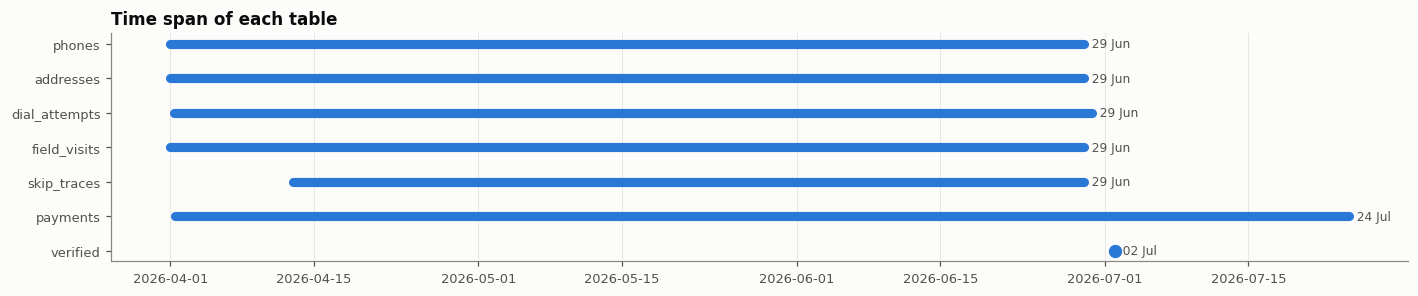

Note: payments run past the end of dialling, so there is a follow-up window to observe recovery after a contact.


In [ ]:
date_cols = [("phones", phones.added_date), ("addresses", addresses.added_date), ("dial_attempts", dials.attempt_ts),
             ("field_visits", visits.visit_date), ("skip_traces", skip.trace_date), ("payments", payments.payment_ts),
             ("verified", verified.verified_date)]
cov = pd.DataFrame({"table": [n for n, _ in date_cols], "first": [c.min() for _, c in date_cols],
                    "last": [c.max() for _, c in date_cols], "distinct_days": [c.dt.normalize().nunique() for _, c in date_cols]})
display(cov)
display(Markdown("**Phones added per date, by source** (non-skip-trace phones all share one load date):"))
display(phones.groupby("source").added_date.agg(["min", "max", "nunique"]))

# Timeline picture: each table's span on one date axis
fig, ax = plt.subplots(figsize=(13, 2.8))
for i, (n, c) in enumerate(date_cols):
    ax.plot([c.min(), c.max()], [i, i], lw=6, color=CAT[0], solid_capstyle="round")
    if c.min() == c.max():
        ax.scatter([c.min()], [i], s=60, color=CAT[0], zorder=3)
    ax.text(c.max(), i, f"  {c.max():%d %b}", va="center", fontsize=8, color=INK2)
ax.set_yticks(range(len(date_cols)), [n for n, _ in date_cols]); ax.invert_yaxis()
ax.set_title("Time span of each table"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("Note: payments run past the end of dialling, so there is a follow-up window to observe recovery after a contact.")

## 3. Is the train / validation / test split clean?
Two questions. **(a) Representativeness:** do the three splits look alike? A chi-square test compares category mixes; a small p-value (below 0.05) means a split differs more than chance would explain. **(b) Leakage:** does any phone number belong to accounts in different splits? If so, what a model learns about that number in train is effectively seen again at test time.

**Categorical columns across splits (chi-square)**

,column,chi2,dof,p_value,looks_balanced
0,lender_id,8.495,10,0.581,True
1,portfolio,6.566,10,0.766,True
2,income_type,2.651,4,0.618,True
3,town_id,3.873,4,0.424,True
4,preferred_language,4.834,4,0.305,True
5,bucket_start,6.104,8,0.636,True
6,bureau_score_band,17.815,8,0.023,False
7,last_bounce_reason,6.214,6,0.400,True
8,dialling_arm,1.371,2,0.504,True


**Numeric columns across splits (Kruskal-Wallis on medians)**

,column,median_train,median_validation,median_test,p_value
0,dpd_start,42.000,36.500,43.000,0.849
1,emi_amount,"4,300.000","4,200.000","4,500.000",0.937
2,outstanding,"126,000.000","114,800.000","120,950.000",0.543
3,ability_to_pay_estimate,0.540,0.540,0.540,0.989
4,prev_ptp_count,1.000,1.000,1.000,0.993


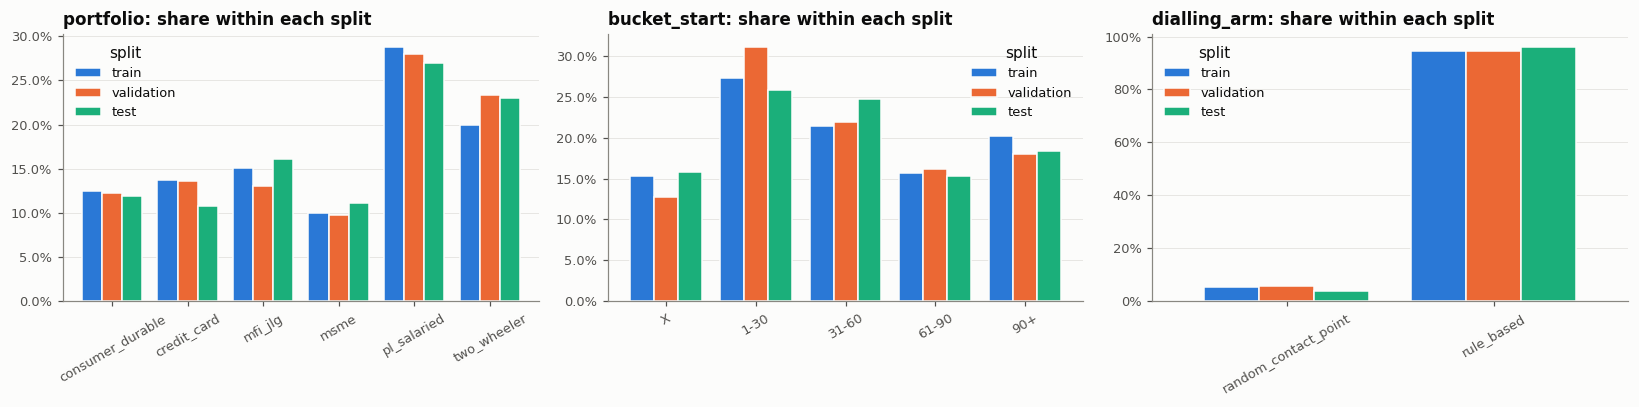

In [ ]:
cat_cols = ["lender_id", "portfolio", "income_type", "town_id", "preferred_language",
            "bucket_start", "bureau_score_band", "last_bounce_reason", "dialling_arm"]
rows = []
for c in cat_cols:
    ct = pd.crosstab(accounts[c], accounts["split"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({"column": c, "chi2": chi2, "dof": dof, "p_value": p, "looks_balanced": p > 0.05})
num_rows = []
for c in ["dpd_start", "emi_amount", "outstanding", "ability_to_pay_estimate", "prev_ptp_count"]:
    groups = [accounts.loc[accounts.split == s, c].dropna() for s in SPLIT_ORDER]
    h, p = stats.kruskal(*groups)
    num_rows.append({"column": c, **{f"median_{s}": g.median() for s, g in zip(SPLIT_ORDER, groups)}, "p_value": p})
display(Markdown("**Categorical columns across splits (chi-square)**")); display(pd.DataFrame(rows))
display(Markdown("**Numeric columns across splits (Kruskal-Wallis on medians)**")); display(pd.DataFrame(num_rows))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, c, order in zip(axes, ["portfolio", "bucket_start", "dialling_arm"], [None, BUCKET_ORDER, None]):
    sh = pd.crosstab(accounts[c], accounts["split"], normalize="columns")[SPLIT_ORDER]
    if order: sh = sh.reindex(order)
    sh.plot.bar(ax=ax, color=[SPLIT_COLORS[s] for s in SPLIT_ORDER], width=0.8, edgecolor=SURFACE, linewidth=1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_title(f"{c}: share within each split")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

In [ ]:
# ---- Leakage check: phone numbers shared by accounts in different splits ----
shared = phones[phones.phone_id.duplicated(keep=False)]
span = shared.groupby("phone_id").agg(n_accounts=("account_id", "nunique"), n_splits=("split", "nunique"),
                                       splits=("split", lambda s: ", ".join(sorted(set(s)))),
                                       source=("source", "first"), relation=("relation_recorded", "first"))
print(f"Phone numbers shared by 2+ accounts: {len(span)}  ({len(shared)} phone rows, "
      f"{shared.account_id.nunique()} accounts)")
print(f"…of which span more than one split (leakage risk): {(span.n_splits > 1).sum()}")
display(span.groupby(["source", "relation"]).agg(shared_numbers=("n_accounts", "size"),
                                                   max_accounts=("n_accounts", "max"),
                                                   spanning_splits=("n_splits", lambda s: (s > 1).sum())))

Phone numbers shared by 2+ accounts: 74  (175 phone rows, 175 accounts)
…of which span more than one split (leakage risk): 43


,,shared_numbers,max_accounts,spanning_splits
source,relation,,,
employer,office,68,5,39
kyc_origination,self,6,3,4


## 4. Accounts
### 4.1 Categorical columns
How accounts are spread across lenders, portfolios, delinquency buckets and so on. Small categories (a handful of accounts) will give noisy estimates later.

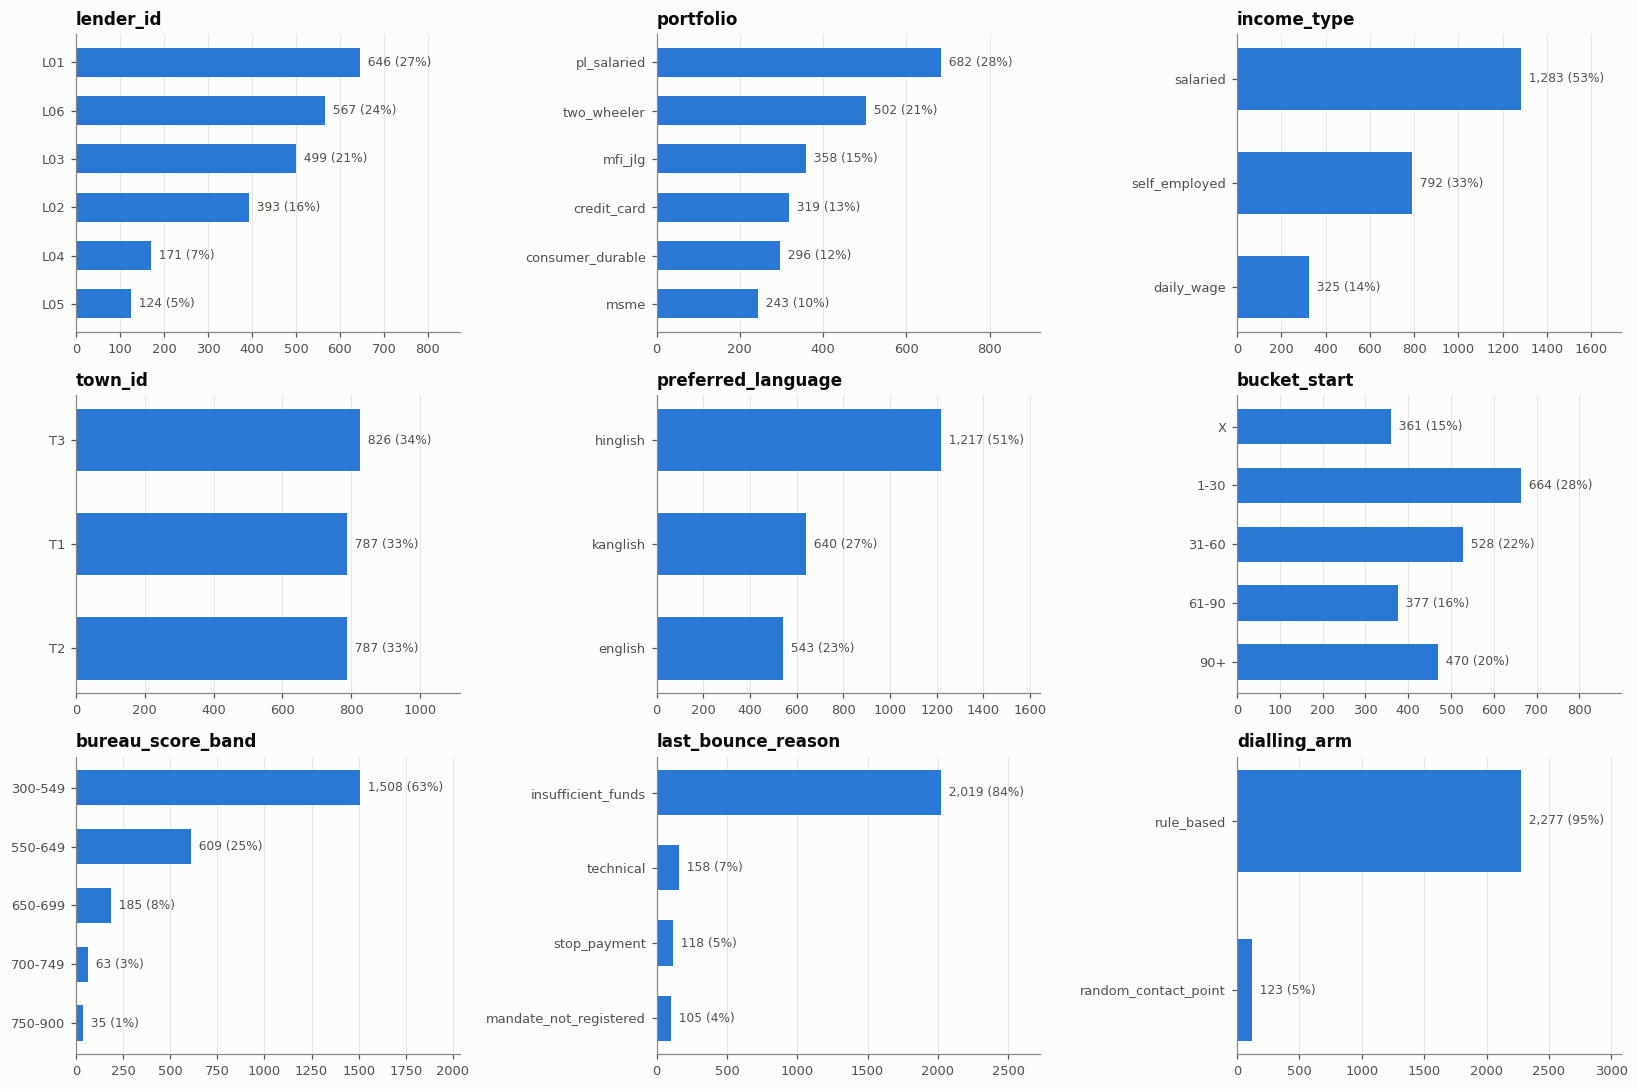

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
orders = {"bucket_start": BUCKET_ORDER, "bureau_score_band": BUREAU_ORDER}
for ax, c in zip(axes.ravel(), cat_cols):
    count_bar(accounts[c], ax, c, order=orders.get(c))
plt.tight_layout(); plt.show()

### 4.2 Numeric columns
Distributions of amounts, days past due and history. Money columns are very skewed, so they are shown on a log scale. `skew` above about 1 means a long right tail; consider a log transform before modelling.

,count,mean,std,min,5%,25%,50%,75%,95%,max,skew,missing_%
dpd_start,"2,400.000",66.363,87.742,0.000,0.000,11.000,41.000,80.000,238.000,720.000,2.776,0.000
emi_amount,"2,400.000","7,500.042","7,573.538",700.000,"1,250.000","2,600.000","4,300.000","10,062.500","24,000.000","39,950.000",2.116,0.000
overdue_start,"2,400.000","20,494.458","35,122.359",700.000,"1,650.000","4,100.000","9,450.000","21,362.500","75,710.000","460,200.000",5.316,0.000
outstanding,"2,400.000","217,014.708","258,223.188","6,300.000","25,200.000","60,912.500","122,925.000","265,400.000","745,535.000","2,117,000.000",2.769,0.000
salary_credit_day,762.000,11.142,10.047,1.000,1.000,1.000,7.000,15.000,30.000,30.000,0.814,68.250
ability_to_pay_estimate,"1,673.000",0.533,0.246,0.000,0.096,0.360,0.540,0.710,0.944,1.000,-0.126,30.292
other_active_loans,"2,400.000",1.902,1.400,0.000,0.000,1.000,2.000,3.000,4.000,8.000,0.669,0.000
prev_ptp_count,"2,400.000",1.549,1.575,0.000,0.000,0.000,1.000,2.000,5.000,10.000,1.267,0.000
prev_ptp_broken,"2,400.000",0.815,1.088,0.000,0.000,0.000,0.000,1.000,3.000,7.000,1.733,0.000


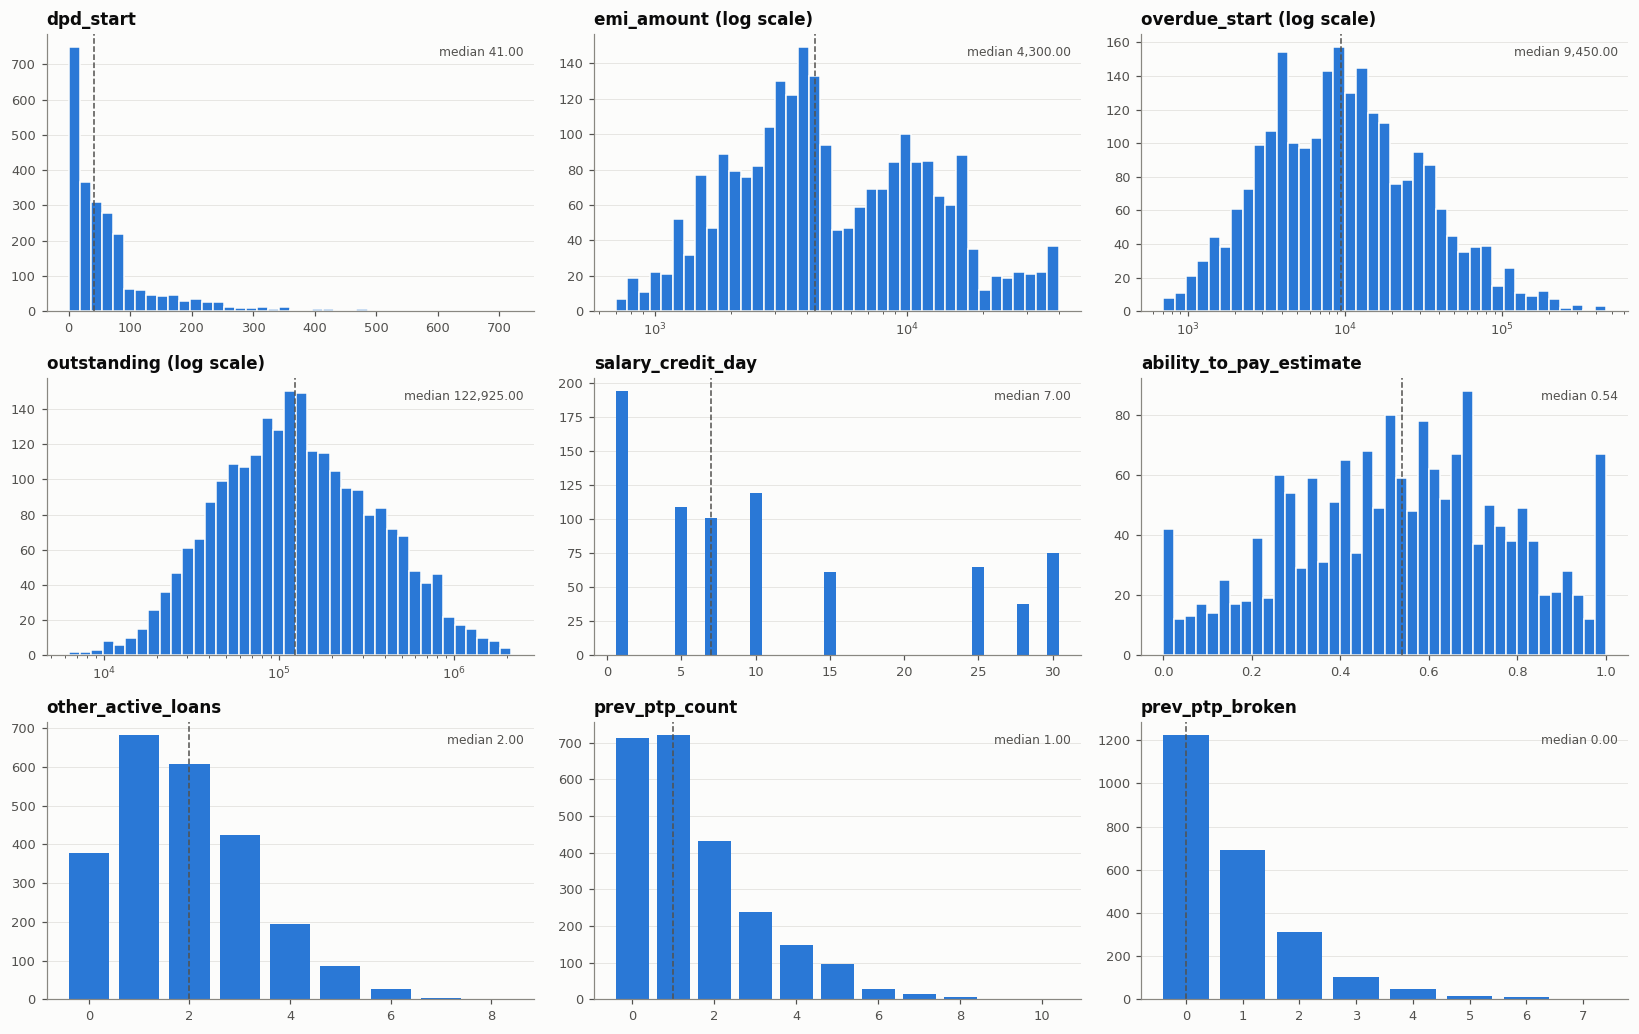

In [ ]:
num_cols = ["dpd_start", "emi_amount", "overdue_start", "outstanding", "salary_credit_day",
            "ability_to_pay_estimate", "other_active_loans", "prev_ptp_count", "prev_ptp_broken"]
desc = accounts[num_cols].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc["skew"] = accounts[num_cols].skew()
desc["missing_%"] = accounts[num_cols].isna().mean() * 100
display(desc)

log_cols = {"emi_amount", "overdue_start", "outstanding"}
fig, axes = plt.subplots(3, 3, figsize=(15, 9.5))
for ax, c in zip(axes.ravel(), num_cols):
    x = accounts[c].dropna()
    if c in log_cols:
        ax.hist(x, bins=np.logspace(np.log10(x.min()), np.log10(x.max()), 40), color=CAT[0], edgecolor=SURFACE)
        ax.set_xscale("log"); ax.set_title(f"{c} (log scale)")
    elif x.nunique() <= 31:
        vc = x.value_counts().sort_index(); ax.bar(vc.index, vc.values, color=CAT[0], width=0.8); ax.set_title(c)
    else:
        ax.hist(x, bins=40, color=CAT[0], edgecolor=SURFACE); ax.set_title(c)
    ax.axvline(x.median(), color=INK2, ls="--", lw=1)
    ax.text(0.98, 0.92, f"median {x.median():,.2f}", transform=ax.transAxes, ha="right", fontsize=8, color=INK2)
    ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 4.3 Missing values: random or meaningful?
Two columns have many gaps. If missingness lines up with a group (for example, salary day missing for everyone who isn't salaried), the gap carries information and should become a "has value" flag rather than being filled with an average.

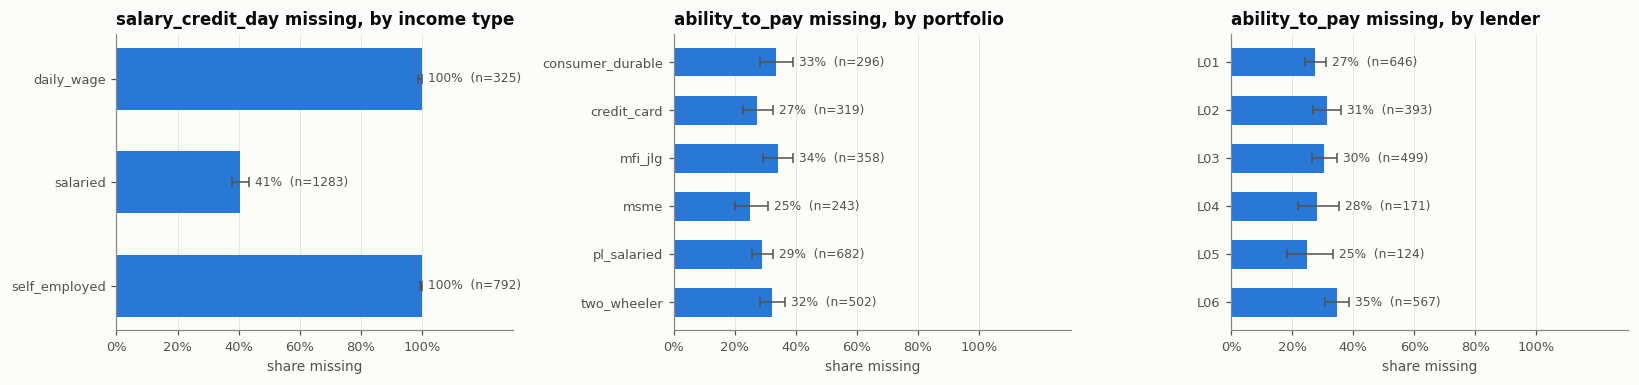

In [ ]:
acc = accounts.copy()
acc["salary_day_missing"] = acc.salary_credit_day.isna()
acc["atp_missing"] = acc.ability_to_pay_estimate.isna()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
plot_rate(rate_table(acc, "income_type", "salary_day_missing"), axes[0], "salary_credit_day missing, by income type", "share missing")
plot_rate(rate_table(acc, "portfolio", "atp_missing"), axes[1], "ability_to_pay missing, by portfolio", "share missing")
plot_rate(rate_table(acc, "lender_id", "atp_missing"), axes[2], "ability_to_pay missing, by lender", "share missing")
plt.tight_layout(); plt.show()

### 4.4 Internal consistency
Does `dpd_start` (days past due) fall inside the range its delinquency bucket implies? Does overdue ÷ EMI (roughly, number of EMIs missed) line up with days past due ÷ 30? Mismatches point to data-entry issues or business rules worth asking CN about.

,count,mean,std,min,25%,50%,75%,max
bucket_start,,,,,,,,
X,361.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1-30,664.000,15.127,8.403,1.000,8.000,15.000,22.000,30.000
31-60,528.000,45.928,8.795,31.000,38.000,46.500,53.000,60.000
61-90,377.000,74.820,8.456,61.000,67.000,75.000,83.000,90.000
90+,470.000,205.896,109.501,91.000,127.000,172.000,239.500,720.000


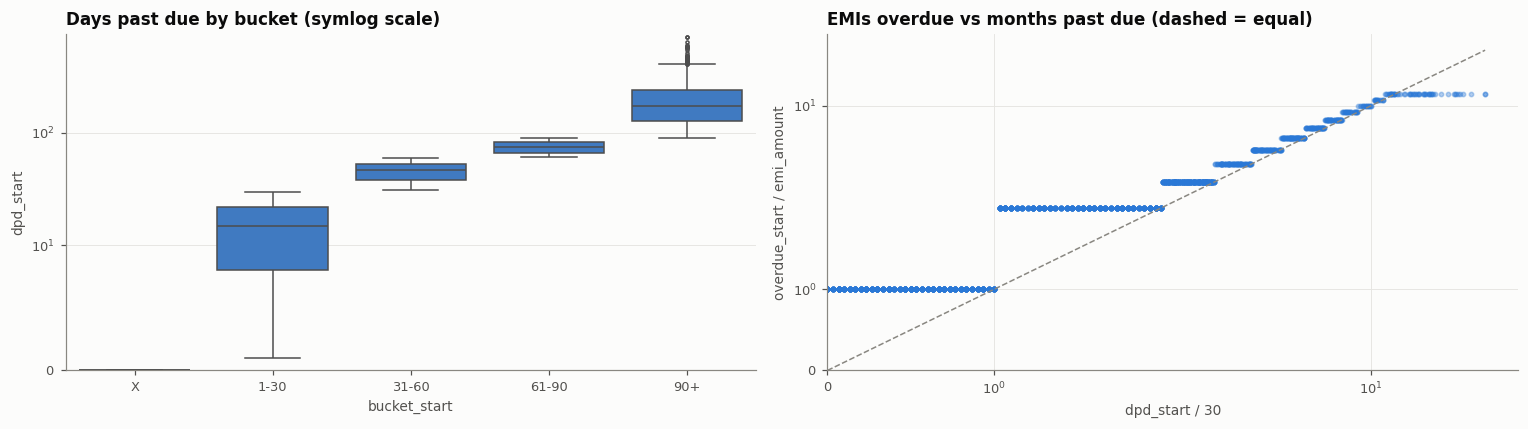

Spearman correlation, months past due vs EMIs overdue: 0.954


In [ ]:
acc["emis_overdue"] = acc.overdue_start / acc.emi_amount
acc["dpd_months"] = acc.dpd_start / 30
display(acc.groupby("bucket_start").dpd_start.describe().reindex(BUCKET_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=acc, x="bucket_start", y="dpd_start", order=BUCKET_ORDER, color=CAT[0], fliersize=2, ax=axes[0])
axes[0].set_title("Days past due by bucket (symlog scale)"); axes[0].set_yscale("symlog", linthresh=10); axes[0].set_ylim(bottom=0)
axes[1].scatter(acc.dpd_months, acc.emis_overdue, s=8, alpha=0.35, color=CAT[0])
lim = max(acc.dpd_months.max(), acc.emis_overdue.max())
axes[1].plot([0, lim], [0, lim], color=MUTED, ls="--", lw=1)
axes[1].set_xscale("symlog"); axes[1].set_yscale("symlog"); axes[1].set_xlim(left=0); axes[1].set_ylim(bottom=0)
axes[1].set_xlabel("dpd_start / 30"); axes[1].set_ylabel("overdue_start / emi_amount")
axes[1].set_title("EMIs overdue vs months past due (dashed = equal)")
plt.tight_layout(); plt.show()
print("Spearman correlation, months past due vs EMIs overdue:", round(acc[["dpd_months", "emis_overdue"]].corr("spearman").iloc[0, 1], 3))

### 4.5 How account attributes relate to each other
Mix of buckets within each portfolio, size of loans by portfolio, and whether the ability-to-pay estimate tracks the bureau score.

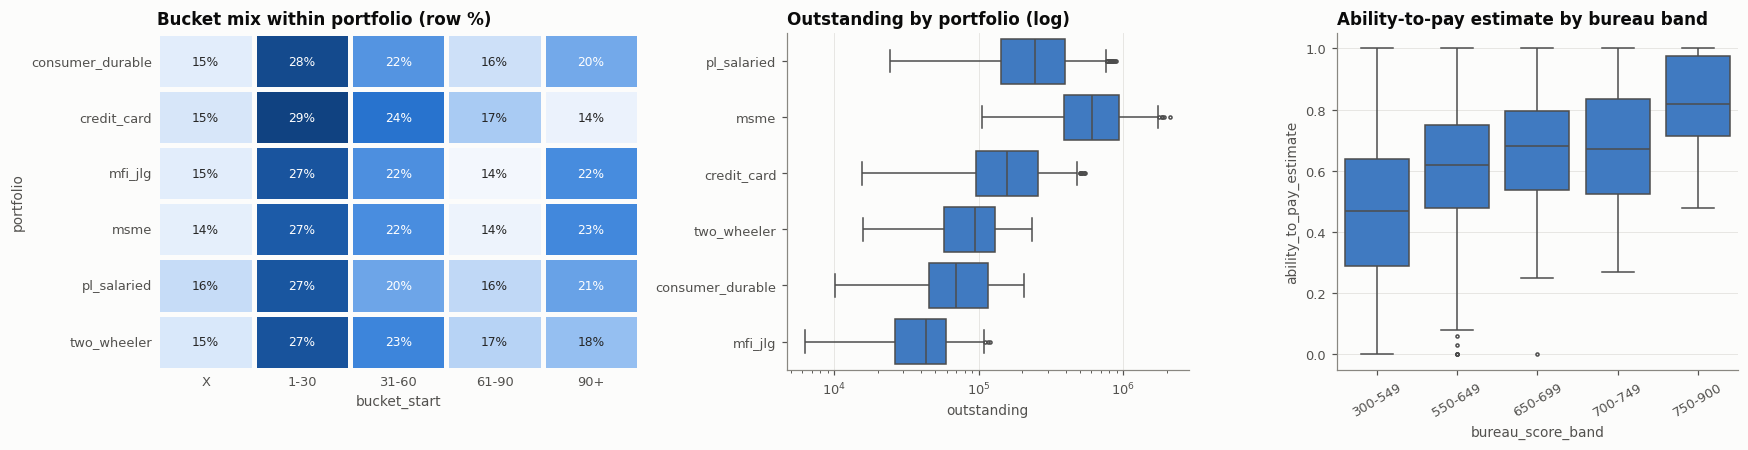

**Past promise-to-pay behaviour by portfolio** (break rate among accounts with at least one past PTP)

,accounts,any_prev_ptp,mean_ptps,break_rate
portfolio,,,,
consumer_durable,296,0.669,1.524,0.524
credit_card,319,0.683,1.320,0.494
mfi_jlg,358,0.684,1.595,0.534
msme,243,0.741,1.667,0.499
pl_salaried,682,0.701,1.560,0.529
two_wheeler,502,0.733,1.606,0.497


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1.2, 1, 1]})
heat(pd.crosstab(acc.portfolio, acc.bucket_start, normalize="index")[BUCKET_ORDER], axes[0], "Bucket mix within portfolio (row %)")
sns.boxplot(data=acc, y="portfolio", x="outstanding", color=CAT[0], fliersize=2, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title("Outstanding by portfolio (log)"); axes[1].set_ylabel("")
sns.boxplot(data=acc, x="bureau_score_band", y="ability_to_pay_estimate", order=BUREAU_ORDER, color=CAT[0], fliersize=2, ax=axes[2])
axes[2].set_title("Ability-to-pay estimate by bureau band"); axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

acc["ptp_break_rate"] = np.where(acc.prev_ptp_count > 0, acc.prev_ptp_broken / acc.prev_ptp_count, np.nan)
display(Markdown("**Past promise-to-pay behaviour by portfolio** (break rate among accounts with at least one past PTP)"))
display(acc.groupby("portfolio").agg(accounts=("account_id", "size"), any_prev_ptp=("prev_ptp_count", lambda s: (s > 0).mean()),
                                     mean_ptps=("prev_ptp_count", "mean"), break_rate=("ptp_break_rate", "mean")))

### 4.6 Correlations
**Left:** Spearman correlation between numeric columns (rank-based, so robust to the skewed money columns). Values near ±1 mean two columns carry nearly the same information; you may not need both in a model. **Right:** Cramér's V between categorical columns (0 = unrelated, 1 = one determines the other).

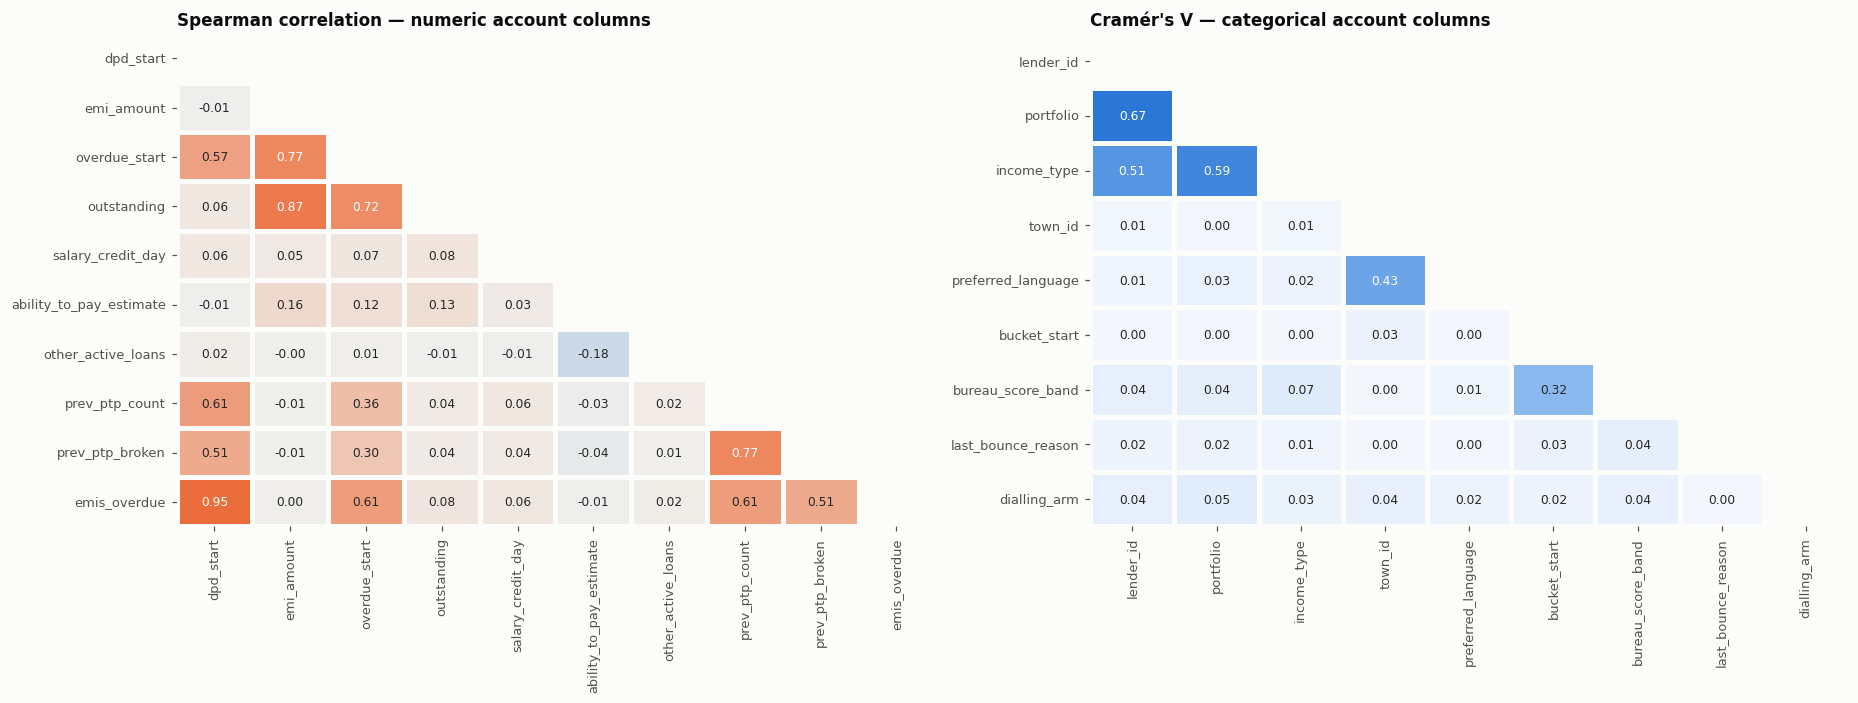

**Strongest numeric pairs**

spearman
dpd_start      emis_overdue        0.954
emi_amount     outstanding         0.865
               overdue_start       0.770
prev_ptp_count prev_ptp_broken     0.770
overdue_start  outstanding         0.719
dpd_start      prev_ptp_count      0.612
prev_ptp_count emis_overdue        0.609
overdue_start  emis_overdue        0.608

In [ ]:
num_for_corr = num_cols + ["emis_overdue"]
corr = acc[num_for_corr].corr("spearman")
cat_v = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for a in cat_cols:
    for b in cat_cols:
        cat_v.loc[a, b] = 1.0 if a == b else cramers_v(acc[a], acc[b])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide the diagonal and the mirrored half
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=DIV, center=0, vmin=-1, vmax=1, linewidths=2,
            linecolor=SURFACE, cbar=False, ax=axes[0], annot_kws={"fontsize": 8})
axes[0].set_title("Spearman correlation — numeric account columns"); axes[0].grid(False)
mask2 = np.triu(np.ones_like(cat_v, dtype=bool))
sns.heatmap(cat_v, mask=mask2, annot=True, fmt=".2f", cmap=SEQ, vmin=0, vmax=1, linewidths=2,
            linecolor=SURFACE, cbar=False, ax=axes[1], annot_kws={"fontsize": 8})
axes[1].set_title("Cramér's V — categorical account columns"); axes[1].grid(False)
plt.tight_layout(); plt.show()

pairs = corr.where(~np.tril(np.ones_like(corr, dtype=bool))).stack().sort_values(key=abs, ascending=False)
display(Markdown("**Strongest numeric pairs**")); display(pairs.head(8).to_frame("spearman"))

### 4.7 Lenders
A small reference table. `kyc_address_format` describes how each lender stores addresses (upper case, mixed case or free text typed in an app), which matters for address parsing in phase 2. Here it's joined to accounts to see how much of the book each lender type holds.

,lender_id,lender_name,lender_type,kyc_address_format
0,L01,Lender A,Private bank,kyc_mixed
1,L02,Lender B,NBFC,kyc_upper
2,L03,Lender C,Fintech NBFC,app_free_text
3,L04,Lender D,NBFC-MFI,kyc_mixed
4,L05,Lender E,NBFC (MSME),kyc_upper
5,L06,Lender F,Small finance bank,app_free_text


,,,,accounts,median_outstanding,top_portfolio,share_90plus
lender_id,lender_name,lender_type,kyc_address_format,,,,
L01,Lender A,Private bank,kyc_mixed,646,"196,900.000",pl_salaried,0.173
L02,Lender B,NBFC,kyc_upper,393,"81,600.000",two_wheeler,0.176
L03,Lender C,Fintech NBFC,app_free_text,499,"172,000.000",pl_salaried,0.212
L04,Lender D,NBFC-MFI,kyc_mixed,171,"43,500.000",mfi_jlg,0.251
L05,Lender E,NBFC (MSME),kyc_upper,124,"598,650.000",msme,0.194
L06,Lender F,Small finance bank,app_free_text,567,"85,100.000",two_wheeler,0.205


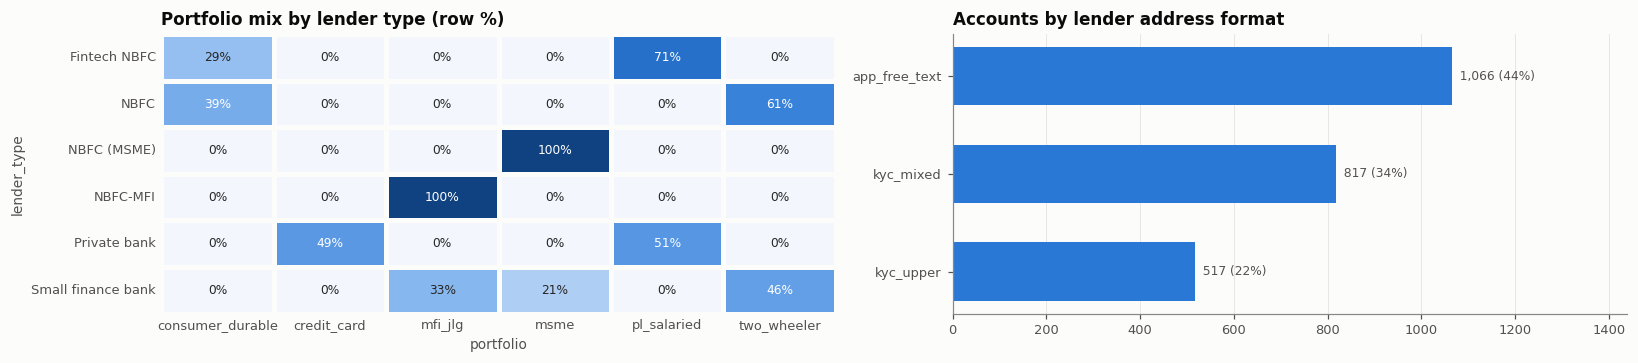

In [ ]:
display(lenders)
lend_acc = accounts.merge(lenders, on="lender_id")
display(lend_acc.groupby(["lender_id", "lender_name", "lender_type", "kyc_address_format"]).agg(
    accounts=("account_id", "size"), median_outstanding=("outstanding", "median"),
    top_portfolio=("portfolio", lambda s: s.value_counts().index[0]), share_90plus=("bucket_start", lambda s: (s == "90+").mean())))
fig, axes = plt.subplots(1, 2, figsize=(15, 3.4))
heat(pd.crosstab(lend_acc.lender_type, lend_acc.portfolio, normalize="index"), axes[0], "Portfolio mix by lender type (row %)")
count_bar(lend_acc.kyc_address_format, axes[1], "Accounts by lender address format")
plt.tight_layout(); plt.show()

## 5. Phones (the contact points we need to score)
### 5.1 How many numbers does each account have, and where did they come from?
`source` says how the number entered the system; `relation_recorded` says whose number it was claimed to be; `priority_slot` is the dialling order (0 = tried first). Keep in mind that the recorded relation is what was *written down*, not necessarily the truth; Section 6 checks that.

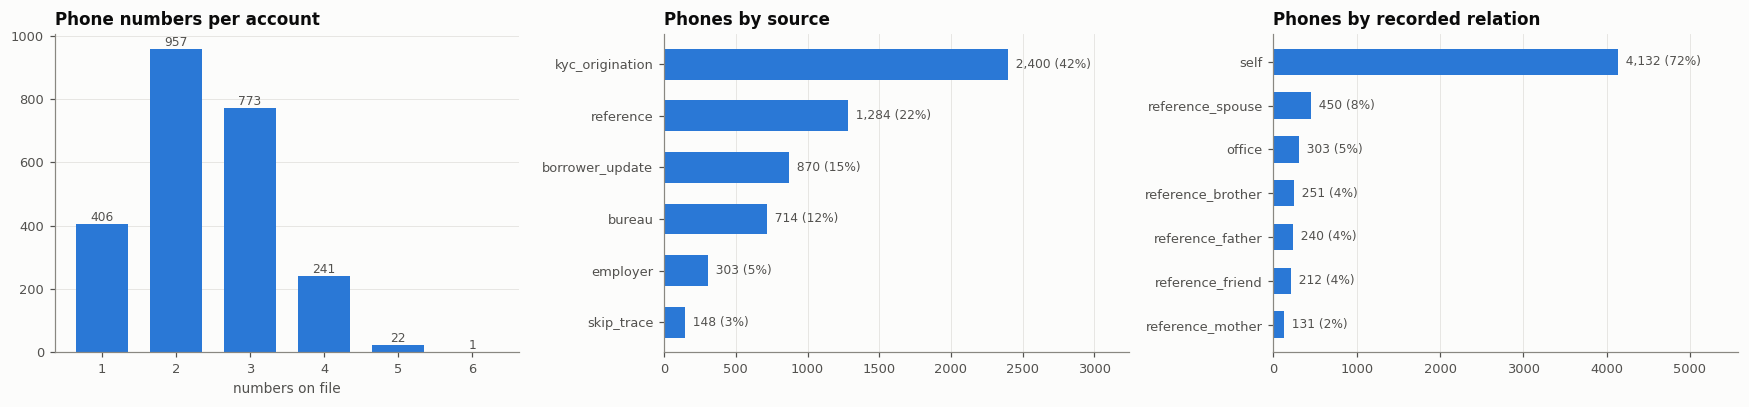

**Average numbers on file per account, by portfolio**

,mean,min,50%,max
portfolio,,,,
consumer_durable,2.446,1.000,2.000,5.000
credit_card,2.392,1.000,2.000,6.000
mfi_jlg,2.235,1.000,2.000,5.000
msme,2.259,1.000,2.000,4.000
pl_salaried,2.493,1.000,2.000,5.000
two_wheeler,2.357,1.000,2.000,5.000


In [ ]:
per_acct = phones.groupby("account_id").size().rename("n_phones")
acc = acc.merge(per_acct, left_on="account_id", right_index=True, how="left")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
vc = per_acct.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=CAT[0], width=0.7)
for x, v in zip(vc.index, vc.values): axes[0].text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=8, color=INK2)
axes[0].set_title("Phone numbers per account"); axes[0].set_xlabel("numbers on file"); axes[0].grid(axis="x", visible=False)
count_bar(phones.source, axes[1], "Phones by source")
count_bar(phones.relation_recorded, axes[2], "Phones by recorded relation")
plt.tight_layout(); plt.show()

display(Markdown("**Average numbers on file per account, by portfolio**"))
display(acc.groupby("portfolio").n_phones.describe()[["mean", "min", "50%", "max"]])

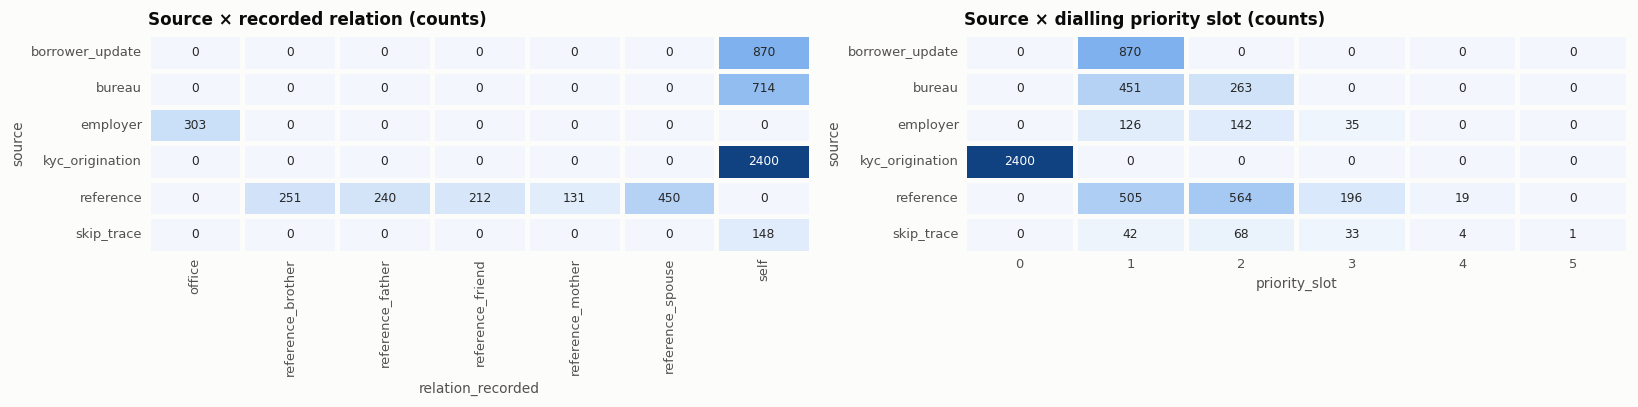

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
heat(pd.crosstab(phones.source, phones.relation_recorded), axes[0], "Source × recorded relation (counts)", fmt="d")
heat(pd.crosstab(phones.source, phones.priority_slot), axes[1], "Source × dialling priority slot (counts)", fmt="d")
plt.tight_layout(); plt.show()

### 5.2 Shared numbers
The same `phone_id` on several accounts. Office lines shared by colleagues are normal. A number recorded as the borrower's **own** (`self`) on several unrelated accounts is a warning sign: it could be an agent's or dealer's number entered at origination, or a recycled number.

In [ ]:
phones["is_shared"] = phones.phone_id.duplicated(keep=False)
sh = phones[phones.is_shared].merge(accounts[["account_id", "lender_id", "portfolio", "town_id"]], on="account_id")
sh_summary = sh.groupby("phone_id").agg(n_accounts=("account_id", "nunique"), relation=("relation_recorded", "first"),
                                        n_lenders=("lender_id", "nunique"), n_towns=("town_id", "nunique"),
                                        n_portfolios=("portfolio", "nunique"))
display(sh_summary.groupby("relation").agg(numbers=("n_accounts", "size"), avg_accounts=("n_accounts", "mean"),
                                           across_lenders=("n_lenders", lambda s: (s > 1).mean()),
                                           across_towns=("n_towns", lambda s: (s > 1).mean())))
display(Markdown("**'Self' numbers shared across accounts (worth flagging):**"))
display(sh[sh.relation_recorded == "self"].sort_values("phone_id")[["phone_id", "account_id", "source", "lender_id", "portfolio", "town_id", "split"]])

,numbers,avg_accounts,across_lenders,across_towns
relation,,,,
office,68,2.382,0.750,0.000
self,6,2.167,0.667,0.833


**'Self' numbers shared across accounts (worth flagging):**

,phone_id,account_id,source,lender_id,portfolio,town_id,split
141,PH000056,AC001992,kyc_origination,L06,two_wheeler,T1,test
171,PH000056,AC002373,kyc_origination,L04,mfi_jlg,T3,validation
13,PH000143,AC000153,kyc_origination,L03,consumer_durable,T2,train
32,PH000143,AC000444,kyc_origination,L06,msme,T3,train
101,PH000143,AC001433,kyc_origination,L06,two_wheeler,T1,train
65,PH000146,AC000981,kyc_origination,L02,consumer_durable,T3,train
102,PH000146,AC001436,kyc_origination,L02,two_wheeler,T3,train
39,PH000194,AC000594,kyc_origination,L03,consumer_durable,T1,validation
100,PH000194,AC001420,kyc_origination,L06,two_wheeler,T3,train
90,PH000212,AC001312,kyc_origination,L01,credit_card,T2,train


### 5.3 Can `phone_masked` identify a number?
It shows only the last 4 digits, so there are only 10,000 possible values. With thousands of numbers, many will share the same last 4 digits purely by chance. If the observed overlap matches what chance predicts, `phone_masked` must **not** be used to link numbers; use `phone_id`.

In [ ]:
uniq = phones.drop_duplicates("phone_id")
n = len(uniq)
expected_distinct = 10_000 * (1 - (1 - 1 / 10_000) ** n)
print(f"Distinct phone_ids: {n:,}")
print(f"Distinct masked values observed: {uniq.phone_masked.nunique():,}")
print(f"Distinct masked values expected by pure chance: {expected_distinct:,.0f}")
if abs(uniq.phone_masked.nunique() - expected_distinct) / expected_distinct < 0.05:
    print("→ Observed ≈ chance: the masked value carries no identity information. Link numbers with phone_id only.")
else:
    print("→ Observed differs from chance: masked values may carry some structure; investigate before using.")

Distinct phone_ids: 5,618
Distinct masked values observed: 4,339
Distinct masked values expected by pure chance: 4,298
→ Observed ≈ chance: the masked value carries no identity information. Link numbers with phone_id only.


## 6. Verified contact points (closest thing to ground truth)
A sample of numbers was checked manually **after** the data window. This is the only place where we see a phone's *true* state, rather than inferring it from dial outcomes. It's small, so every rate is shown with a 95% confidence interval; wide whiskers mean "don't over-read this".

The label we care about most: `reaches_borrower` = the verified status is `borrower_number`.

Verified numbers in this view: 173  |  reach the borrower: 50.9%


,verified numbers per split
split,
train,173
validation,41
test,36


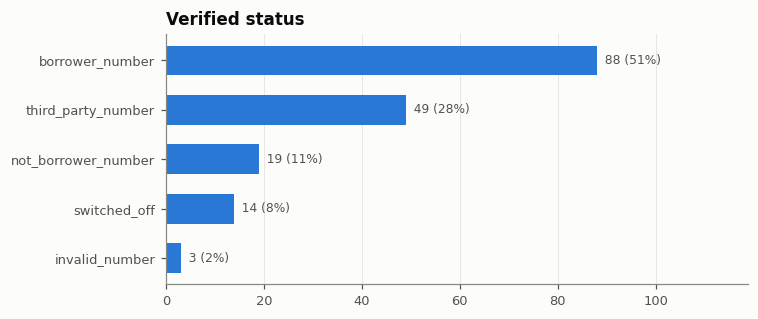

In [ ]:
v = outcome_view(verified).merge(phones.drop_duplicates(["phone_id", "account_id"])[["phone_id", "account_id", "source", "relation_recorded", "priority_slot", "is_shared"]],
                                 on=["phone_id", "account_id"], how="left")
v = v.merge(accounts.drop(columns="split"), on="account_id", how="left")
v["reaches_borrower"] = (v.verified_status == "borrower_number").astype(int)
v["recorded_self"] = v.relation_recorded == "self"
overall = v.reaches_borrower.mean()

print(f"Verified numbers in this view: {len(v)}  |  reach the borrower: {overall:.1%}")
display(verified.split.value_counts().reindex(SPLIT_ORDER).to_frame("verified numbers per split"))  # counts only, no test labels

fig, ax = plt.subplots(figsize=(7, 3))
count_bar(v.verified_status, ax, "Verified status")
plt.tight_layout(); plt.show()

### 6.1 Which numbers turn out to be the borrower's?
Rate of `reaches_borrower` by where the number came from, what relation was recorded, its dialling slot, and whether it's shared. The dashed line is the overall rate.

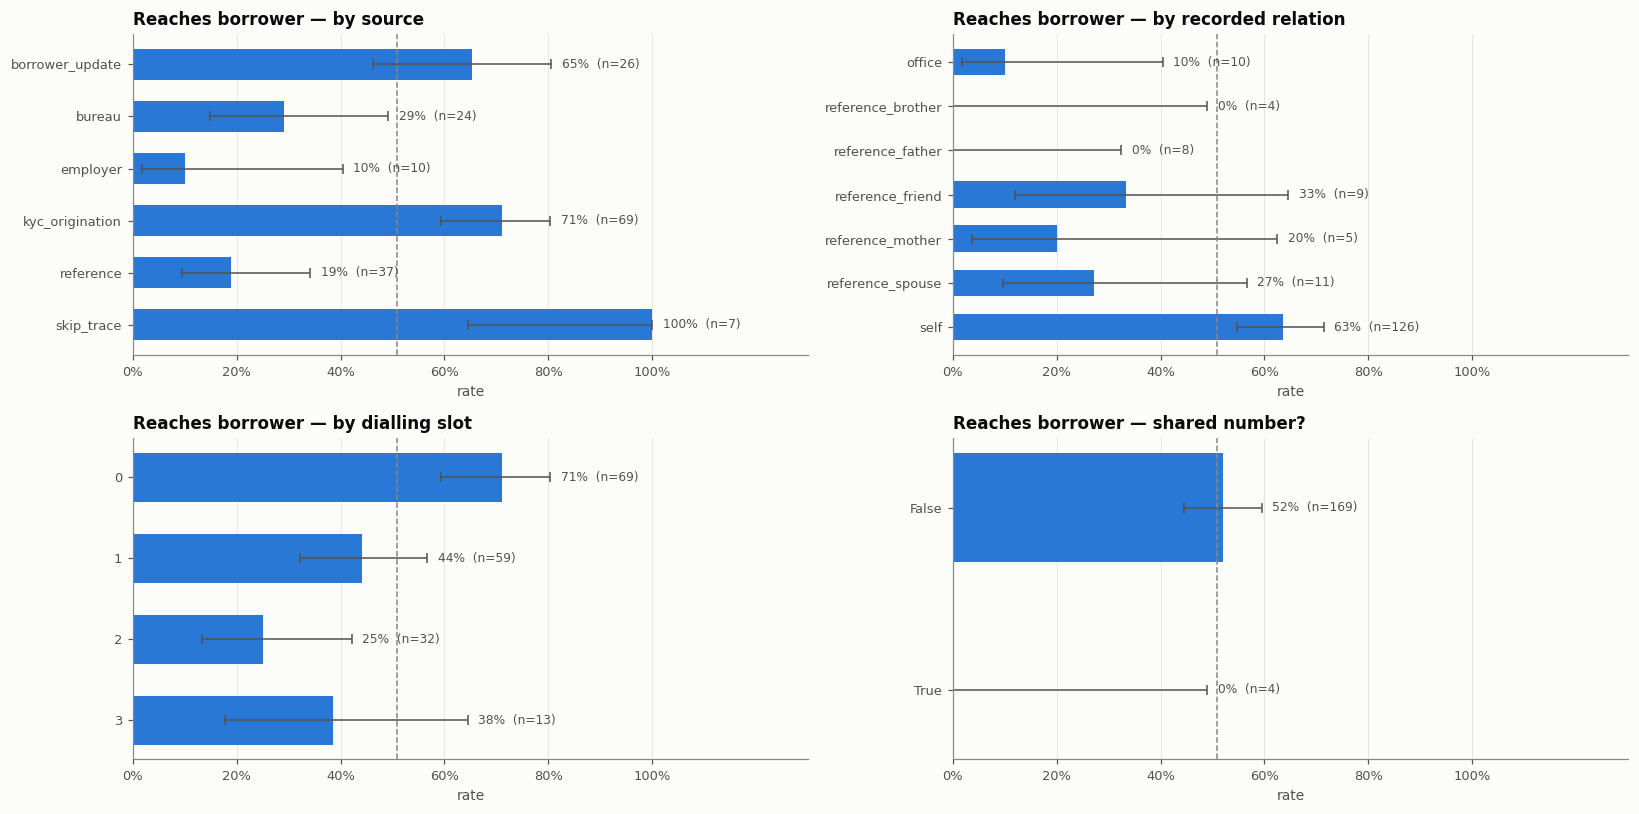

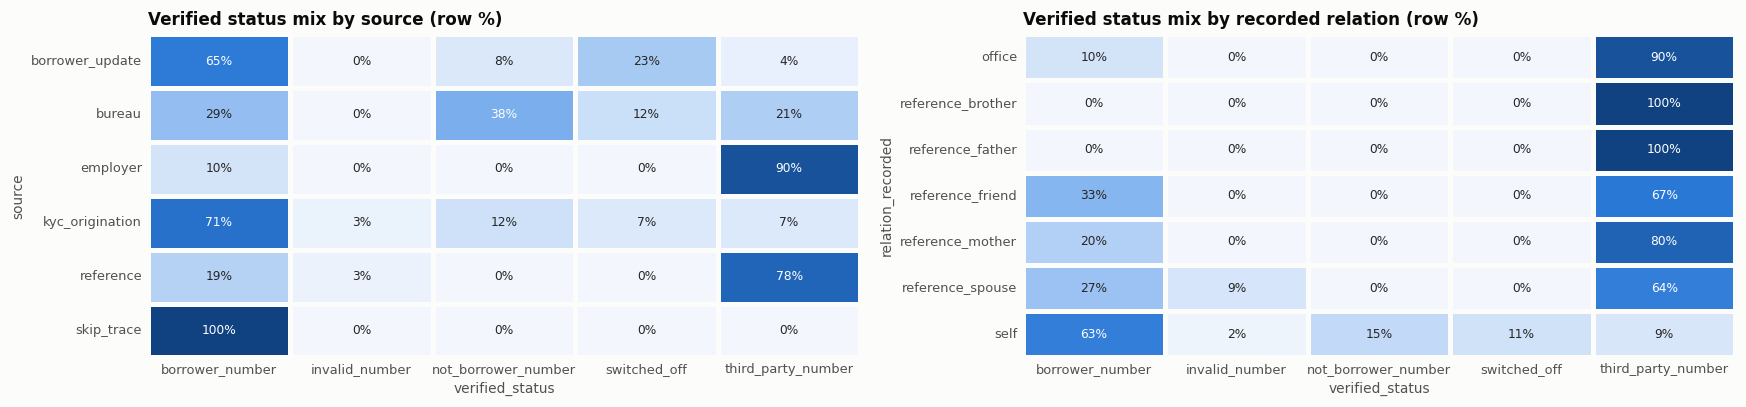

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 7.5))
plot_rate(rate_table(v, "source", "reaches_borrower"), axes[0, 0], "Reaches borrower — by source", overall=overall)
plot_rate(rate_table(v, "relation_recorded", "reaches_borrower"), axes[0, 1], "Reaches borrower — by recorded relation", overall=overall)
plot_rate(rate_table(v, "priority_slot", "reaches_borrower"), axes[1, 0], "Reaches borrower — by dialling slot", overall=overall)
plot_rate(rate_table(v, "is_shared", "reaches_borrower"), axes[1, 1], "Reaches borrower — shared number?", overall=overall)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 3.8))
heat(pd.crosstab(v.source, v.verified_status, normalize="index"), axes[0], "Verified status mix by source (row %)")
heat(pd.crosstab(v.relation_recorded, v.verified_status, normalize="index"), axes[1], "Verified status mix by recorded relation (row %)")
plt.tight_layout(); plt.show()

### 6.2 Recorded relation vs reality: the compliance risk
Numbers recorded as the borrower's own (`self`) that are actually someone else's. An agent dialling these believes they're talking to the borrower, which is exactly how a debt gets disclosed to a third party.

In [ ]:
self_v = v[v.recorded_self]
risky = self_v[self_v.verified_status.isin(["third_party_number", "not_borrower_number"])]
print(f"Verified numbers recorded as 'self': {len(self_v)}")
p, lo, hi = wilson(len(risky), len(self_v))
print(f"…actually a third party or someone else: {len(risky)} ({p:.0%}, 95% CI {lo:.0%}–{hi:.0%})")
display(pd.crosstab(self_v.source, self_v.verified_status, margins=True))

Verified numbers recorded as 'self': 126
…actually a third party or someone else: 30 (24%, 95% CI 17%–32%)


verified_status,borrower_number,invalid_number,not_borrower_number,switched_off,third_party_number,All
source,,,,,,
borrower_update,17,0,2,6,1,26
bureau,7,0,9,3,5,24
kyc_origination,49,2,8,5,5,69
skip_trace,7,0,0,0,0,7
All,80,2,19,14,11,126


### 6.3 Does the account profile matter?
Same rate, split by account attributes. Mostly useful to see whether some portfolios have systematically worse contact data.

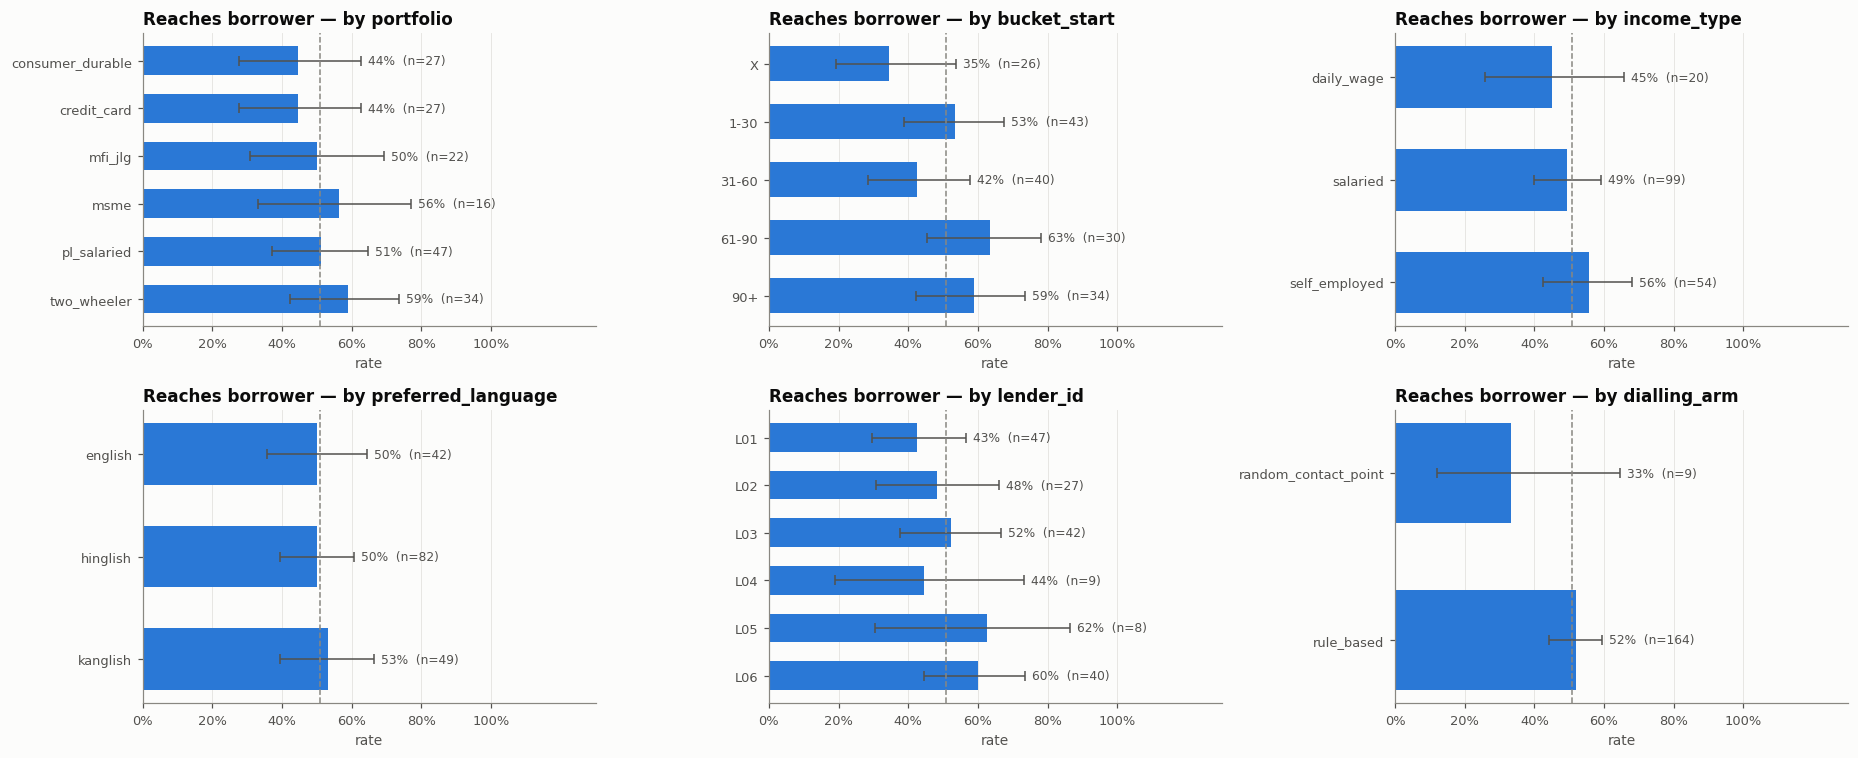

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 7))
for ax, (c, order) in zip(axes.ravel(), [("portfolio", None), ("bucket_start", BUCKET_ORDER), ("income_type", None),
                                         ("preferred_language", None), ("lender_id", None), ("dialling_arm", None)]):
    plot_rate(rate_table(v, c, "reaches_borrower", order), ax, f"Reaches borrower — by {c}", overall=overall)
plt.tight_layout(); plt.show()

### 6.4 Is the verified sample representative?
If verification targeted particular kinds of numbers, rates above can't be generalised to all phones. Compare the source mix of verified numbers with all numbers.

,all_phones,verified_sample,ratio_verified_to_all
source,,,
kyc_origination,0.420,0.388,0.925
reference,0.225,0.228,1.016
borrower_update,0.152,0.144,0.947
bureau,0.125,0.132,1.057
employer,0.053,0.060,1.132
skip_trace,0.026,0.048,1.855


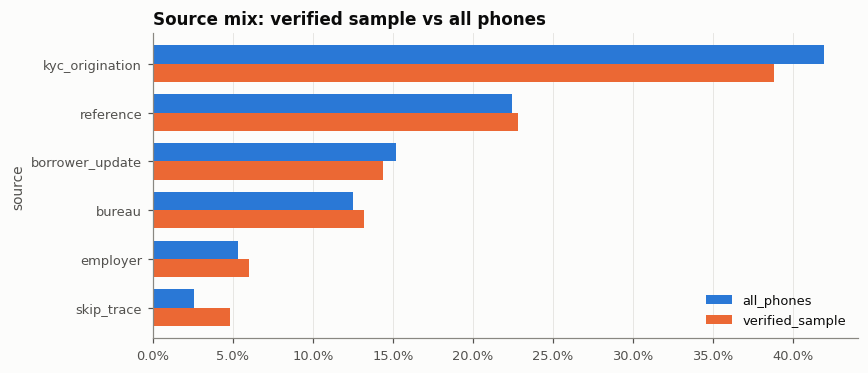

In [ ]:
comp = pd.DataFrame({"all_phones": phones.source.value_counts(normalize=True),
                     "verified_sample": verified.merge(phones.drop_duplicates(["phone_id", "account_id"]),
                                                       on=["phone_id", "account_id"]).source.value_counts(normalize=True)}).fillna(0)
comp["ratio_verified_to_all"] = comp.verified_sample / comp.all_phones
display(comp.sort_values("all_phones", ascending=False))
ax = comp[["all_phones", "verified_sample"]].plot.barh(figsize=(8, 3.5), color=[CAT[0], CAT[1]], width=0.75)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.invert_yaxis(); ax.set_title("Source mix: verified sample vs all phones")
ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

## 7. Skip traces (how tracing works today)
The current policy triggers a trace after a fixed number of failed contacts. This section measures how often that pays off and what it costs, which is the baseline your value-of-information rule has to beat.

Trigger rules in use: {'15_consecutive_failed_contacts': 766}
Traces in this view: 523  |  success (new phone or address): 21.8% (95% CI 18.5%–25.5%)
Total cost ₹54,621  |  mean cost per trace ₹104  |  cost per successful trace ₹479


,count,mean,std,min,25%,50%,75%,max
result,,,,,,,,
new_address_found,19.000,97.263,27.614,62.000,73.000,92.000,115.000,150.000
new_phone_found,95.000,105.389,26.787,60.000,81.500,103.000,130.500,150.000
no_new_info,409.000,104.550,27.337,60.000,80.000,104.000,128.000,150.000


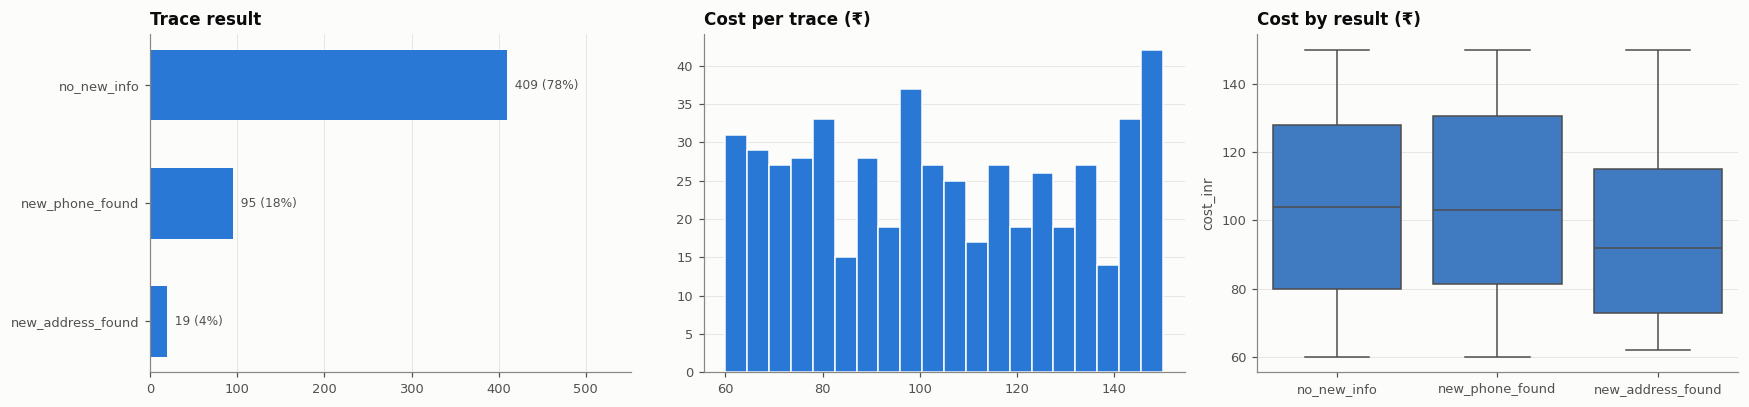

Does cost differ by result? Kruskal-Wallis p = 0.499  (above 0.05 → no evidence cost predicts success)


In [ ]:
print("Trigger rules in use:", skip.trigger_rule.value_counts().to_dict())
s = outcome_view(skip)
s["success"] = (s.result != "no_new_info").astype(int)
p, lo, hi = wilson(s.success.sum(), len(s))
total_cost = s.cost_inr.sum()
print(f"Traces in this view: {len(s)}  |  success (new phone or address): {p:.1%} (95% CI {lo:.1%}–{hi:.1%})")
print(f"Total cost ₹{total_cost:,.0f}  |  mean cost per trace ₹{s.cost_inr.mean():.0f}  |  cost per successful trace ₹{total_cost / max(1, s.success.sum()):,.0f}")
display(s.groupby("result").cost_inr.describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
count_bar(s.result, axes[0], "Trace result")
axes[1].hist(s.cost_inr, bins=20, color=CAT[0], edgecolor=SURFACE); axes[1].set_title("Cost per trace (₹)"); axes[1].grid(axis="x", visible=False)
sns.boxplot(data=s, x="result", y="cost_inr", color=CAT[0], ax=axes[2]); axes[2].set_title("Cost by result (₹)"); axes[2].set_xlabel("")
plt.tight_layout(); plt.show()
kw = stats.kruskal(*[g.cost_inr for _, g in s.groupby("result")])
print(f"Does cost differ by result? Kruskal-Wallis p = {kw.pvalue:.3f}  (above 0.05 → no evidence cost predicts success)")

### 7.1 Over time and repeat traces
Weekly volume by result, and whether a second trace on the same account does better or worse than the first.

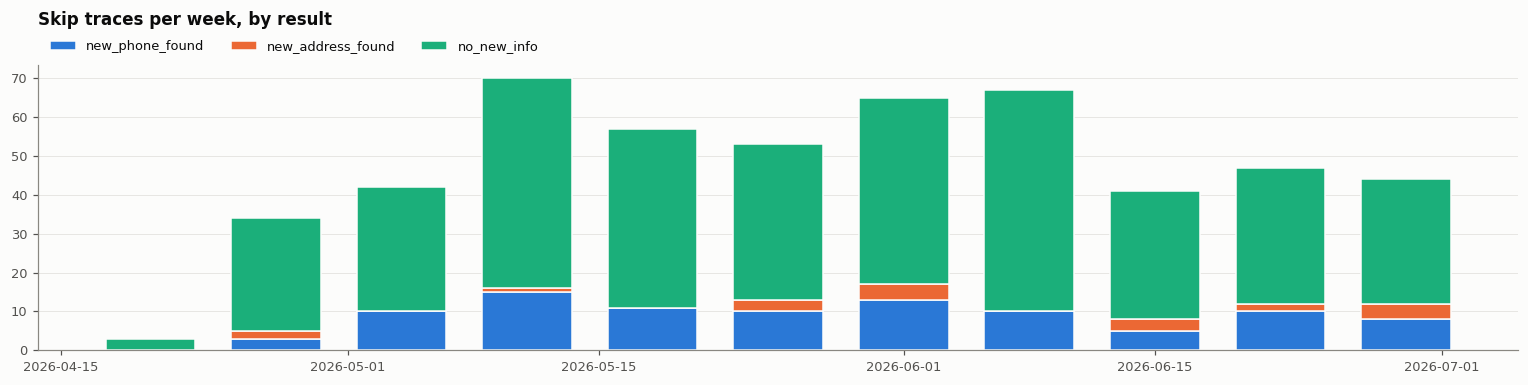

**Success by trace number on the same account**

,n,positives,rate,ci_low,ci_high
trace_number,,,,,
1,412,93,0.226,0.188,0.269
2,106,20,0.189,0.126,0.274
3,5,1,0.200,0.036,0.624


**Days between repeat traces**

,days_since_prev_trace
count,111.000
mean,31.685
std,4.739
min,30.000
25%,30.000
50%,30.000
75%,30.000
max,54.000


In [ ]:
wk = s.set_index("trace_date").groupby([pd.Grouper(freq="W-MON"), "result"]).size().unstack(fill_value=0)
order_res = ["new_phone_found", "new_address_found", "no_new_info"]
wk = wk.reindex(columns=[c for c in order_res if c in wk.columns])
fig, ax = plt.subplots(figsize=(14, 3.6))
bottom = np.zeros(len(wk))
for i, c in enumerate(wk.columns):
    ax.bar(wk.index, wk[c], bottom=bottom, width=5, color=CAT[i], label=c, edgecolor=SURFACE, linewidth=1)
    bottom += wk[c].values
ax.legend(ncols=3, loc="lower left", bbox_to_anchor=(0, 1.0)); ax.set_title("Skip traces per week, by result", pad=26); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

s = s.sort_values(["account_id", "trace_date"])
s["trace_number"] = s.groupby("account_id").cumcount() + 1
s["days_since_prev_trace"] = s.groupby("account_id").trace_date.diff().dt.days
display(Markdown("**Success by trace number on the same account**"))
display(rate_table(s, "trace_number", "success"))
display(Markdown("**Days between repeat traces**")); display(s.days_since_prev_trace.describe())

### 7.2 Which accounts get traced, and where does tracing work?
**Left column:** share of accounts traced at least once (this shows where the fixed rule fires, so it's policy, not outcome; all accounts). **Right column:** success rate of traces in each group. A good tracing policy would spend more where success and stakes are high.

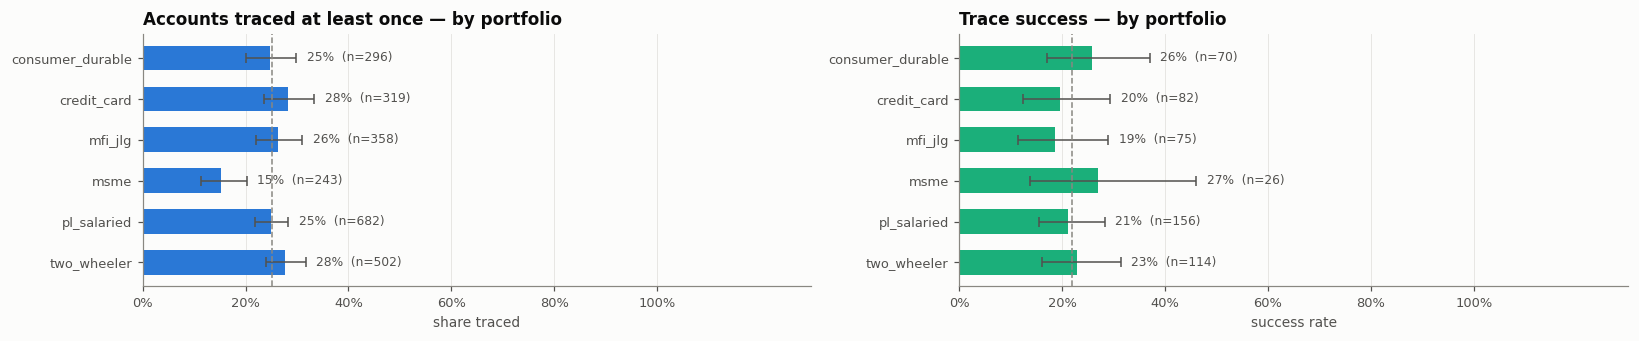

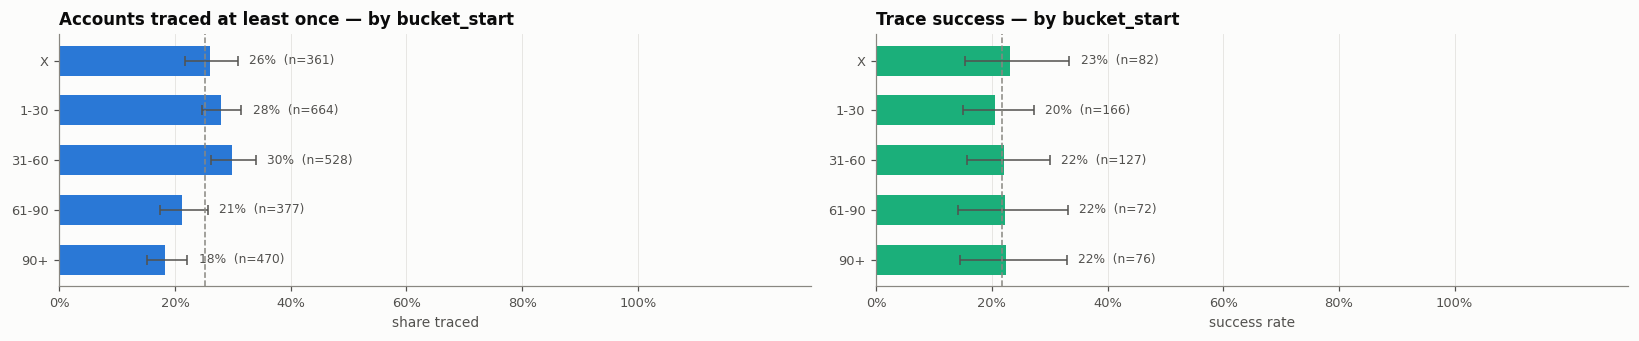

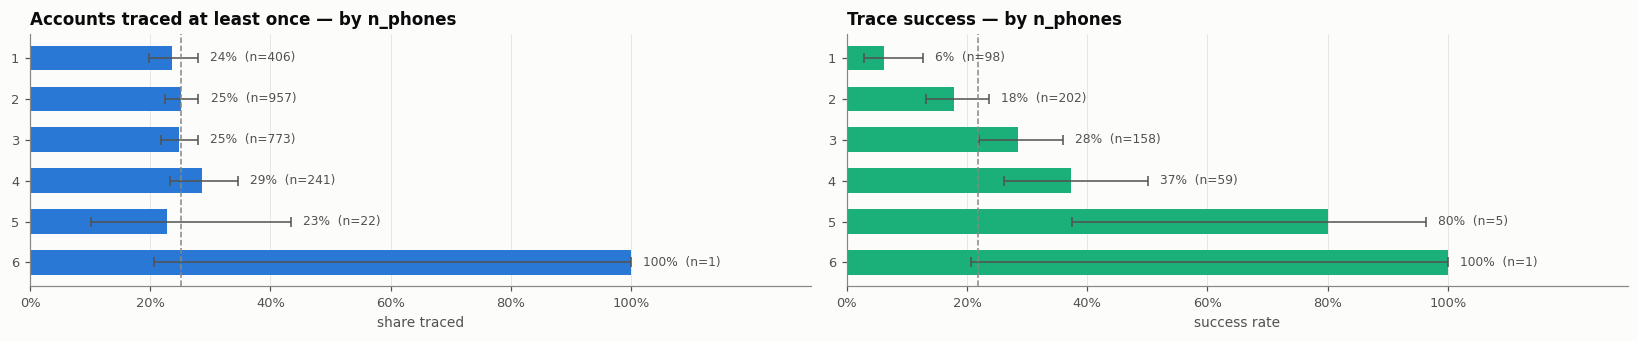

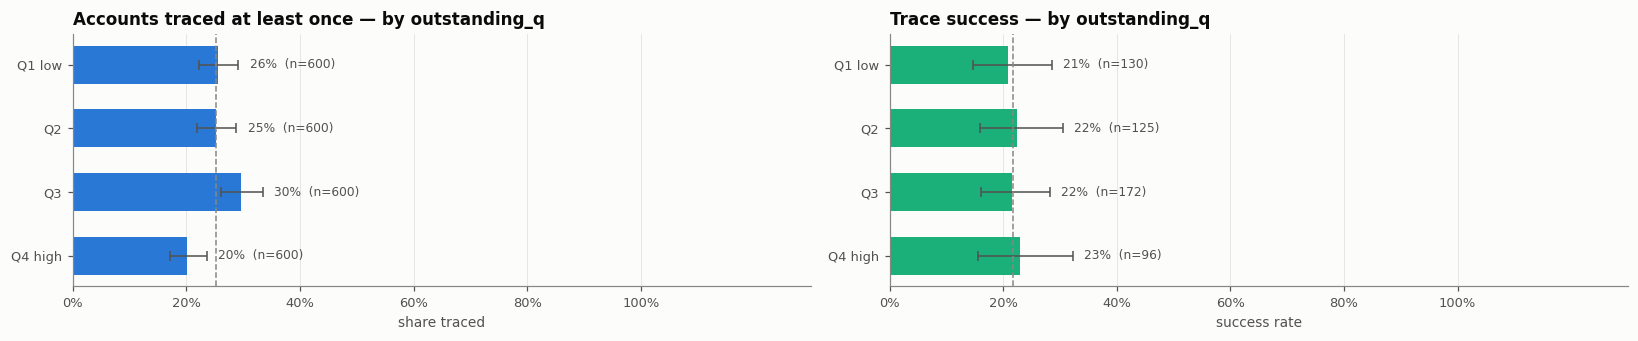

In [ ]:
traced_ids = set(skip.account_id)
acc["traced"] = acc.account_id.isin(traced_ids).astype(int)
acc["outstanding_q"] = pd.qcut(acc.outstanding, 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
s = s.merge(acc[["account_id", "portfolio", "bucket_start", "income_type", "n_phones", "outstanding", "outstanding_q"]], on="account_id", how="left")
overall_s = s.success.mean()

for c, order in [("portfolio", None), ("bucket_start", BUCKET_ORDER), ("n_phones", None), ("outstanding_q", ["Q1 low", "Q2", "Q3", "Q4 high"])]:
    fig, axes = plt.subplots(1, 2, figsize=(15, 3.2))
    plot_rate(rate_table(acc, c, "traced", order), axes[0], f"Accounts traced at least once — by {c}", "share traced", overall=acc.traced.mean())
    plot_rate(rate_table(s, c, "success", order), axes[1], f"Trace success — by {c}", "success rate", overall=overall_s, color=CAT[2])
    plt.tight_layout(); plt.show()

### 7.3 Is a trace worth it? A first look at value of information
A trace costs about ₹100. If a successful trace leads to recovering even a small fraction of the outstanding amount, it pays for itself many times over on big accounts and may not on small ones. The table shows the break-even recovery rate: the share of outstanding you'd need to recover after a successful trace for the trace to pay for itself. Section 10 measures recovery-once-reached from `payments.csv`; combine the two to get expected value.

In [ ]:
ev = s.groupby("outstanding_q", observed=True).agg(traces=("success", "size"), success_rate=("success", "mean"),
                                                    median_outstanding=("outstanding", "median"), mean_cost=("cost_inr", "mean"))
ev["breakeven_recovery_%"] = 100 * ev.mean_cost / (ev.success_rate * ev.median_outstanding)
display(ev)

,traces,success_rate,median_outstanding,mean_cost,breakeven_recovery_%
outstanding_q,,,,,
Q1 low,130,0.208,"39,900.000",102.592,1.238
Q2,125,0.224,"87,750.000",104.376,0.531
Q3,172,0.215,"169,650.000",104.041,0.285
Q4 high,96,0.229,"470,225.000",107.729,0.100


### 7.4 Do numbers found by tracing actually reach the borrower?
Joins traced-in numbers (source `skip_trace`) to the verified sample.

In [ ]:
st_v = v[v.source == "skip_trace"]
p, lo, hi = wilson(st_v.reaches_borrower.sum(), len(st_v))
print(f"Skip-trace numbers in the verified sample: {len(st_v)}  |  reach borrower: {p:.0%} (95% CI {lo:.0%}–{hi:.0%})")
display(st_v.verified_status.value_counts())

Skip-trace numbers in the verified sample: 7  |  reach borrower: 100% (95% CI 65%–100%)


,count
verified_status,
borrower_number,7


## 8. Dial attempts (the main evidence)
Every call to every phone: which number, when, by whom, what the network said (`network_response`), what the agent logged (`disposition`) and a free-text `remark`. This is where the phone's hidden state shows up.

We first group the 16 dispositions into a few **outcome groups**. This mapping is your labelling system, so it's written out explicitly:

| Outcome group | Dispositions | What it suggests about the number |
|---|---|---|
| **RPC** (right-party contact) | `rpc_*` (ptp, call_back, hung_up, refused, hardship, dispute, claims_paid) | valid, reaches the borrower |
| third party | `third_party_contact`, `third_party_ptp` | live number, but someone else's (never discuss the debt) |
| wrong number | `wrong_number` | not the borrower: recycled or wrong from the start |
| rejected | `call_rejected` | live number, someone chose not to answer (**avoiding**) |
| no answer | `no_answer` | rang out: ambiguous |
| not reachable / switched off | `not_reachable`, `switched_off` | temporarily or permanently off |
| invalid | `invalid_number` | number doesn't exist |
| other | `language_barrier` | answered, couldn't communicate |

In [ ]:
OUTCOME_GROUP = {
    **{d: "RPC" for d in ["rpc_ptp", "rpc_call_back", "rpc_hung_up", "rpc_refused", "rpc_hardship", "rpc_dispute", "rpc_claims_paid"]},
    "third_party_contact": "third party", "third_party_ptp": "third party", "wrong_number": "wrong number",
    "call_rejected": "rejected", "no_answer": "no answer", "not_reachable": "not reachable",
    "switched_off": "switched off", "invalid_number": "invalid", "language_barrier": "other",
}
OUT_ORDER = ["RPC", "third party", "wrong number", "rejected", "no answer", "not reachable", "switched off", "invalid", "other"]
unmapped = set(dials.disposition) - set(OUTCOME_GROUP)
assert not unmapped, f"Dispositions without a group: {unmapped}"
dials["outcome"] = dials.disposition.map(OUTCOME_GROUP)
dials["rpc"] = (dials.outcome == "RPC").astype(int)
dials["hour"] = dials.attempt_ts.dt.hour
dials["weekday"] = dials.attempt_ts.dt.day_name().str[:3]
# attach phone attributes (source, relation, slot) to every attempt
dials = dials.merge(phones.drop_duplicates(["phone_id", "account_id"])[["phone_id", "account_id", "source", "relation_recorded", "priority_slot", "is_shared"]],
                    on=["phone_id", "account_id"], how="left")
print(f"{len(dials):,} attempts on {dials.phone_id.nunique():,} numbers across {dials.account_id.nunique():,} accounts")
print(f"Accounts never dialled: {len(accounts) - dials.account_id.nunique()}")

51,105 attempts on 4,008 numbers across 2,368 accounts
Accounts never dialled: 32


### 8.1 Volume, timing and contact-hour compliance
The RBI Fair Practices Code limits calls to 8 am – 7 pm. The first table checks that every attempt falls inside that window, and how often an account is called in a single day.

,metric,value
0,first call time of day,08:00:00
1,last call time of day,18:59:56
2,attempts outside 8am–7pm,0
3,max attempts on one account in one day,2
4,share of attempts by voice bot,7.4%


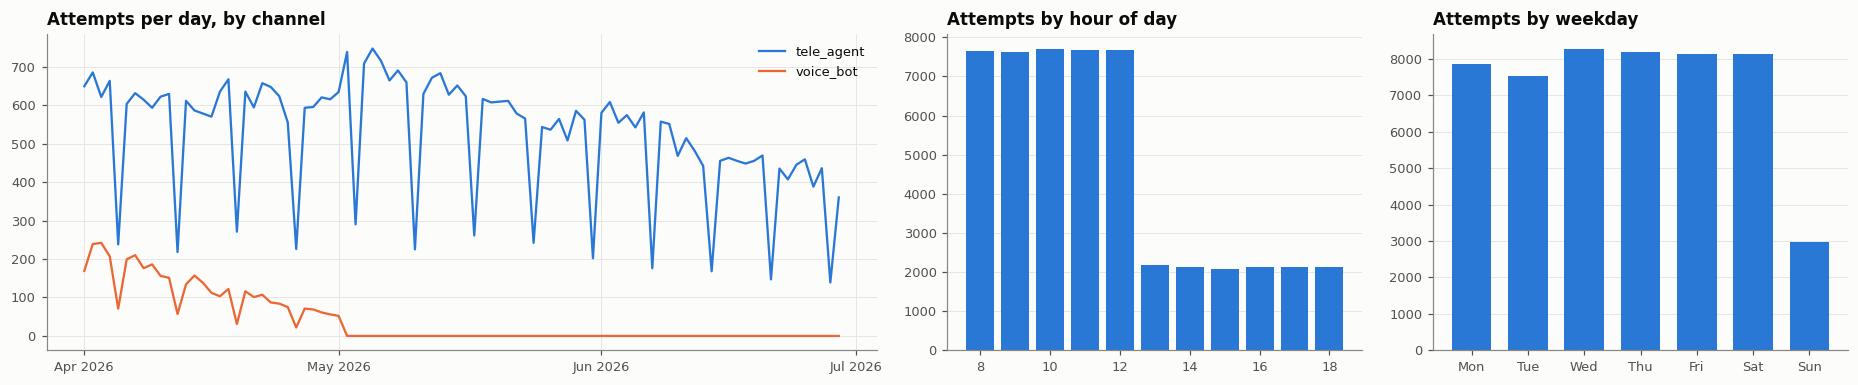

In [ ]:
hours_out = ((dials.hour < 8) | (dials.hour >= 19)).sum()
per_day = dials.groupby(["account_id", dials.attempt_ts.dt.date]).size()
display(pd.DataFrame({
    "metric": ["first call time of day", "last call time of day", "attempts outside 8am–7pm",
               "max attempts on one account in one day", "share of attempts by voice bot"],
    "value": [dials.attempt_ts.dt.time.min(), dials.attempt_ts.dt.time.max(), hours_out, per_day.max(),
              f"{(dials.channel == 'voice_bot').mean():.1%}"]}))

fig, axes = plt.subplots(1, 3, figsize=(17, 3.6), gridspec_kw={"width_ratios": [2, 1, 1]})
daily = dials.groupby([dials.attempt_ts.dt.date, "channel"]).size().unstack(fill_value=0)
for i, c in enumerate(daily.columns):
    axes[0].plot(pd.to_datetime(daily.index), daily[c], color=CAT[i], lw=1.5, label=c)
axes[0].legend(); axes[0].set_title("Attempts per day, by channel")
axes[0].xaxis.set_major_locator(mdates.MonthLocator()); axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
hc = dials.hour.value_counts().sort_index()
axes[1].bar(hc.index, hc.values, color=CAT[0], width=0.8); axes[1].set_title("Attempts by hour of day"); axes[1].grid(axis="x", visible=False)
wd = dials.weekday.value_counts().reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[2].bar(wd.index, wd.values, color=CAT[0], width=0.7); axes[2].set_title("Attempts by weekday"); axes[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 8.2 Which numbers are never dialled?
A number that's never been called has **no evidence** about it. It's censored, not "bad". The model must not treat untested as negative.

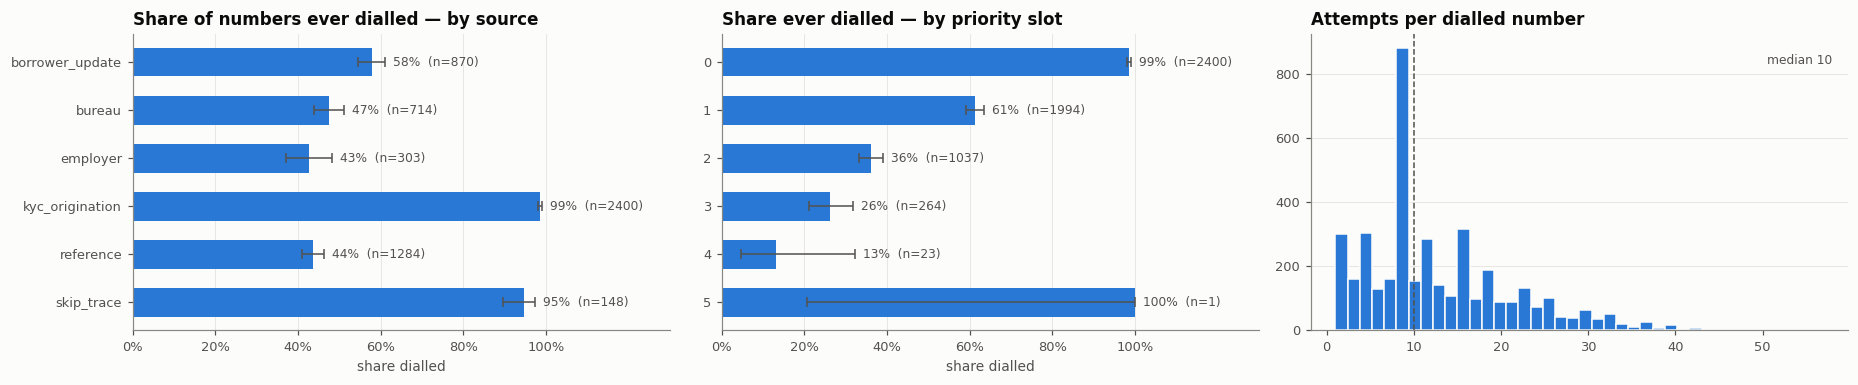

Numbers never dialled: 1,684 of 5,719 (29%)


In [ ]:
dialled = set(zip(dials.phone_id, dials.account_id))
phones["ever_dialled"] = [(p, a) in dialled for p, a in zip(phones.phone_id, phones.account_id)]
att_per_phone = dials.groupby(["phone_id", "account_id"]).size()
phones["n_attempts"] = [att_per_phone.get((p, a), 0) for p, a in zip(phones.phone_id, phones.account_id)]
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
plot_rate(rate_table(phones, "source", "ever_dialled"), axes[0], "Share of numbers ever dialled — by source", "share dialled")
plot_rate(rate_table(phones, "priority_slot", "ever_dialled"), axes[1], "Share ever dialled — by priority slot", "share dialled")
x = phones.loc[phones.n_attempts > 0, "n_attempts"]
axes[2].hist(x, bins=40, color=CAT[0], edgecolor=SURFACE); axes[2].set_title("Attempts per dialled number"); axes[2].grid(axis="x", visible=False)
axes[2].axvline(x.median(), color=INK2, ls="--", lw=1); axes[2].text(0.97, 0.9, f"median {x.median():.0f}", transform=axes[2].transAxes, ha="right", fontsize=8, color=INK2)
plt.tight_layout(); plt.show()
print(f"Numbers never dialled: {(~phones.ever_dialled).sum():,} of {len(phones):,} ({(~phones.ever_dialled).mean():.0%})")

### 8.3 Do network responses and dispositions agree?
The network response is recorded by the telephony system; the disposition is typed by the agent. Each disposition should sit under one network response (e.g. an RPC needs an answered call). Off-pattern cells point to agent mis-logging.

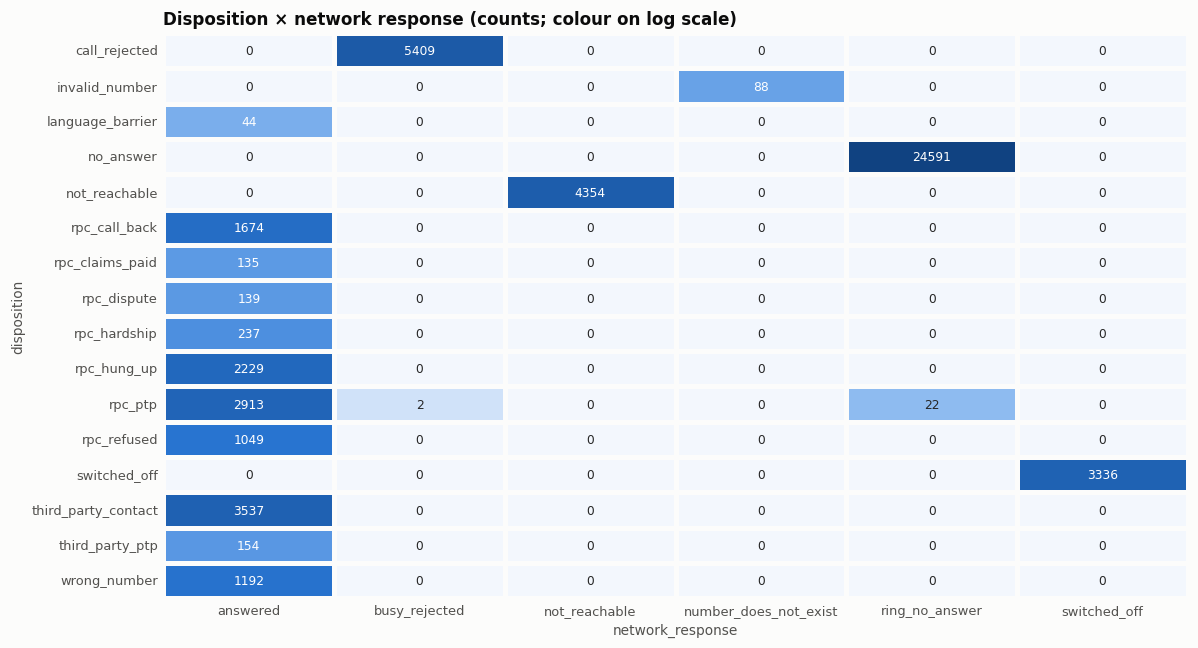

RPC dispositions logged on calls the network says were NOT answered: 24


attempts  median_talk_s  median_ring_s
agent_id disposition network_response                                        
TA013    rpc_ptp     busy_rejected            2          0.000          5.000
                     ring_no_answer          22          0.000         34.000

**Talk and ring time by outcome group** (median seconds)

,ring_duration_s,talk_duration_s
outcome,,
RPC,12.000,110.000
third party,11.000,85.000
wrong number,12.000,28.000
rejected,6.000,0.000
no answer,37.000,0.000
not reachable,0.000,0.000
switched off,0.000,0.000
invalid,0.000,0.000
other,14.000,237.000


In [ ]:
ct = pd.crosstab(dials.disposition, dials.network_response)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(np.log10(ct + 1), annot=ct, fmt="d", cmap=SEQ, linewidths=2, linecolor=SURFACE, cbar=False, ax=ax, annot_kws={"fontsize": 8})
ax.set_title("Disposition × network response (counts; colour on log scale)"); ax.grid(False); ax.tick_params(length=0)
plt.tight_layout(); plt.show()

bad_rpc = dials[(dials.outcome == "RPC") & (dials.network_response != "answered")]
print(f"RPC dispositions logged on calls the network says were NOT answered: {len(bad_rpc)}")
if len(bad_rpc):
    display(bad_rpc.groupby(["agent_id", "disposition", "network_response"]).agg(
        attempts=("attempt_id", "size"), median_talk_s=("talk_duration_s", "median"), median_ring_s=("ring_duration_s", "median")))
display(Markdown("**Talk and ring time by outcome group** (median seconds)"))
display(dials.groupby("outcome")[["ring_duration_s", "talk_duration_s"]].median().reindex(OUT_ORDER))

### 8.4 Outcome mix and RPC rate (train)
How often an attempt reaches the borrower, broken down by the number's attributes and by timing. These are **attempt-level** rates.

Attempts in this view: 35,834  |  RPC rate per attempt: 16.4%  →  164 RPCs per 1,000 dials


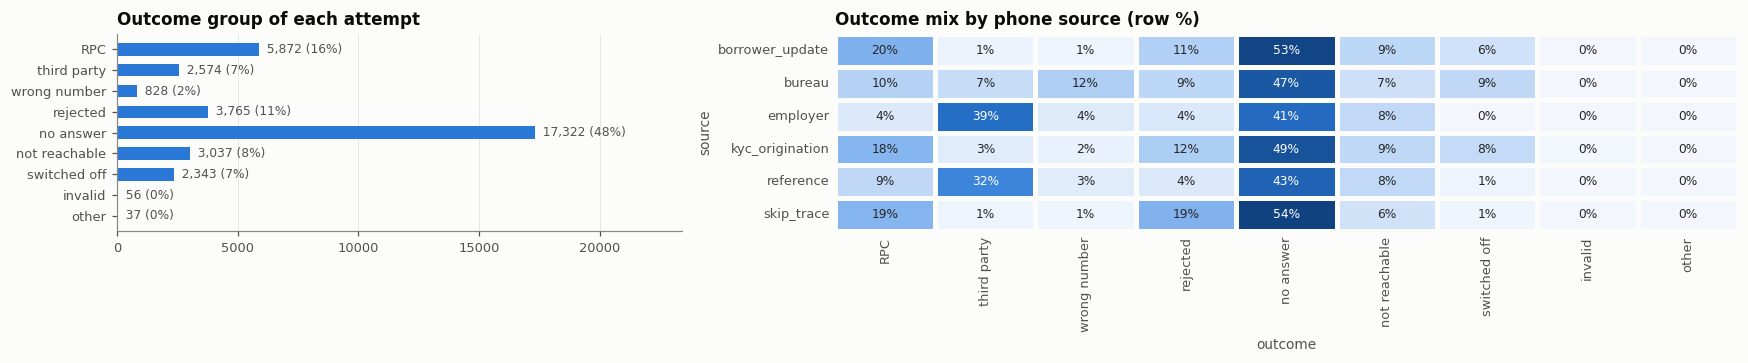

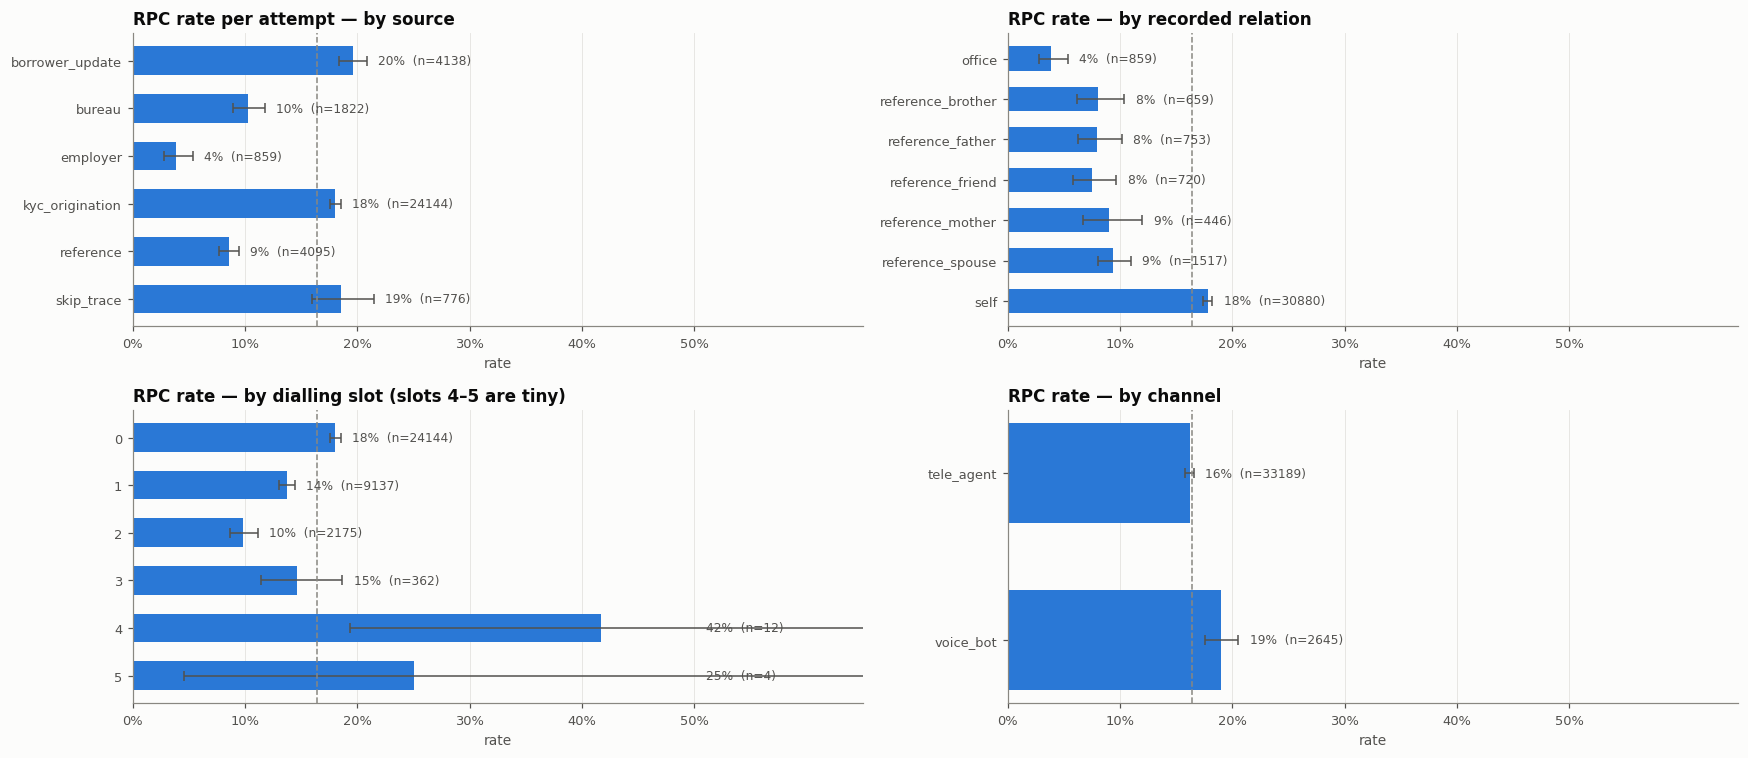

In [ ]:
dv = outcome_view(dials)
overall_rpc = dv.rpc.mean()
print(f"Attempts in this view: {len(dv):,}  |  RPC rate per attempt: {overall_rpc:.1%}  →  {1000*overall_rpc:.0f} RPCs per 1,000 dials")

fig, axes = plt.subplots(1, 2, figsize=(16, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})
count_bar(dv.outcome, axes[0], "Outcome group of each attempt", order=OUT_ORDER)
heat(pd.crosstab(dv.source, dv.outcome, normalize="index")[[o for o in OUT_ORDER if o in dv.outcome.unique()]], axes[1], "Outcome mix by phone source (row %)")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
plot_rate(rate_table(dv, "source", "rpc"), axes[0, 0], "RPC rate per attempt — by source", overall=overall_rpc, xmax=0.5)
plot_rate(rate_table(dv, "relation_recorded", "rpc"), axes[0, 1], "RPC rate — by recorded relation", overall=overall_rpc, xmax=0.5)
plot_rate(rate_table(dv, "priority_slot", "rpc"), axes[1, 0], "RPC rate — by dialling slot (slots 4–5 are tiny)", overall=overall_rpc, xmax=0.5)
plot_rate(rate_table(dv, "channel", "rpc"), axes[1, 1], "RPC rate — by channel", overall=overall_rpc, xmax=0.5)
plt.tight_layout(); plt.show()

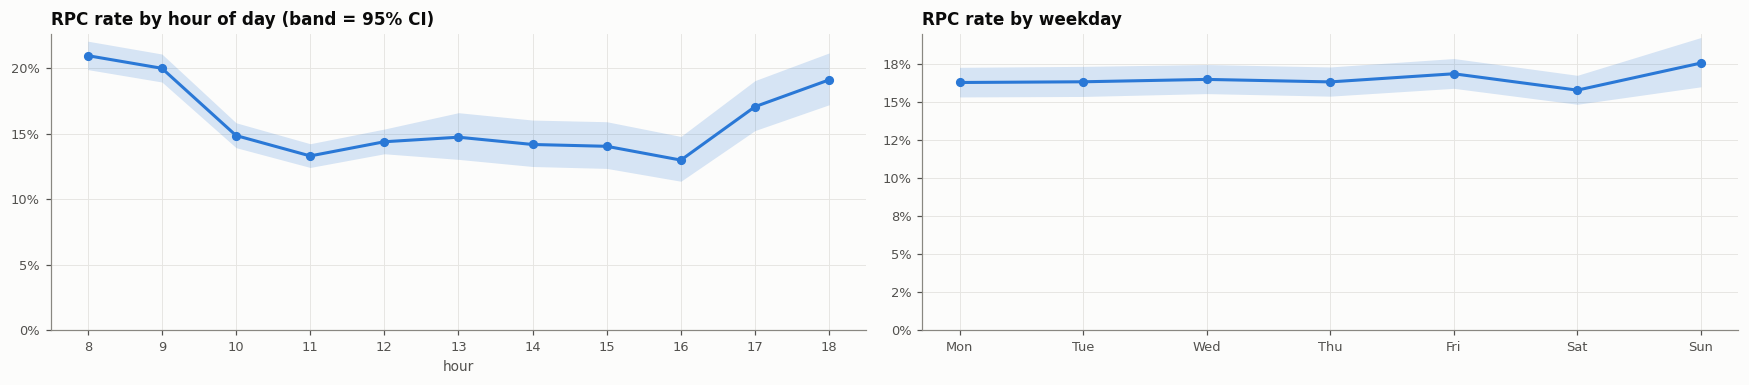

In [ ]:
def rate_line(t, ax, title, xlabel, color=CAT[0]):
    """Rate with a 95% CI band, for an ordered x."""
    x = np.arange(len(t))
    ax.fill_between(x, t.ci_low, t.ci_high, color=color, alpha=0.18, lw=0)
    ax.plot(x, t.rate, color=color, lw=2, marker="o", ms=5)
    ax.set_xticks(x, [str(i) for i in t.index]); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylim(bottom=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 3.6))
rate_line(rate_table(dv, "hour", "rpc"), axes[0], "RPC rate by hour of day (band = 95% CI)", "hour")
rate_line(rate_table(dv, "weekday", "rpc", ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]), axes[1], "RPC rate by weekday", "")
plt.tight_layout(); plt.show()

### 8.5 Dial history vs the verified truth (train)
For each verified number, the share of its past attempts in each outcome group, averaged by its **true** status. If dial history looks different for each true state, it can be used to infer the state of the thousands of numbers that were never verified. This is the bridge between weak dial labels and ground truth.

Verified numbers in view: 173  |  never dialled before verification: 48


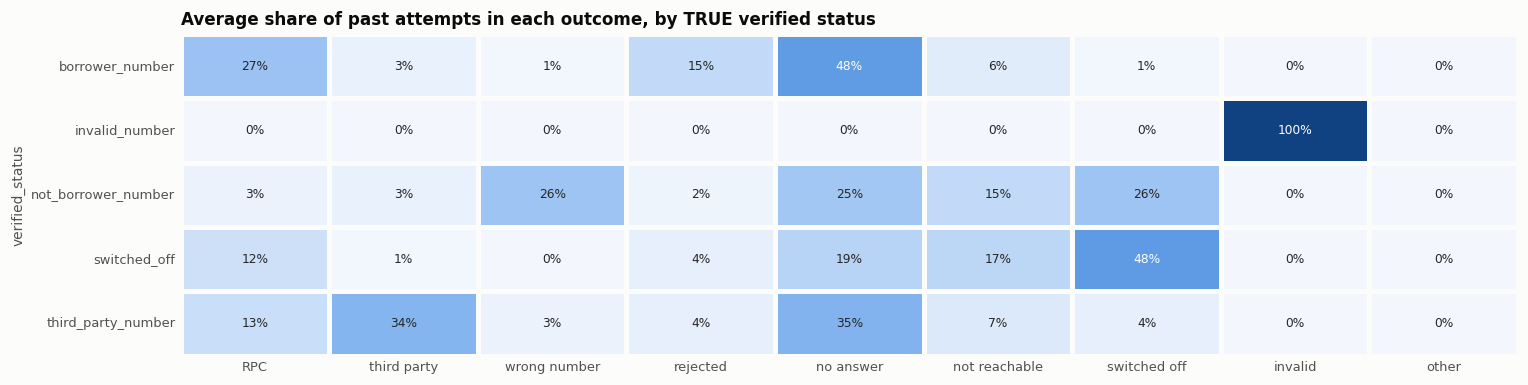

,phones,mean_attempts
verified_status,,
borrower_number,73,14.589
invalid_number,1,2.000
not_borrower_number,13,7.462
switched_off,13,11.231
third_party_number,25,10.400


In [ ]:
hist = pd.crosstab([dials.phone_id, dials.account_id], dials.outcome, normalize="index").reset_index()
hist["n_attempts"] = hist.set_index(["phone_id", "account_id"]).index.map(att_per_phone)
vh = outcome_view(verified).merge(hist, on=["phone_id", "account_id"], how="left")
print(f"Verified numbers in view: {len(vh)}  |  never dialled before verification: {vh.n_attempts.isna().sum()}")
cols = [o for o in OUT_ORDER if o in vh.columns]
prof = vh.dropna(subset=["n_attempts"]).groupby("verified_status")[cols + ["n_attempts"]].mean()
prof.insert(0, "phones", vh.dropna(subset=["n_attempts"]).groupby("verified_status").size())

fig, ax = plt.subplots(figsize=(14, 3.6))
heat(prof[cols], ax, "Average share of past attempts in each outcome, by TRUE verified status")
plt.tight_layout(); plt.show()
display(prof[["phones", "n_attempts"]].rename(columns={"n_attempts": "mean_attempts"}))

### 8.6 Avoiding vs dead: can the two be told apart?
The central PS2 question. For numbers with at least 5 attempts, each dot plots the share of calls **rejected** (someone is there and declining) against the share **switched off / not reachable / invalid** (nobody is there). Verified numbers are coloured by their true status; the rest are grey.

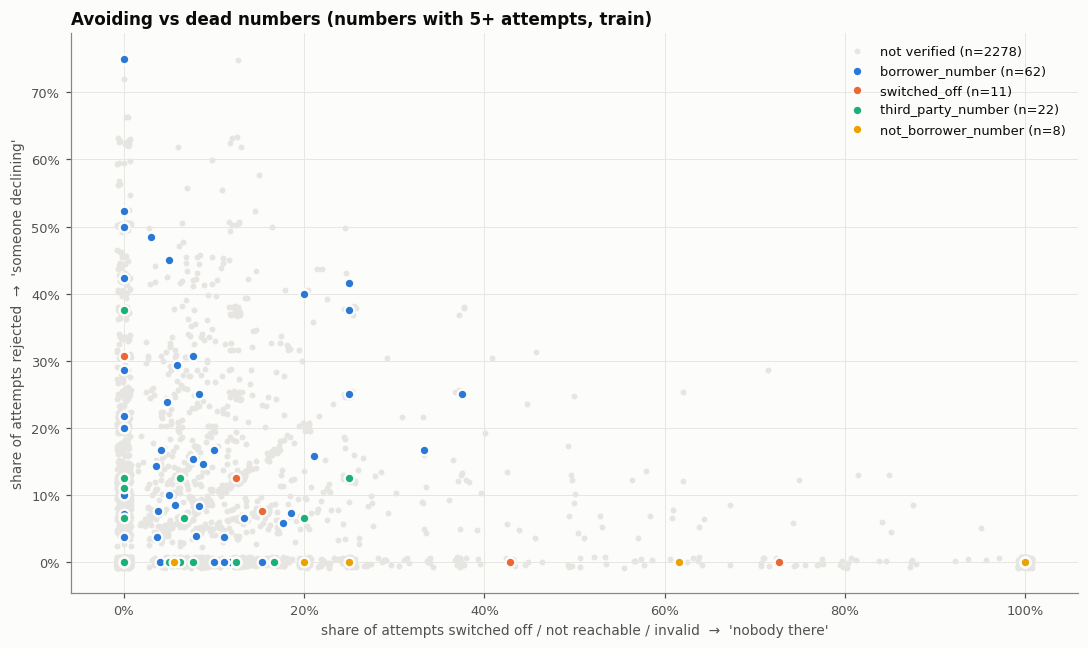

,avoid_signal,dead_signal,wrong number,third party,RPC
verified_status,,,,,
borrower_number,0.100,0.049,0.000,0.000,0.209
not_borrower_number,0.000,0.808,0.000,0.000,0.000
switched_off,0.000,1.000,0.000,0.000,0.000
third_party_number,0.000,0.072,0.000,0.375,0.000


In [ ]:
ph = pd.crosstab([dv.phone_id, dv.account_id], dv.outcome, normalize="index")
for c in OUT_ORDER:
    if c not in ph.columns: ph[c] = 0.0
ph["n"] = dv.groupby(["phone_id", "account_id"]).size()
ph = ph[ph.n >= 5].reset_index()
ph["avoid_signal"] = ph["rejected"]
ph["dead_signal"] = ph["switched off"] + ph["not reachable"] + ph["invalid"]
ph = ph.merge(verified[["phone_id", "account_id", "verified_status"]], on=["phone_id", "account_id"], how="left")

STATUS_COLORS = {"borrower_number": CAT[0], "switched_off": CAT[1], "third_party_number": CAT[2],
                 "not_borrower_number": CAT[3], "invalid_number": CAT[4]}
rng = np.random.default_rng(0)
jit = lambda n: rng.uniform(-0.008, 0.008, n)
fig, ax = plt.subplots(figsize=(10, 6))
g = ph[ph.verified_status.isna()]
ax.scatter(g.dead_signal + jit(len(g)), g.avoid_signal + jit(len(g)), s=8, color=GRID, label=f"not verified (n={len(g)})")
for st, col in STATUS_COLORS.items():
    g = ph[ph.verified_status == st]
    if len(g):
        ax.scatter(g.dead_signal, g.avoid_signal, s=40, color=col, edgecolor=SURFACE, lw=1.5, label=f"{st} (n={len(g)})")
ax.set_xlabel("share of attempts switched off / not reachable / invalid  →  'nobody there'")
ax.set_ylabel("share of attempts rejected  →  'someone declining'")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc="upper right"); ax.set_title("Avoiding vs dead numbers (numbers with 5+ attempts, train)")
plt.tight_layout(); plt.show()
display(ph.dropna(subset=["verified_status"]).groupby("verified_status")[["avoid_signal", "dead_signal", "wrong number", "third party", "RPC"]].median())

### 8.7 Does evidence go stale?
**Left:** chance that the next attempt reaches the borrower, by days since the number's last RPC. **Right:** the same, by how many failures in a row the number has had. Falling curves mean confidence should decay with time and with each failure, which is what a survival / hidden-state model captures.

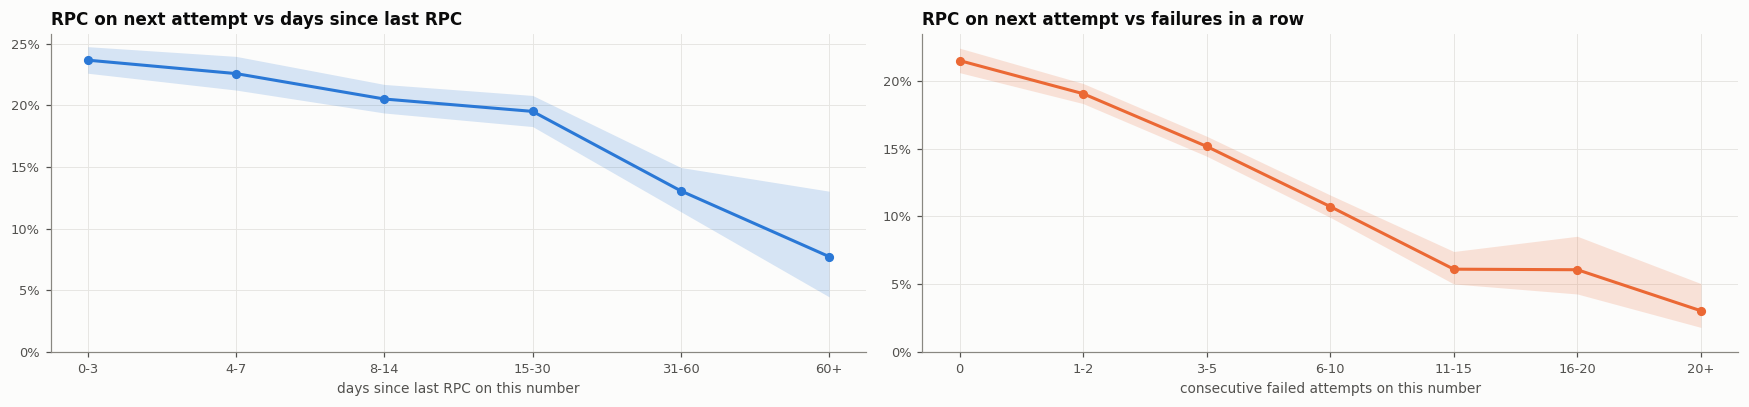

Attempts on numbers that never had an RPC before: 45% (excluded from the left chart)


In [ ]:
dv = dv.sort_values(["phone_id", "account_id", "attempt_ts"]).reset_index(drop=True)
key = [dv.phone_id, dv.account_id]
dv["last_rpc_ts"] = dv.attempt_ts.where(dv.rpc == 1).groupby(key).transform(lambda s: s.ffill().shift())
dv["days_since_rpc"] = (dv.attempt_ts - dv.last_rpc_ts).dt.days
fail = (dv.rpc == 0)
dv["fail_streak"] = fail.groupby(key).transform(lambda s: s.groupby((~s).cumsum()).cumsum().shift().fillna(0))

dv["days_since_bin"] = pd.cut(dv.days_since_rpc, [-1, 3, 7, 14, 30, 60, 1000], labels=["0-3", "4-7", "8-14", "15-30", "31-60", "60+"])
dv["streak_bin"] = pd.cut(dv.fail_streak, [-1, 0, 2, 5, 10, 15, 20, 1000], labels=["0", "1-2", "3-5", "6-10", "11-15", "16-20", "20+"])
fig, axes = plt.subplots(1, 2, figsize=(16, 3.8))
rate_line(rate_table(dv.dropna(subset=["days_since_bin"]), "days_since_bin", "rpc"), axes[0], "RPC on next attempt vs days since last RPC", "days since last RPC on this number")
rate_line(rate_table(dv, "streak_bin", "rpc"), axes[1], "RPC on next attempt vs failures in a row", "consecutive failed attempts on this number", color=CAT[1])
plt.tight_layout(); plt.show()
print(f"Attempts on numbers that never had an RPC before: {dv.last_rpc_ts.isna().mean():.0%} (excluded from the left chart)")

### 8.8 Recycled-number signature
Telecom operators reassign dormant numbers. The tell-tale pattern: a number that **once reached the borrower** later starts returning **wrong number**. Calling it now risks disclosing the debt to a stranger.

In [ ]:
first_rpc = dials[dials.rpc == 1].groupby(["phone_id", "account_id"]).attempt_ts.min().rename("first_rpc")
wr = dials[dials.outcome == "wrong number"].merge(first_rpc, left_on=["phone_id", "account_id"], right_index=True)
wr = wr[wr.attempt_ts > wr.first_rpc]
rec = wr.groupby(["phone_id", "account_id"]).agg(first_wrong=("attempt_ts", "min"), wrong_calls=("attempt_id", "size"),
                                                  first_rpc=("first_rpc", "first"), source=("source", "first")).reset_index()
rec["days_rpc_to_wrong"] = (rec.first_wrong - rec.first_rpc).dt.days
print(f"Numbers with an RPC followed later by 'wrong number': {len(rec)}")
display(rec.groupby("source").agg(numbers=("phone_id", "size"), median_days=("days_rpc_to_wrong", "median"), median_wrong_calls=("wrong_calls", "median")))
only_one = (rec.wrong_calls == 1).mean()
print(f"…of which only ONE wrong-number call: {only_one:.0%} → many may be one-off mis-logs; a repeated pattern is the stronger signal.")
display(Markdown("**Verified status of these numbers** (all splits shown here only as a count check)"))
display(rec.merge(verified, on=["phone_id", "account_id"]).verified_status.value_counts().to_frame("numbers"))

Numbers with an RPC followed later by 'wrong number': 242


,numbers,median_days,median_wrong_calls
source,,,
borrower_update,16,18.500,1.000
bureau,24,11.500,1.000
employer,10,10.500,1.000
kyc_origination,135,20.000,1.000
reference,53,8.000,1.000
skip_trace,4,21.500,1.000


…of which only ONE wrong-number call: 82% → many may be one-off mis-logs; a repeated pattern is the stronger signal.


**Verified status of these numbers** (all splits shown here only as a count check)

,numbers
verified_status,
borrower_number,3
third_party_number,2


### 8.9 What actually triggers a skip-trace?
The rule says "15 consecutive failed contacts". Here we count, for each trace, the run of non-RPC attempts on that account up to the trace day.

,count,mean,std,min,25%,50%,75%,max
failed attempts in a row before trace,766.000,16.855,5.928,1.000,15.000,15.000,16.000,45.000


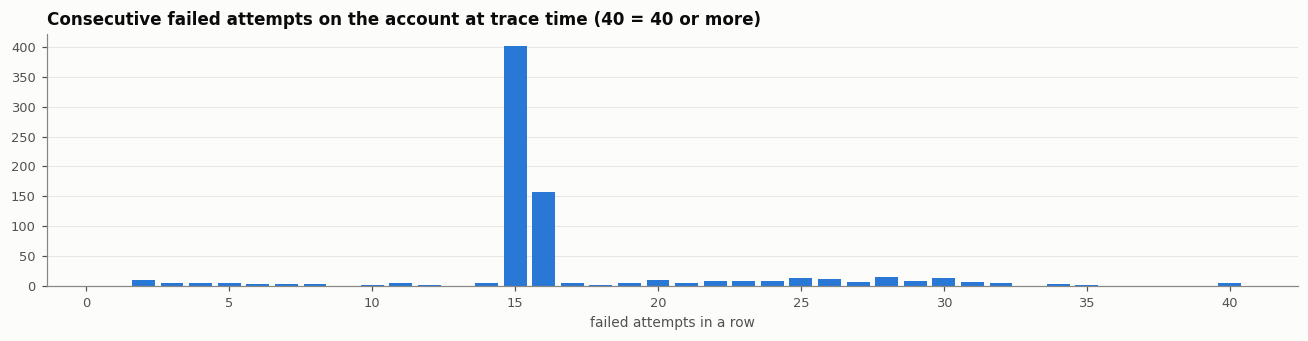

In [ ]:
acc_d = dials.sort_values("attempt_ts")[["account_id", "attempt_ts", "rpc"]]
runs = []
for r in skip.itertuples():
    x = acc_d.loc[(acc_d.account_id == r.account_id) & (acc_d.attempt_ts < r.trace_date + pd.Timedelta(days=1)), "rpc"].values[::-1]
    hit = np.flatnonzero(x == 1)
    runs.append(hit[0] if len(hit) else len(x))
skip["failed_run_before_trace"] = runs
display(skip.failed_run_before_trace.describe().to_frame("failed attempts in a row before trace").T)
vc = skip.failed_run_before_trace.clip(upper=40).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.bar(vc.index, vc.values, color=CAT[0], width=0.8); ax.set_title("Consecutive failed attempts on the account at trace time (40 = 40 or more)")
ax.set_xlabel("failed attempts in a row"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 8.10 Agent remarks
Free text, mostly Hinglish and Kanglish. The most common remark in each outcome group shows the vocabulary; some remarks carry extra detail (who answered, how long a phone has been off) that a text model can pick up.

In [ ]:
rows = []
for g in OUT_ORDER:
    vc = dials.loc[dials.outcome == g, "remark"].value_counts().head(4)
    for rmk, n in vc.items():
        rows.append({"outcome": g, "remark": rmk, "count": n})
display(pd.DataFrame(rows).set_index(["outcome", "remark"]))

KEYWORDS = {"mentions duration (mahine/month)": r"mahine|month|tingal",
            "relative answered (wife/father/bhai/...)": r"wife|father|bhai|mother|beta|hendathi|appa|amma|brother|son",
            "office / employer answered": r"office|leave",
            "phone off / band": r"band hai|switch|off",
            "call cut / hung up": r"cut|kaat|disconnect|hung"}
kw = pd.DataFrame({k: dials.remark.str.contains(p, case=False, regex=True) for k, p in KEYWORDS.items()})
display(Markdown("**Remark keywords by outcome group** (share of attempts whose remark matches)"))
display((kw.groupby(dials.outcome).mean().reindex(OUT_ORDER) * 100).round(1))

count
outcome       remark                                           
RPC           maatu madhyadalli call cut                    510
              beech mein phone kaat diya                    487
              baat karte karte call kaat diya               469
              hung up mid call                              384
third party   wife ne uthaya, bola bahar gaye hain          340
              father ne uthaya, message de denge            336
              office se bola leave pe hai                   333
              phone uthaya bhai ne                          317
wrong number  galat number bola                             137
              customer ko nahi jaanta                       133
              bola mera naya number hai, kisi aur ka tha    128
              hosa number antharu, customer gottilla        102
rejected      busy bataya                                   809
              2 ring ke baad disconnect                     767
              call cut kar diya                             766
              call cut maadidru                             647
no answer     RNR                                          6564
              ringing no response                          4532
              ring ho raha hai, koi pick nahi kar raha     2653
              ring hua, uthaya nahi                        2650
not reachable not reachable                                1476
              out of coverage                              1055
              network nahi hai                              641
              network illa                                  466
switched off  phone off                                     436
              number switch off aa raha hai                 366
              number band hai 2 mahine se                   350
              phone band hai                                334
invalid       invalid number                                 32
              does not exist message aaya                    16
              bot: number does not exist                      9
              bot: invalid number                             9
other         language problem, local language speaker       18
              language barrier                               11
              bhasha samajh nahi aayi                        10
              language problem, local languag espeaker        1

**Remark keywords by outcome group** (share of attempts whose remark matches)

,mentions duration (mahine/month),relative answered (wife/father/bhai/...),office / employer answered,phone off / band,call cut / hung up
outcome,,,,,
RPC,0.000,0.000,0.000,0.000,26.200
third party,0.000,61.900,26.100,26.100,0.000
wrong number,0.000,0.000,0.000,0.000,0.000
rejected,0.000,0.100,0.000,0.000,55.800
no answer,0.000,0.200,0.000,0.000,0.000
not reachable,0.000,0.000,0.000,0.000,0.000
switched off,19.200,0.000,0.000,98.500,0.000
invalid,0.000,0.000,0.000,0.000,0.000
other,0.000,0.000,0.000,0.000,0.000


### 8.11 The random arm and selection propensity
For accounts in the random arm, the number to dial was picked at random, and `selection_propensity` records the probability of the choice made. Rule-based attempts have propensity 1 (deterministic). Weighting random-arm attempts by **1 / propensity** gives an unbiased estimate of what would happen if every number were dialled equally, which is how you evaluate a new policy fairly (inverse propensity weighting).

,count,mean,std,min,25%,50%,75%,max
dialling_arm,,,,,,,,
random_contact_point,"2,766.000",0.569,0.271,0.250,0.333,0.500,1.000,1.000
rule_based,"48,339.000",1.000,0.000,1.000,1.000,1.000,1.000,1.000


,attempts,RPC rate (raw),RPC rate (IPW),share dialling slot 0
rule_based,33903,0.165,NaN,0.683
random_contact_point,1931,0.140,0.120,0.505


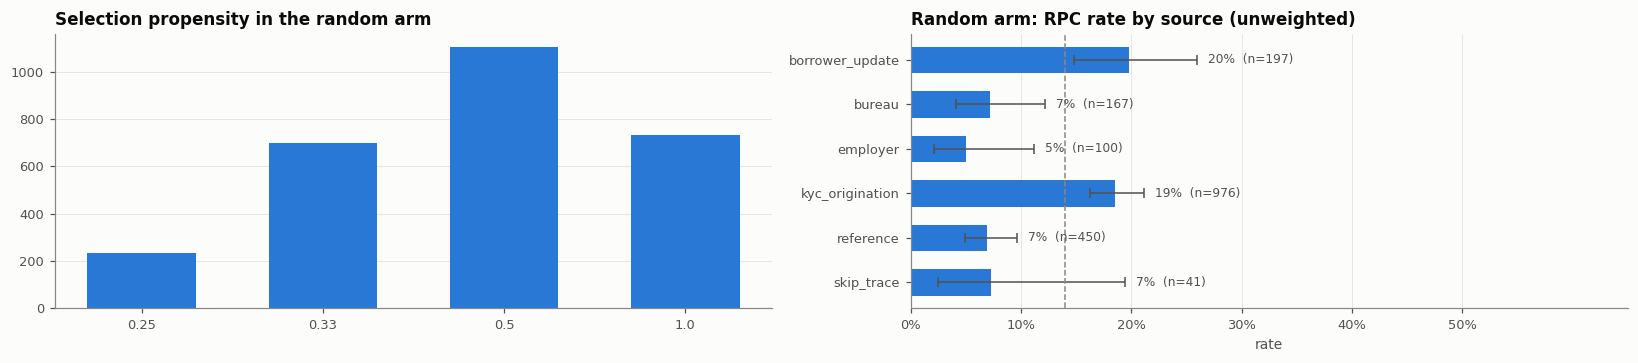

In [ ]:
display(dials.groupby("dialling_arm").selection_propensity.describe())
ra = dv[dv.dialling_arm == "random_contact_point"].copy()
ra["w"] = 1 / ra.selection_propensity
cmp_ = pd.DataFrame({
    "attempts": [len(dv[dv.dialling_arm == "rule_based"]), len(ra)],
    "RPC rate (raw)": [dv[dv.dialling_arm == "rule_based"].rpc.mean(), ra.rpc.mean()],
    "RPC rate (IPW)": [np.nan, np.average(ra.rpc, weights=ra.w) if len(ra) else np.nan],
    "share dialling slot 0": [(dv[dv.dialling_arm == "rule_based"].priority_slot == 0).mean(), (ra.priority_slot == 0).mean()],
}, index=["rule_based", "random_contact_point"])
display(cmp_)
fig, axes = plt.subplots(1, 2, figsize=(15, 3.4))
vc = dials.loc[dials.dialling_arm == "random_contact_point", "selection_propensity"].round(2).value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=CAT[0], width=0.6); axes[0].set_title("Selection propensity in the random arm"); axes[0].grid(axis="x", visible=False)
if len(ra):
    plot_rate(rate_table(ra, "source", "rpc"), axes[1], "Random arm: RPC rate by source (unweighted)", overall=ra.rpc.mean(), xmax=0.5)
plt.tight_layout(); plt.show()

## 9. Agents
Who makes the calls and visits, and whether any agent's logging looks unreliable. Agent quality matters because dispositions are our labels: an agent who mis-logs adds label noise.

,agent_id,channel,language_team,town_id,tenure_months,shift
0,TA001,tele,hinglish,NaN,23.000,day
1,TA002,tele,hinglish,NaN,54.000,day
2,TA003,tele,kanglish,NaN,18.000,day
3,TA004,tele,kanglish,NaN,27.000,day
4,TA005,tele,hinglish,NaN,34.000,day
5,TA006,tele,hinglish,NaN,59.000,day
6,TA007,tele,english,NaN,38.000,day
7,TA008,tele,hinglish,NaN,26.000,day
8,TA009,tele,kanglish,NaN,53.000,day
9,TA010,tele,kanglish,NaN,14.000,day


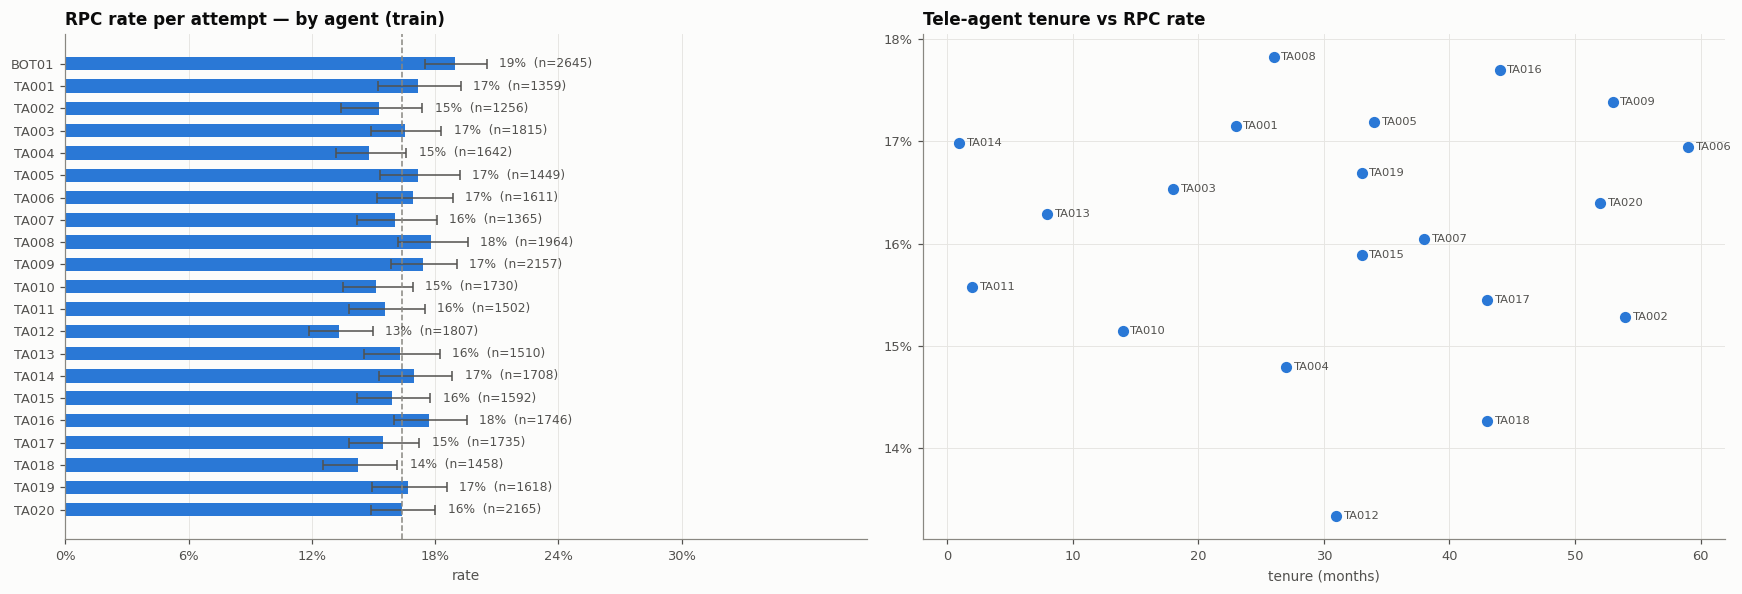

Tenure vs RPC rate: Spearman ρ = 0.07 (p = 0.77)


**Does speaking the borrower's language matter?**

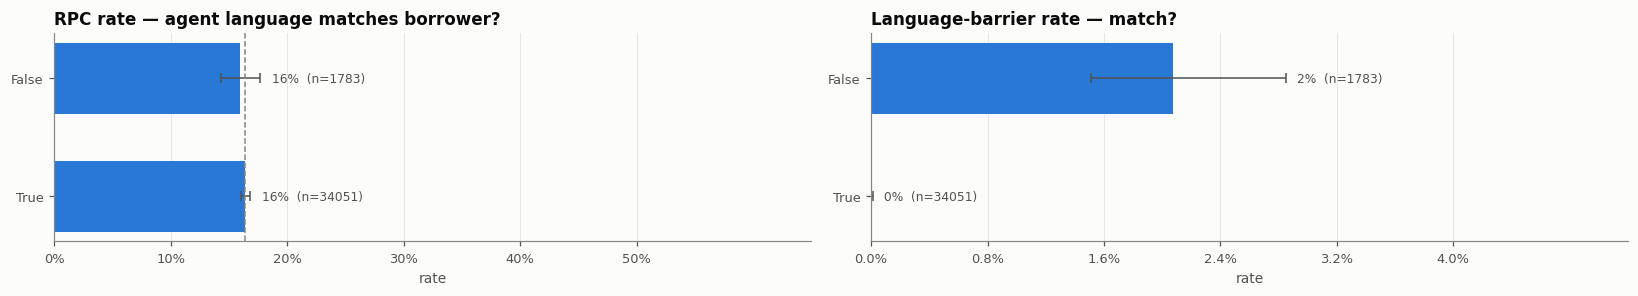

In [ ]:
display(agents)
acc_lang = accounts.set_index("account_id").preferred_language
dv = dv.merge(agents[["agent_id", "language_team", "tenure_months"]], on="agent_id", how="left")
dv["language_match"] = (dv.language_team == "all") | (dv.language_team == dv.account_id.map(acc_lang))
dv["third_party"] = (dv.outcome == "third party").astype(int)
dv["lang_barrier"] = (dv.disposition == "language_barrier").astype(int)

ag = dv.groupby("agent_id").agg(attempts=("attempt_id", "size"), rpc_rate=("rpc", "mean"), third_party_rate=("third_party", "mean"),
                                language_match=("language_match", "mean"), tenure=("tenure_months", "first"),
                                median_talk_rpc=("talk_duration_s", lambda s: s[dv.loc[s.index, "rpc"] == 1].median()))
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
plot_rate(rate_table(dv, "agent_id", "rpc"), axes[0], "RPC rate per attempt — by agent (train)", overall=overall_rpc, xmax=0.3)
ta = ag.dropna(subset=["tenure"])
axes[1].scatter(ta.tenure, ta.rpc_rate, s=40, color=CAT[0])
for a, r in ta.iterrows(): axes[1].text(r.tenure + 0.6, r.rpc_rate, a, fontsize=7.5, color=INK2, va="center")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); axes[1].set_xlabel("tenure (months)"); axes[1].set_title("Tele-agent tenure vs RPC rate")
plt.tight_layout(); plt.show()
rho, pv = stats.spearmanr(ta.tenure, ta.rpc_rate)
print(f"Tenure vs RPC rate: Spearman ρ = {rho:.2f} (p = {pv:.2f})")

display(Markdown("**Does speaking the borrower's language matter?**"))
fig, axes = plt.subplots(1, 2, figsize=(15, 2.8))
plot_rate(rate_table(dv, "language_match", "rpc"), axes[0], "RPC rate — agent language matches borrower?", overall=overall_rpc, xmax=0.5)
plot_rate(rate_table(dv, "language_match", "lang_barrier"), axes[1], "Language-barrier rate — match?", "rate", xmax=0.04)
plt.tight_layout(); plt.show()

### 9.1 Integrity: are logged promises real?
A promise-to-pay (PTP) counts as **kept** here if the account makes any payment within 10 days after the call. Agents whose PTPs are kept far less often than peers, or who log PTPs on calls nobody answered, are candidates for integrity review (PS1 overlaps here).

PTPs logged (train): 2,042  |  kept within 10 days: 37% (95% CI 35%–39%)


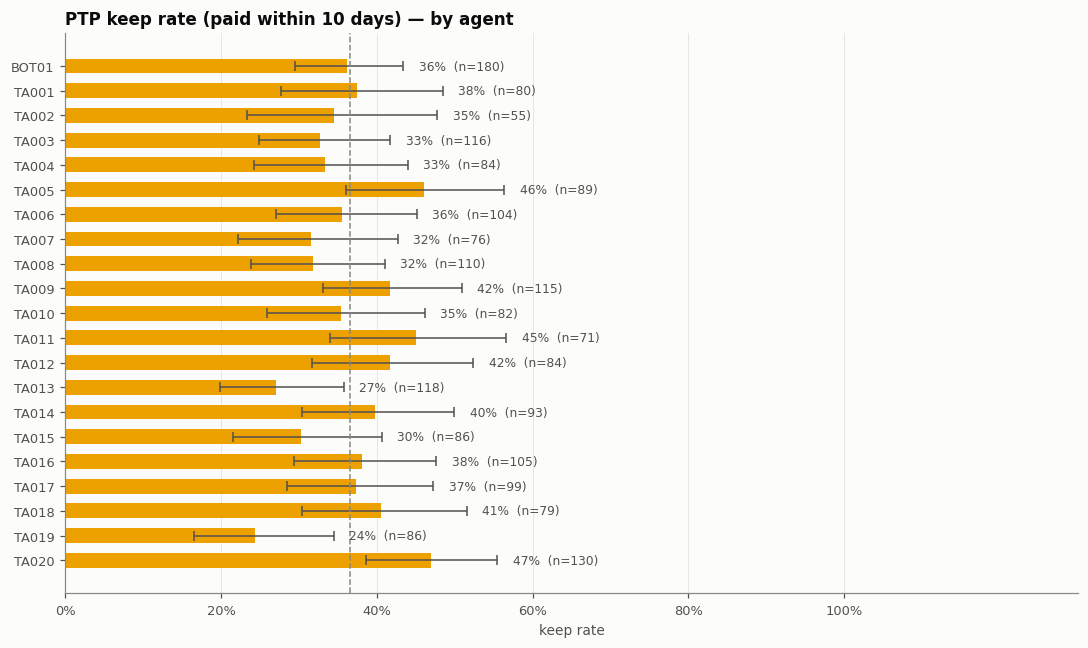

,ptps,keep_rate,ptps_on_unanswered_calls
agent_id,,,
TA019,86,0.244,0
TA013,118,0.271,19
TA015,86,0.302,0
TA007,76,0.316,0
TA008,110,0.318,0


In [ ]:
ptp = outcome_view(dials)[outcome_view(dials).disposition == "rpc_ptp"][["attempt_id", "account_id", "attempt_ts", "agent_id", "network_response", "talk_duration_s"]]
m = ptp.merge(payments[["account_id", "payment_ts"]], on="account_id", how="left")
m["kept"] = ((m.payment_ts - m.attempt_ts).dt.total_seconds().between(0, 10 * 86400)).astype(int)
ptp_k = m.groupby("attempt_id").agg(kept=("kept", "max"), agent_id=("agent_id", "first"),
                                     answered=("network_response", lambda s: s.iloc[0] == "answered")).reset_index()
p, lo, hi = wilson(ptp_k.kept.sum(), len(ptp_k))
print(f"PTPs logged (train): {len(ptp_k):,}  |  kept within 10 days: {p:.0%} (95% CI {lo:.0%}–{hi:.0%})")
integ = ptp_k.groupby("agent_id").agg(ptps=("kept", "size"), keep_rate=("kept", "mean"),
                                      ptps_on_unanswered_calls=("answered", lambda s: (~s).sum()))
fig, ax = plt.subplots(figsize=(10, 6))
plot_rate(rate_table(ptp_k, "agent_id", "kept"), ax, "PTP keep rate (paid within 10 days) — by agent", "keep rate", overall=p, color=CAT[3])
plt.tight_layout(); plt.show()
display(integ.sort_values("keep_rate").head(5))

## 10. Payments
What a contact is worth. Payments tell us (a) how much is recovered once a borrower is reached, which feeds the skip-trace value calculation, and (b) which borrowers pay **without** ever being reached, a sign of a valid but avoiding borrower rather than a dead number.

Payments in view: 1,512  |  accounts paying: 1,155 of 1,680 (69%)  |  total ₹18,904,550


,count,median,mean,sum
channel,,,,
upi_link,526,"4,600.000","11,908.080","6,263,650.000"
upi_app,296,"4,300.000","12,774.324","3,781,200.000"
nach_represent,279,"4,800.000","10,268.638","2,864,950.000"
branch_cash,143,"4,350.000","11,024.476","1,576,500.000"
neft,105,"4,800.000","11,061.429","1,161,450.000"
cash_field,83,"11,200.000","27,427.711","2,276,500.000"
bbps,80,"5,250.000","12,253.750","980,300.000"


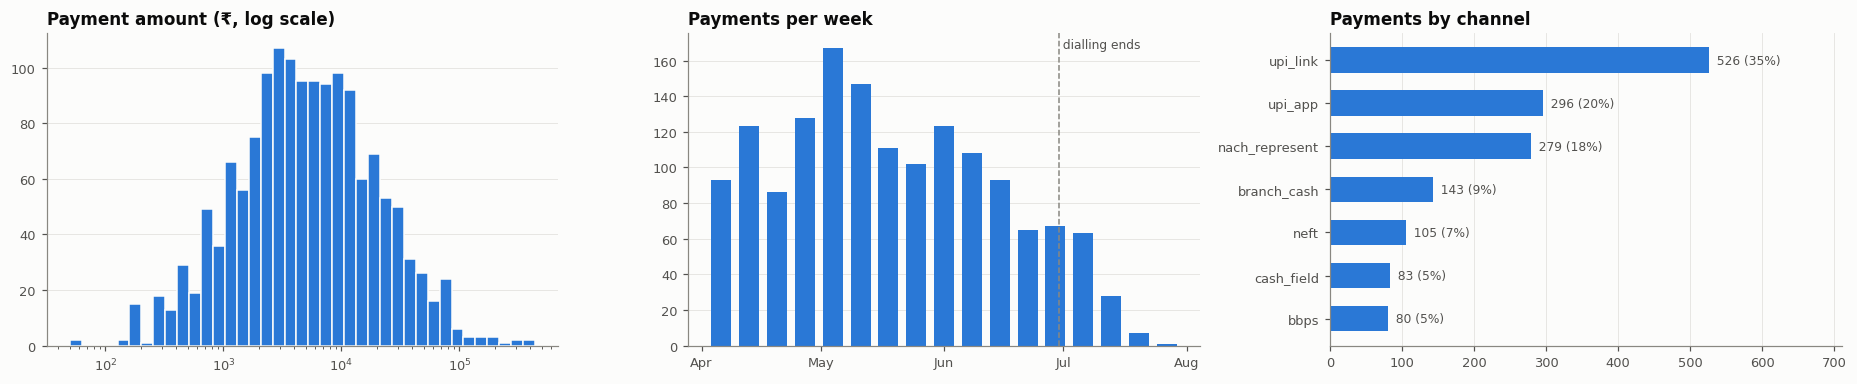

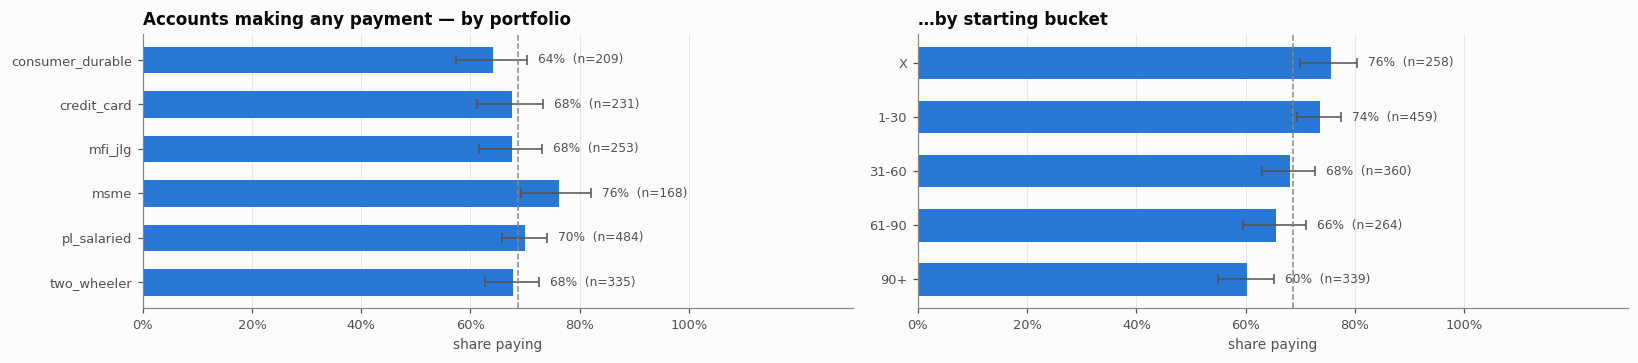

In [ ]:
pv_ = outcome_view(payments)
print(f"Payments in view: {len(pv_):,}  |  accounts paying: {pv_.account_id.nunique():,} of {outcome_view(accounts).shape[0]:,} "
      f"({pv_.account_id.nunique() / outcome_view(accounts).shape[0]:.0%})  |  total ₹{pv_.amount.sum():,.0f}")
display(pv_.groupby("channel").amount.agg(["count", "median", "mean", "sum"]).sort_values("count", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
x = pv_.amount
axes[0].hist(x, bins=np.logspace(np.log10(x.min()), np.log10(x.max()), 40), color=CAT[0], edgecolor=SURFACE)
axes[0].set_xscale("log"); axes[0].set_title("Payment amount (₹, log scale)"); axes[0].grid(axis="x", visible=False)
wk = pv_.set_index("payment_ts").resample("W-MON").amount.agg(["count", "sum"])
axes[1].bar(wk.index, wk["count"], width=5, color=CAT[0]); axes[1].set_title("Payments per week"); axes[1].grid(axis="x", visible=False)
axes[1].xaxis.set_major_locator(mdates.MonthLocator()); axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[1].axvline(dials.attempt_ts.max(), color=MUTED, ls="--", lw=1); axes[1].text(dials.attempt_ts.max(), wk["count"].max(), " dialling ends", fontsize=8, color=INK2)
count_bar(pv_.channel, axes[2], "Payments by channel")
plt.tight_layout(); plt.show()

A_ = outcome_view(accounts).copy()
A_["paid_any"] = A_.account_id.isin(pv_.account_id).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(15, 3.4))
plot_rate(rate_table(A_, "portfolio", "paid_any"), axes[0], "Accounts making any payment — by portfolio", "share paying", overall=A_.paid_any.mean())
plot_rate(rate_table(A_, "bucket_start", "paid_any", BUCKET_ORDER), axes[1], "…by starting bucket", "share paying", overall=A_.paid_any.mean())
plt.tight_layout(); plt.show()

### 10.1 Contact and payment together
Four kinds of account: reached and paid, reached and didn't pay, **paid without ever being reached** (borrower alive and able, just not answering), and neither. Then: once a borrower is reached, how much is recovered in the next 30 days? That's the "value of finding the borrower" a skip-trace decision needs.

portfolio,consumer_durable,credit_card,mfi_jlg,msme,pl_salaried,two_wheeler,All
group,,,,,,,
neither,12,15,12,4,23,21,87
"paid, never reached",18,13,14,15,35,25,120
reached & paid,116,143,157,113,304,202,1035
"reached, not paid",63,60,70,36,122,87,438
All,209,231,253,168,484,335,1680


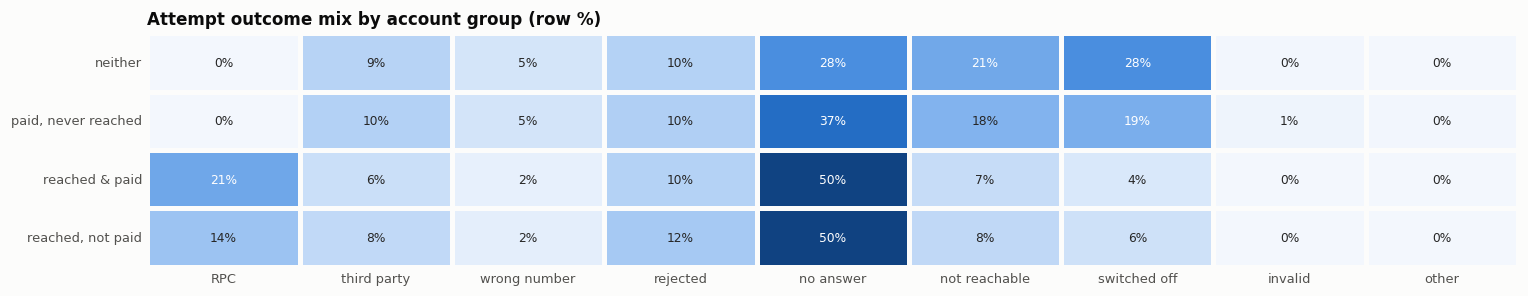

**Recovery within 30 days of first RPC, by portfolio** (reached accounts only)

,accounts,paid_any_30d,median_paid,mean_recovery_vs_overdue,mean_recovery_vs_outstanding
portfolio,,,,,
consumer_durable,179,0.385,0.000,0.288,0.029
credit_card,203,0.414,0.000,0.318,0.034
mfi_jlg,227,0.419,0.000,0.302,0.030
msme,149,0.503,"3,600.000",0.386,0.029
pl_salaried,426,0.390,0.000,0.301,0.030
two_wheeler,289,0.394,0.000,0.295,0.030


In [ ]:
dv_acc = outcome_view(dials)
first_rpc_acc = dv_acc[dv_acc.rpc == 1].groupby("account_id").attempt_ts.min()
A_["reached"] = A_.account_id.isin(first_rpc_acc.index).astype(int)
A_["group"] = np.select([(A_.reached == 1) & (A_.paid_any == 1), (A_.reached == 1) & (A_.paid_any == 0),
                         (A_.reached == 0) & (A_.paid_any == 1)],
                        ["reached & paid", "reached, not paid", "paid, never reached"], "neither")
display(pd.crosstab(A_.group, A_.portfolio, margins=True))

# Do 'paid, never reached' accounts look like avoiders on the phone? Compare their attempt mix.
mix = pd.crosstab(dv_acc.account_id.map(A_.set_index("account_id").group), dv_acc.outcome, normalize="index")[[o for o in OUT_ORDER if o in dv_acc.outcome.unique()]]
fig, ax = plt.subplots(figsize=(14, 2.8))
heat(mix, ax, "Attempt outcome mix by account group (row %)"); ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout(); plt.show()

# Recovery in 30 days after first RPC
pm = pv_.merge(first_rpc_acc.rename("first_rpc"), left_on="account_id", right_index=True)
pm = pm[(pm.payment_ts >= pm.first_rpc) & (pm.payment_ts <= pm.first_rpc + pd.Timedelta(days=30))]
rec30 = pm.groupby("account_id").amount.sum()
R = A_[A_.reached == 1].set_index("account_id")
R["paid_30d"] = rec30.reindex(R.index).fillna(0)
R["recovery_vs_overdue"] = (R.paid_30d / R.overdue_start).clip(upper=1.5)
R["recovery_vs_outstanding"] = R.paid_30d / R.outstanding
display(Markdown("**Recovery within 30 days of first RPC, by portfolio** (reached accounts only)"))
display(R.groupby("portfolio").agg(accounts=("paid_30d", "size"), paid_any_30d=("paid_30d", lambda s: (s > 0).mean()),
                                   median_paid=("paid_30d", "median"), mean_recovery_vs_overdue=("recovery_vs_overdue", "mean"),
                                   mean_recovery_vs_outstanding=("recovery_vs_outstanding", "mean")))

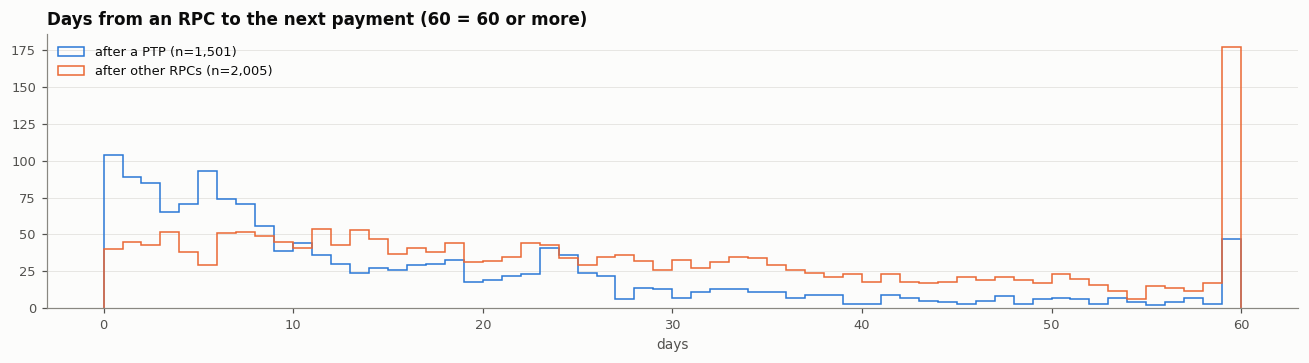

In [ ]:
# Time from a PTP / any RPC to the next payment
nxt = dv_acc[dv_acc.rpc == 1][["account_id", "attempt_ts", "disposition"]].merge(pv_[["account_id", "payment_ts"]], on="account_id")
nxt["days"] = (nxt.payment_ts - nxt.attempt_ts).dt.total_seconds() / 86400
nxt = nxt[nxt.days >= 0].sort_values("days").drop_duplicates(["account_id", "attempt_ts"])
fig, ax = plt.subplots(figsize=(12, 3.4))
for i, (lab, sub) in enumerate([("after a PTP", nxt[nxt.disposition == "rpc_ptp"]), ("after other RPCs", nxt[nxt.disposition != "rpc_ptp"])]):
    ax.hist(sub.days.clip(upper=60), bins=60, range=(0, 60), color=CAT[i], histtype="step", lw=2, label=f"{lab} (n={len(sub):,})")
ax.legend(); ax.set_title("Days from an RPC to the next payment (60 = 60 or more)"); ax.set_xlabel("days"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 11. Addresses and field visits (phase 2)
Addresses are the second kind of contact point. Field visits are expensive, sparse evidence about them: a few visits a month instead of many calls a day.
### 11.1 Addresses

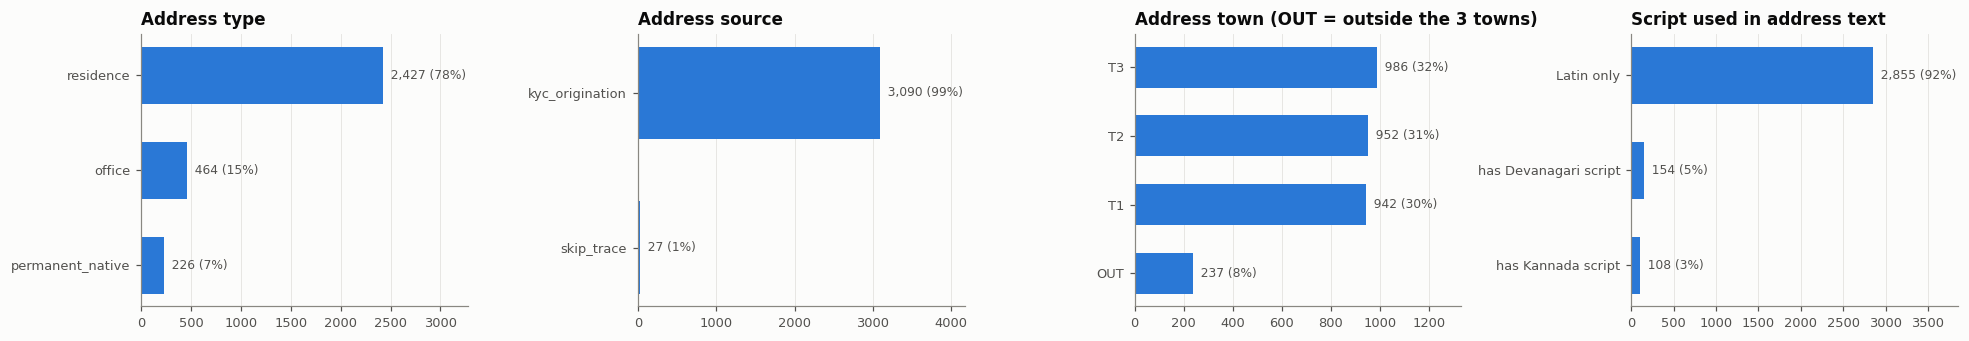

town_id,OUT,T1,T2,T3
address_type,,,,
office,0,146,160,158
permanent_native,226,0,0,0
residence,11,796,792,828


**Address text style by lender format**

,addresses,upper_case,median_length
kyc_address_format,,,
app_free_text,1381,0.000,66.000
kyc_mixed,1077,0.000,68.000
kyc_upper,659,0.901,68.000


**A few raw examples per type**

,address_id,address_type,town_id,address_text
0,AD000001,residence,T1,"6th Cross, 5th Main, ಚರ್ಚ್ ಹತ್ತಿರ, Kuvempu Lay..."
1,AD000002,office,T1,no. 173 12th cross 3rd main shanthi nagar kave...
2,AD000003,residence,T3,367/3 e block 2nd road green park layt navanag...
3,AD000004,residence,T2,#81 gali 10 ganesh mandir ke bagal mein krishn...
5,AD000006,permanent_native,OUT,"Village Rampura Kalan, Tehsil D, District Sout..."
9,AD000010,office,T1,"6th X, 1st Main, nr Medical Store, Kaveripura ..."
24,AD000025,office,T3,"BLK A, RD 6, SUNRISE ENCLAVE, NAVANAGARA EAST ..."
37,AD000038,permanent_native,OUT,"Village Kodihalli, Tehsil C, District South - ..."
43,AD000044,permanent_native,OUT,"Village Mallapura, Taluk A, District North - 9..."


In [ ]:
addresses["script"] = np.select([addresses.address_text.str.contains("[ಀ-೿]"), addresses.address_text.str.contains("[ऀ-ॿ]")],
                                ["has Kannada script", "has Devanagari script"], "Latin only")
addresses["is_upper"] = addresses.address_text.str.replace(r"[^A-Za-z]", "", regex=True).str.isupper()
addresses["text_len"] = addresses.address_text.str.len()
addresses = addresses.merge(accounts[["account_id", "lender_id", "town_id"]].rename(columns={"town_id": "account_town"}), on="account_id")
addresses = addresses.merge(lenders[["lender_id", "kyc_address_format"]], on="lender_id")

fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
count_bar(addresses.address_type, axes[0], "Address type")
count_bar(addresses.source, axes[1], "Address source")
count_bar(addresses.town_id, axes[2], "Address town (OUT = outside the 3 towns)")
count_bar(addresses.script, axes[3], "Script used in address text")
plt.tight_layout(); plt.show()
display(pd.crosstab(addresses.address_type, addresses.town_id))
display(Markdown("**Address text style by lender format**"))
display(addresses.groupby("kyc_address_format").agg(addresses=("address_id", "size"), upper_case=("is_upper", "mean"),
                                                    median_length=("text_len", "median")))
display(Markdown("**A few raw examples per type**"))
display(addresses.groupby("address_type").head(3)[["address_id", "address_type", "town_id", "address_text"]])

### 11.2 Field visit outcomes
Outcomes map onto address states: **met borrower / cash collected** = valid and reachable; **met family** = valid address, borrower absent; **locked premises** = probably valid, nobody home; **neighbour says shifted** = borrower moved; **no such person** = wrong or fabricated; **address not traceable** = couldn't find it on the ground (PS3 territory).

Visits in view: 3,896 to 1,038 addresses on 940 accounts  |  met borrower: 21%  |  not traceable: 25%
Visited address types: {'residence': 5323, 'office': 255} | permanent/native addresses are never visited


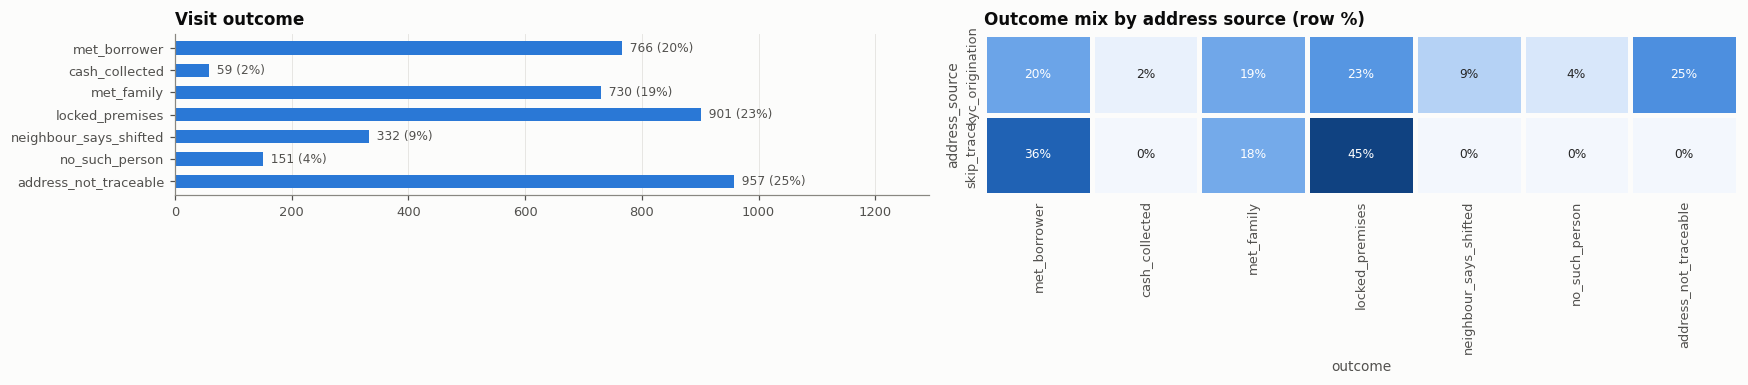

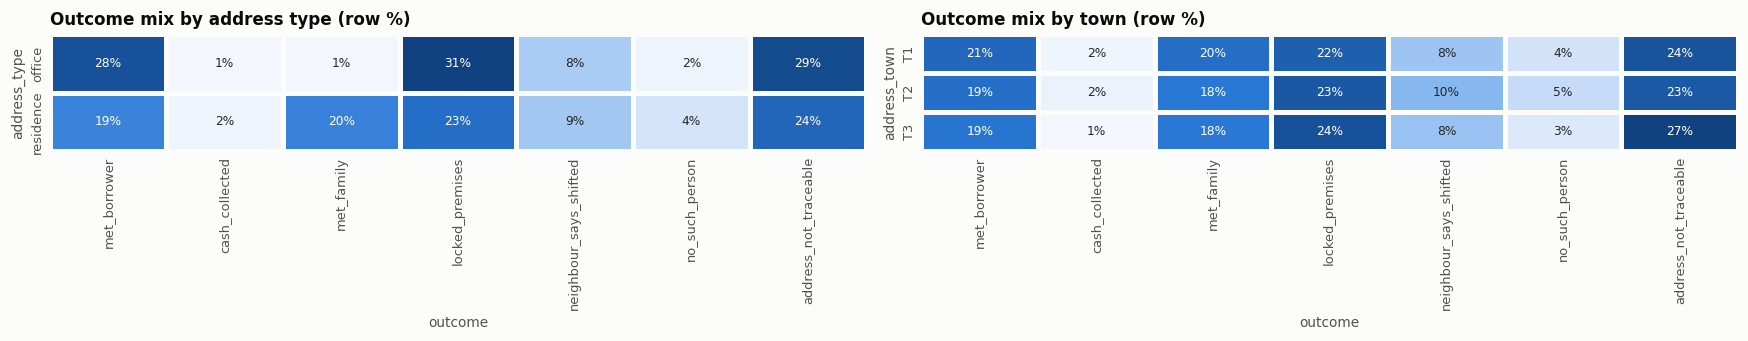

In [ ]:
VISIT_ORDER = ["met_borrower", "cash_collected", "met_family", "locked_premises", "neighbour_says_shifted", "no_such_person", "address_not_traceable"]
visits = visits.merge(addresses[["address_id", "address_type", "source", "town_id"]].rename(columns={"source": "address_source", "town_id": "address_town"}),
                      on="address_id", how="left")
visits["met"] = visits.outcome.isin(["met_borrower", "cash_collected"]).astype(int)
visits["not_traceable"] = (visits.outcome == "address_not_traceable").astype(int)
visits["travel_min"] = (visits.checkin_ts - visits.start_ts).dt.total_seconds() / 60
vv = outcome_view(visits)
print(f"Visits in view: {len(vv):,} to {vv.address_id.nunique():,} addresses on {vv.account_id.nunique():,} accounts  |  "
      f"met borrower: {vv.met.mean():.0%}  |  not traceable: {vv.not_traceable.mean():.0%}")
print("Visited address types:", visits.address_type.value_counts().to_dict(), "| permanent/native addresses are never visited")

fig, axes = plt.subplots(1, 2, figsize=(16, 3.6))
count_bar(vv.outcome, axes[0], "Visit outcome", order=VISIT_ORDER)
heat(pd.crosstab(vv.address_source, vv.outcome, normalize="index")[VISIT_ORDER], axes[1], "Outcome mix by address source (row %)")
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(16, 3.2))
heat(pd.crosstab(vv.address_type, vv.outcome, normalize="index")[VISIT_ORDER], axes[0], "Outcome mix by address type (row %)")
heat(pd.crosstab(vv.address_town, vv.outcome, normalize="index")[VISIT_ORDER], axes[1], "Outcome mix by town (row %)")
plt.tight_layout(); plt.show()

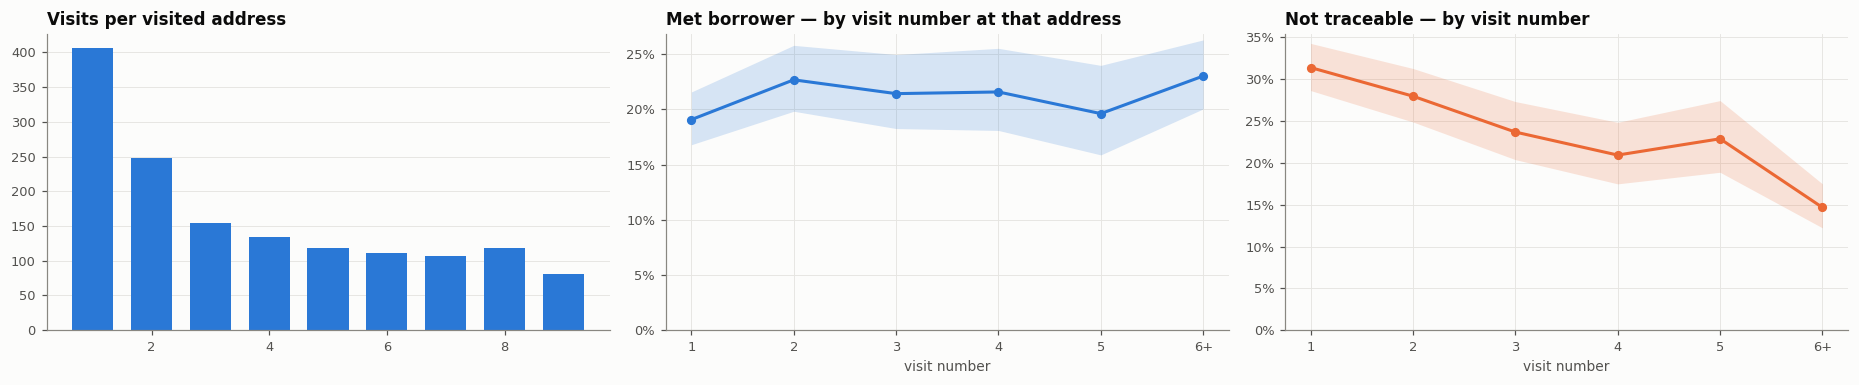

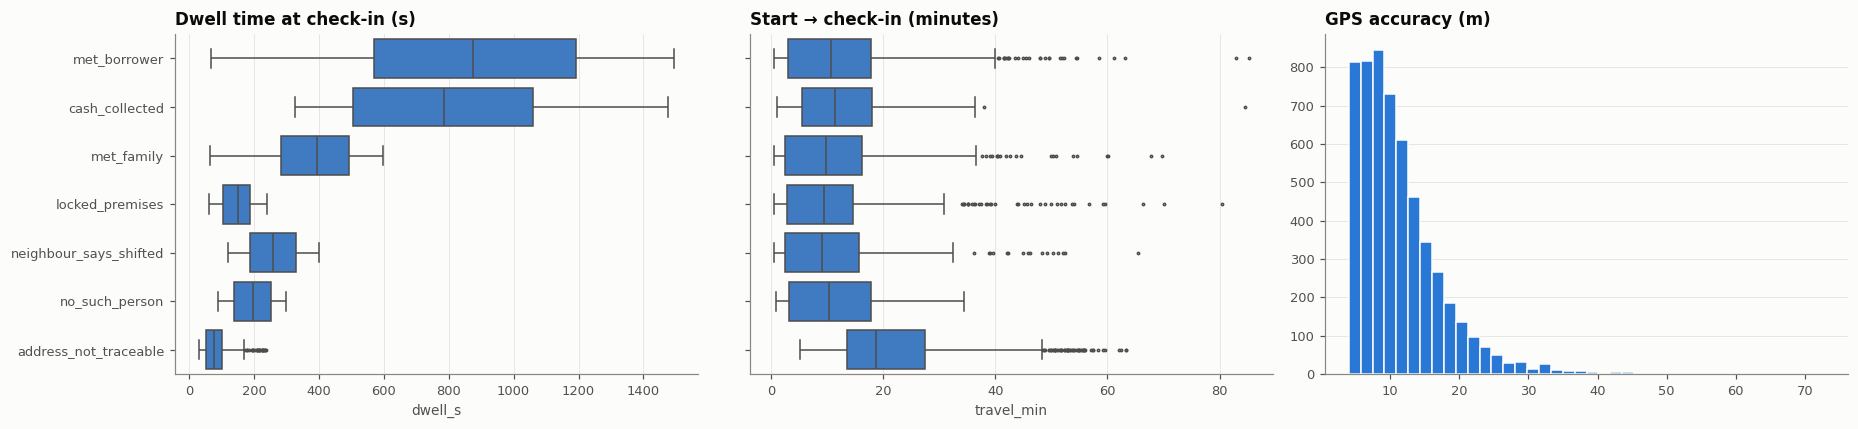

In [ ]:
# Repeat visits: does the outcome change as the same address is revisited?
vv = vv.sort_values(["address_id", "checkin_ts"])
vv["visit_no"] = vv.groupby("address_id").cumcount() + 1
vv["visit_no_bin"] = vv.visit_no.clip(upper=6).astype(str).replace("6", "6+")
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
vc = visits.groupby("address_id").size().value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=CAT[0], width=0.7); axes[0].set_title("Visits per visited address"); axes[0].grid(axis="x", visible=False)
rate_line(rate_table(vv, "visit_no_bin", "met", ["1", "2", "3", "4", "5", "6+"]), axes[1], "Met borrower — by visit number at that address", "visit number")
rate_line(rate_table(vv, "visit_no_bin", "not_traceable", ["1", "2", "3", "4", "5", "6+"]), axes[2], "Not traceable — by visit number", "visit number", color=CAT[1])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.boxplot(data=vv, y="outcome", x="dwell_s", order=VISIT_ORDER, color=CAT[0], fliersize=1.5, ax=axes[0]); axes[0].set_title("Dwell time at check-in (s)"); axes[0].set_ylabel("")
sns.boxplot(data=vv, y="outcome", x="travel_min", order=VISIT_ORDER, color=CAT[0], fliersize=1.5, ax=axes[1]); axes[1].set_title("Start → check-in (minutes)"); axes[1].set_ylabel(""); axes[1].set_yticklabels([])
axes[2].hist(visits.gps_accuracy_m, bins=40, color=CAT[0], edgecolor=SURFACE); axes[2].set_title("GPS accuracy (m)"); axes[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 11.3 Visit integrity
A genuine visit has its own photo. The same `photo_hash` appearing on visits to different accounts on different days means a photo was reused, a strong sign of a visit that didn't happen. Very short dwell times are a weaker signal. Evidence from suspicious visits should get less weight in any model.

In [ ]:
dup = visits.photo_hash.value_counts()
dup = dup[dup > 1]
vis_dup = visits[visits.photo_hash.isin(dup.index)]
print(f"Photo hashes used on more than one visit: {len(dup)}  |  visits involved: {len(vis_dup)}")
display(vis_dup.groupby("photo_hash").agg(visits=("visit_id", "size"), accounts=("account_id", "nunique"), agents=("agent_id", "nunique"),
                                          agent=("agent_id", "first"), days=("visit_date", "nunique")).sort_values("visits", ascending=False))
integ_v = visits.groupby("agent_id").agg(visits=("visit_id", "size"), reused_photo_visits=("photo_hash", lambda s: s.isin(dup.index).sum()),
                                         short_dwell_under_60s=("dwell_s", lambda s: (s < 60).mean()), median_dwell=("dwell_s", "median"),
                                         met_rate=("met", "mean"))
integ_v["reused_share"] = integ_v.reused_photo_visits / integ_v.visits
display(integ_v.sort_values("reused_share", ascending=False))
display(Markdown("**Outcome mix: visits with reused photos vs all others**"))
display(pd.crosstab(visits.photo_hash.isin(dup.index).map({True: "reused photo", False: "unique photo"}), visits.outcome, normalize="index")[VISIT_ORDER].round(2))

Photo hashes used on more than one visit: 11  |  visits involved: 172


,visits,accounts,agents,agent,days
photo_hash,,,,,
ph0082,32,31,1,FA009,30
ph0080,28,28,1,FA009,23
ph0081,27,26,1,FA009,23
ph0084,26,26,1,FA009,25
ph0083,26,26,1,FA009,24
ph0085,23,22,1,FA009,19
ph0012,2,2,1,FA002,2
ph0042,2,2,1,FA005,2
ph0013,2,2,1,FA002,2


,visits,reused_photo_visits,short_dwell_under_60s,median_dwell,met_rate,reused_share
agent_id,,,,,,
FA009,610,162,0.048,184.000,0.202,0.266
FA008,611,4,0.108,187.000,0.187,0.007
FA002,633,4,0.084,197.000,0.205,0.006
FA005,606,2,0.076,220.500,0.226,0.003
FA001,628,0,0.075,206.000,0.228,0.000
FA004,636,0,0.080,221.000,0.222,0.000
FA003,645,0,0.081,223.000,0.242,0.000
FA007,626,0,0.094,212.500,0.232,0.000
FA006,583,0,0.069,220.000,0.201,0.000


**Outcome mix: visits with reused photos vs all others**

outcome,met_borrower,cash_collected,met_family,locked_premises,neighbour_says_shifted,no_such_person,address_not_traceable
photo_hash,,,,,,,
reused photo,0.130,0.000,0.070,0.480,0.000,0.000,0.320
unique photo,0.200,0.020,0.190,0.220,0.080,0.040,0.250


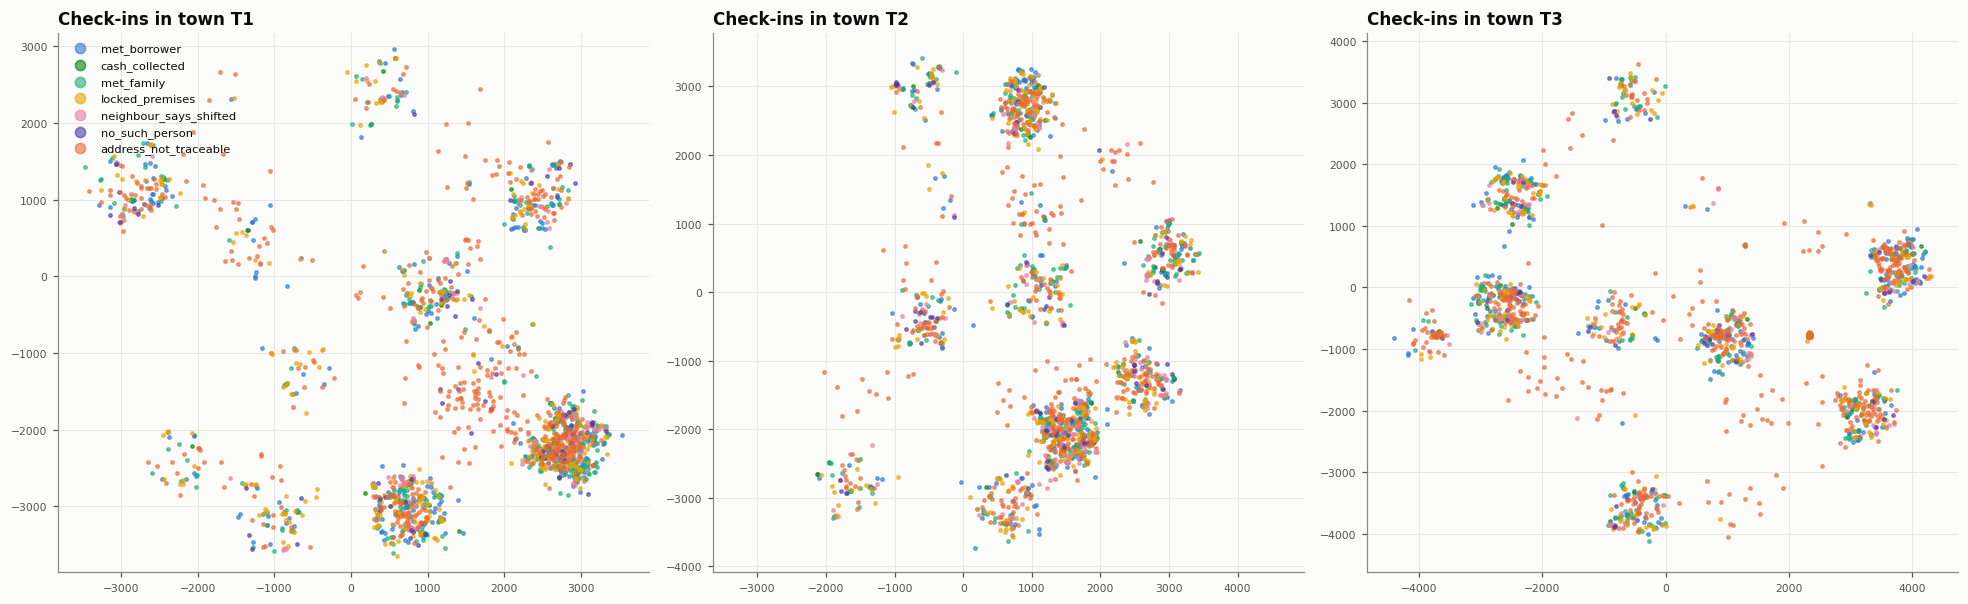

In [ ]:
# Where check-ins happen (local x/y coordinates), coloured by outcome
VCOL = {"met_borrower": CAT[0], "cash_collected": CAT[5], "met_family": CAT[2], "locked_premises": CAT[3],
        "neighbour_says_shifted": CAT[4], "no_such_person": CAT[6], "address_not_traceable": CAT[1]}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), sharex=False)
for ax, t in zip(axes, ["T1", "T2", "T3"]):
    sub = visits[visits.address_town == t]
    for o in VISIT_ORDER:
        g = sub[sub.outcome == o]
        ax.scatter(g.checkin_x, g.checkin_y, s=5, color=VCOL[o], alpha=0.6, label=o)
    ax.set_title(f"Check-ins in town {t}"); ax.set_aspect("equal", adjustable="datalim"); ax.tick_params(labelsize=7)
axes[0].legend(markerscale=3, fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

In [ ]:
# Remarks: field agents sometimes write location corrections ("2 gali aage", "hinde ide")
CORR = r"aage|peeche|piche|hinde|munde|behind|next to|opposite|actual|nija|asli|gali|cross"
visits["remark_has_location_hint"] = visits.remark.fillna("").str.contains(CORR, case=False, regex=True)
display(Markdown("**Share of visit remarks containing a location hint, by outcome**"))
display(visits.groupby("outcome").remark_has_location_hint.mean().reindex(VISIT_ORDER).to_frame("share with location hint"))
display(visits.loc[visits.remark_has_location_hint, ["outcome", "remark"]].drop_duplicates("remark").head(10))

**Share of visit remarks containing a location hint, by outcome**

,share with location hint
outcome,
met_borrower,0.076
cash_collected,0.087
met_family,0.080
locked_premises,0.075
neighbour_says_shifted,0.070
no_such_person,0.039
address_not_traceable,0.000


,outcome,remark
2,locked_premises,"yaaru illa, beega haakide; nija mane Milk Dair..."
5,met_borrower,customer maneli sikkidru; nija mane Masidi hin...
10,locked_premises,"premises locked, nobody home; house is on the ..."
16,locked_premises,"premises locked, nobody home; actual house beh..."
34,met_borrower,customer ghar pe mila; ghar Dawai ki Dukaan ke...
35,locked_premises,"koi nahi mila, taala laga tha; asli ghar Doodh..."
36,locked_premises,ghar band tha; ghar Doodh Dairy ke saamne wali...
41,locked_premises,"koi nahi mila, taala laga tha; ghar Medical St..."
47,met_family,"father se baat hui, message de denge; asli gha..."
62,met_borrower,met customer at shop; actual house behind Bus ...


## 12. Account-level view: correlations across all tables (train)
One row per account combining its profile with what its phones, calls, payments, visits and traces show. **Left of the heatmap** are contact outcomes; **across the top** are account attributes. Rank (Spearman) correlation; binary columns are 0/1. Look for account attributes that move with contactability, and for contact signals that move together (which may be redundant as features).

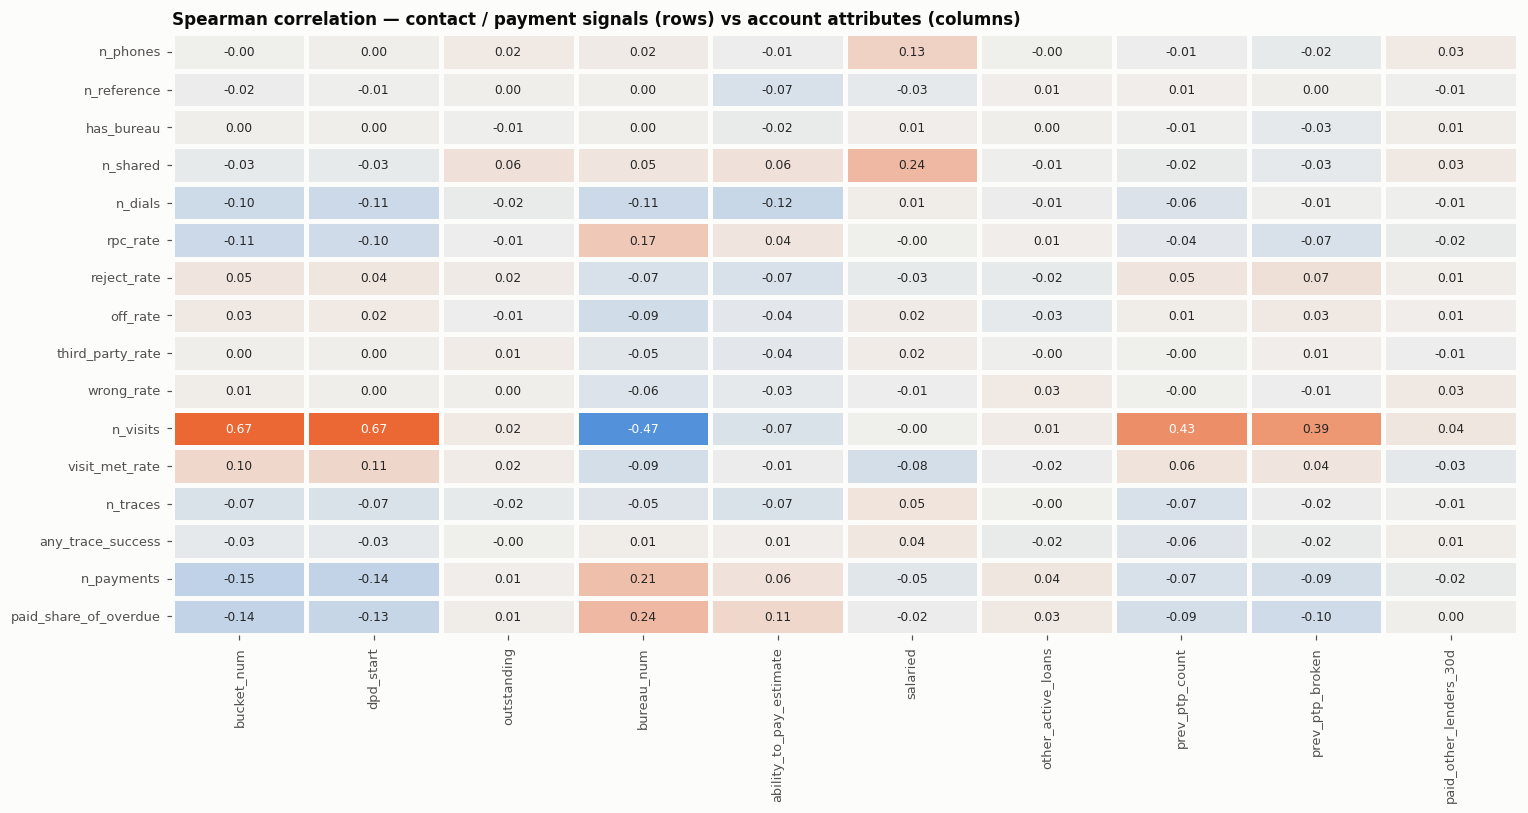

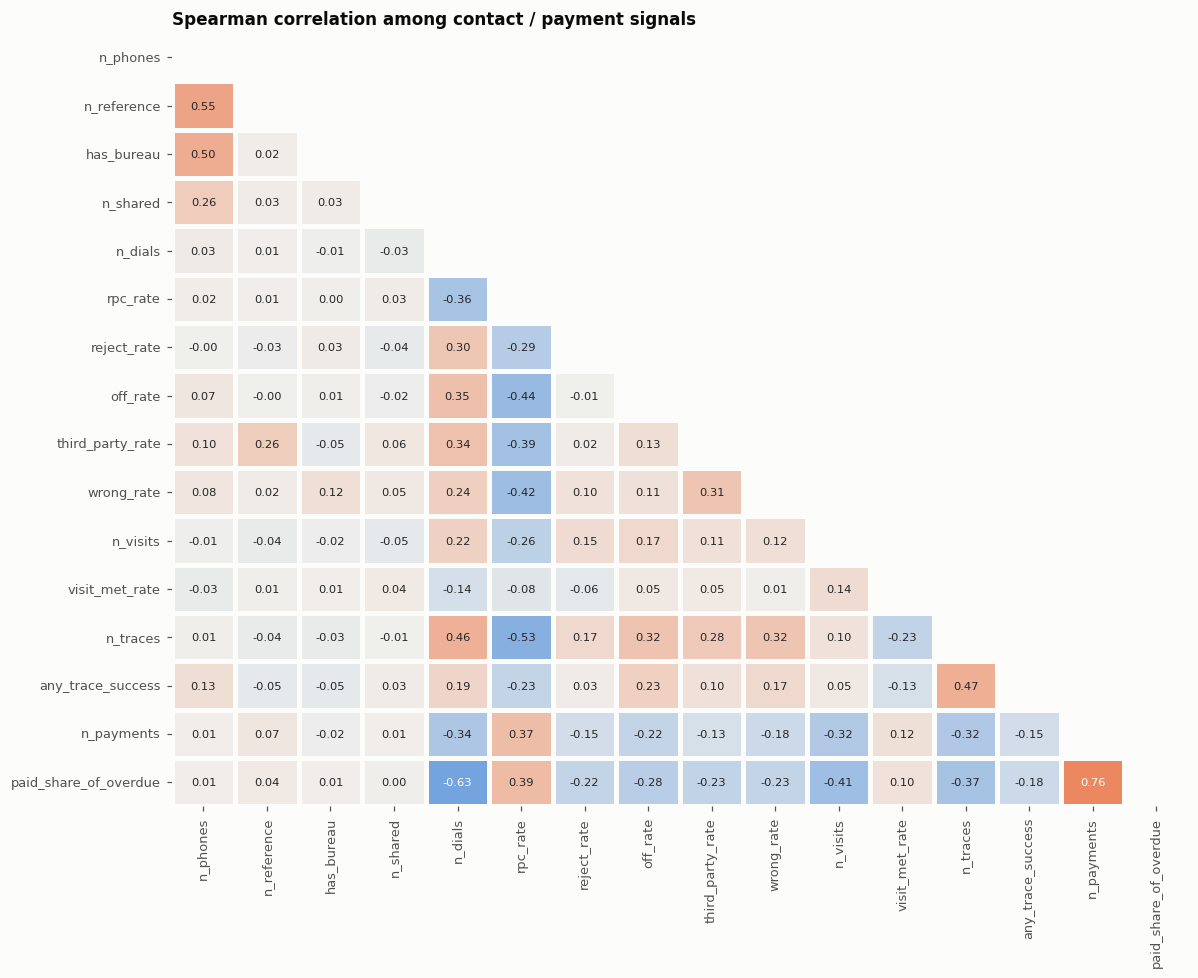

In [ ]:
ph_feats = phones.groupby("account_id").agg(
    n_phones=("phone_id", "size"),
    n_reference=("source", lambda r: (r == "reference").sum()),
    has_bureau=("source", lambda r: int((r == "bureau").any())),
    n_shared=("is_shared", "sum"),
)
d_ = outcome_view(dials)
d_feats = d_.groupby("account_id").agg(
    n_dials=("attempt_id", "size"), rpc_rate=("rpc", "mean"),
    reject_rate=("outcome", lambda s: (s == "rejected").mean()),
    off_rate=("outcome", lambda s: s.isin(["switched off", "not reachable", "invalid"]).mean()),
    third_party_rate=("outcome", lambda s: (s == "third party").mean()),
    wrong_rate=("outcome", lambda s: (s == "wrong number").mean()),
)
p_feats = outcome_view(payments).groupby("account_id").agg(n_payments=("payment_id", "size"), total_paid=("amount", "sum"))
v_feats = outcome_view(visits).groupby("account_id").agg(n_visits=("visit_id", "size"), visit_met_rate=("met", "mean"))
tr = outcome_view(skip).assign(success=lambda d: (d.result != "no_new_info").astype(int))
t_feats = tr.groupby("account_id").agg(n_traces=("trace_id", "size"), any_trace_success=("success", "max"))

A = outcome_view(accounts)
for f in (ph_feats, d_feats, p_feats, v_feats, t_feats):
    A = A.merge(f, left_on="account_id", right_index=True, how="left")
A[["n_payments", "total_paid", "n_visits", "n_traces", "any_trace_success"]] = A[["n_payments", "total_paid", "n_visits", "n_traces", "any_trace_success"]].fillna(0)
A["paid_share_of_overdue"] = (A.total_paid / A.overdue_start).clip(upper=2)
A["bucket_num"] = A.bucket_start.map({b: i for i, b in enumerate(BUCKET_ORDER)})
A["bureau_num"] = A.bureau_score_band.map({b: i for i, b in enumerate(BUREAU_ORDER)})
A["salaried"] = (A.income_type == "salaried").astype(int)
A["paid_other_lenders_30d"] = A.paid_other_lenders_30d.astype(str).str.lower().eq("true").astype(int)

rows_ = ["n_phones", "n_reference", "has_bureau", "n_shared", "n_dials", "rpc_rate", "reject_rate", "off_rate",
         "third_party_rate", "wrong_rate", "n_visits", "visit_met_rate", "n_traces", "any_trace_success", "n_payments", "paid_share_of_overdue"]
cols_ = ["bucket_num", "dpd_start", "outstanding", "bureau_num", "ability_to_pay_estimate", "salaried",
         "other_active_loans", "prev_ptp_count", "prev_ptp_broken", "paid_other_lenders_30d"]
C = A[rows_ + cols_].corr("spearman").loc[rows_, cols_]
fig, ax = plt.subplots(figsize=(14, 7.5))
sns.heatmap(C, annot=True, fmt=".2f", cmap=DIV, center=0, vmin=-0.6, vmax=0.6, linewidths=2, linecolor=SURFACE,
            cbar=False, ax=ax, annot_kws={"fontsize": 8})
ax.set_title("Spearman correlation — contact / payment signals (rows) vs account attributes (columns)"); ax.grid(False)
plt.tight_layout(); plt.show()

CC = A[rows_].corr("spearman")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(CC, mask=np.triu(np.ones_like(CC, dtype=bool)), annot=True, fmt=".2f", cmap=DIV, center=0, vmin=-1, vmax=1,
            linewidths=2, linecolor=SURFACE, cbar=False, ax=ax, annot_kws={"fontsize": 7.5})
ax.set_title("Spearman correlation among contact / payment signals"); ax.grid(False)
plt.tight_layout(); plt.show()

## 13. Summary of the random dialling arm
Accounts whose numbers were dialled in random order are the least biased data for evaluating a new policy. Check they resemble the rest and how many there are in each split.

In [ ]:
arm = accounts.merge(per_acct, left_on="account_id", right_index=True)
arm_d = dials.groupby("account_id").size().rename("n_dials")
arm = arm.merge(arm_d, left_on="account_id", right_index=True, how="left")
display(arm.groupby("dialling_arm").agg(accounts=("account_id", "size"), mean_phones=("n_phones", "mean"), mean_dials=("n_dials", "mean"),
                                        median_outstanding=("outstanding", "median"), median_dpd=("dpd_start", "median")))
display(pd.crosstab(accounts.dialling_arm, accounts.split)[SPLIT_ORDER])
for c in ["portfolio", "bucket_start", "lender_id"]:
    pval = stats.chi2_contingency(pd.crosstab(accounts[c], accounts.dialling_arm))[1]
    print(f"{c:<14} chi-square p = {pval:.3f}  ({'similar' if pval > 0.05 else 'DIFFERENT'} mix between arms)")

,accounts,mean_phones,mean_dials,median_outstanding,median_dpd
dialling_arm,,,,,
random_contact_point,123,2.203,22.860,"94,000.000",45.000
rule_based,2277,2.393,21.513,"123,250.000",40.000


split,train,validation,test
dialling_arm,,,
random_contact_point,89,20,14
rule_based,1591,340,346


portfolio      chi-square p = 0.041  (DIFFERENT mix between arms)
bucket_start   chi-square p = 0.287  (similar mix between arms)
lender_id      chi-square p = 0.100  (similar mix between arms)


## 14. Key findings
_Numbers below are from the run on the training split (data-quality items use all data). Re-check them if you change the settings._

### Data quality and setup
- **All 11 files link cleanly.** Every dial, visit, payment and trace points to a real account, phone, address and agent. Dialling arms match between tables, and every call falls inside the 8 am – 7 pm window (max 2 calls per account per day).
- `accounts_1.csv` / `splits_1.csv` are identical to `accounts.csv` / `splits.csv`. `agents` and `lenders` are reference tables and must not be split.
- **74 phone numbers are shared across accounts.** 68 are office lines. 6 are recorded as the borrower's own number on unrelated accounts (likely an agent or dealer number). **43 of the shared numbers span train / validation / test**, so build number-level features from train only.
- `phone_masked` is useless as an identifier, because its overlaps match pure chance.
- **Time windows:** dialling and visits run 1 Apr to 29 Jun, payments continue to 24 Jul (a follow-up window for recovery), and verification happened on 2 Jul (a clean future label).
- **29% of numbers were never dialled**, mostly reference, employer and bureau numbers in lower slots. They have no evidence and must be treated as censored, not negative.

### Dial attempts: the main signal (train)
- **164 RPCs per 1,000 dials.** About half of all attempts ring out unanswered.
- **Source matters even per attempt:** borrower update 20%, KYC 18%, skip-trace 19%, bureau 10%, reference 9%, employer 4%. Bureau numbers get **wrong number about 11% of the time**, versus under 2% for KYC.
- **Timing:** contact rates peak at **8–9 am and 5–7 pm (about 20%)** and dip to about 13% at 11 am – 4 pm, yet most dialling happens 8 am – 1 pm. Dialling is concentrated in the hours that pay off least. Weekday barely matters.
- **Dial history separates the true states** (8.5). Borrower numbers show RPCs plus a 15% **rejection** rate (alive, sometimes avoiding). Switched-off numbers show about 48% switched-off responses. Not-the-borrower numbers show about 26% **wrong number** plus long switched-off runs, a recycled-number pattern. Third-party numbers show about 34% third-party answers. This is what makes weak labels workable.
- **Evidence decays.** Chance of RPC on the next call falls from 24% (within 3 days of the last RPC) to 8% (60+ days), and from 22% to 3% as consecutive failures grow from 0 to 20+. Model confidence should decay the same way.
- **Recycled numbers:** 242 numbers reached the borrower and later returned wrong number, but 82% had only one such call. A repeated pattern is the reliable flag.
- **The skip-trace rule is confirmed:** most traces fire at exactly 15 consecutive failed attempts on the account.
- **Random arm:** propensities range from 0.25 to 1. Its raw RPC rate is 14% (12% after inverse-propensity weighting) versus 16.5% under the rule, which suggests the rule's ordering does add some value. Any new policy has to beat that.
- Voice-bot calling stopped around the start of May.

### Agents and integrity
- RPC rates are similar across tele-agents (13–19%) and don't depend on tenure (ρ = 0.07).
- **Language mismatch:** when the agent's language team doesn't match the borrower's preference, 2% of calls end in a language barrier, versus almost none when it matches.
- **TA013 logged 24 promises-to-pay on calls the network says were never answered** (zero talk time), and has one of the lowest PTP keep rates (27%). This is a clear integrity flag.
- Overall, only **37% of PTPs are followed by a payment within 10 days**.

### Payments
- 69% of train accounts made at least one payment; UPI links are the biggest channel.
- **7% of accounts paid without ever being reached by phone.** Their call history is mostly no-answer and unreachable, so the borrower is alive and able to pay but not answering. This is the "avoiding, switch channel" case.
- Once reached, about 40% of accounts pay within 30 days, recovering on average about 30% of the overdue amount, or 3% of outstanding. That's the value-of-finding input for the skip-trace decision.

### Addresses and field visits
- Residence addresses dominate. **All 226 permanent/native addresses are out of town and never visited.** Bureau-style upper-case text comes from `kyc_upper` lenders, and some addresses are partly in Kannada or Devanagari.
- Visits: 20% meet the borrower, **25% end "address not traceable"**, 23% find the premises locked. Not-traceable falls from 31% on the first visit to 15% by the sixth, as agents learn the area (PS3 overlap).
- Dwell time cleanly separates outcomes (met about 15 min, not traceable about 1 min).
- **Field agent FA009 reused the same 6 photos across 162 visits** to different accounts on different days. These visits should be down-weighted or excluded.
- **Field visits are allocated by delinquency** (visits correlate 0.67 with days past due), so visit outcomes are selection-biased toward high-DPD accounts.

### Skip traces and verified truth (from Sections 6–7)
- Only 51% of verified numbers reach the borrower. **24% of numbers recorded as the borrower's own are someone else's**, which is a direct disclosure risk.
- Tracing succeeds 22% of the time at about ₹479 per success, and success is flat across loan sizes. Value-ranking is the obvious improvement.

### What this means for modelling
1. **Unit:** one phone number (later, one address) per day, with features from history before that day only.
2. **Core features:** source, slot, shared status, consecutive failures, days since last RPC, and shares of rejected, switched off, wrong number and third party, plus best time slot and language match.
3. **Labels:** next-period RPC from dial history (censoring untested numbers), with the **verified sample held out for evaluation**.
4. **Clean the labels:** drop or down-weight TA013's PTPs and FA009's visits.
5. **Decision layer:** an avoiding signature means switch channel; a dead signature means trace; a recycled or third-party signature means suppress. Rank traces by P(trace succeeds) × P(recovery once reached) × outstanding − cost.
6. **Evaluate on the random arm with inverse-propensity weights**, alongside the verified sample.